In [4]:
import serial
import time
from datetime import datetime
import matplotlib.pyplot as plt
from collections import deque
import json

In [ ]:
# !pip install pyserial

In [ ]:
SERIAL_PORT = "COM7" 
BAUD_RATE = 115200
OUTPUT_FILE = "can_log.csv"
TARGET_ID = "0x488"
VALUE_INDEX = (2, 3)  
SCALE = 1 / 4        
MAX_POINTS = 100

In [ ]:
timestamps = deque(maxlen=MAX_POINTS)
values = deque(maxlen=MAX_POINTS)

In [ ]:
# Read and write in csv
def main():
    ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
    print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud")
    
    with open(OUTPUT_FILE, "w") as f:
        f.write("timestamp,can_id,data\n")  # CSV header
        
        while True:
            try:
                line = ser.readline().decode("utf-8",  errors='ignore').strip()
                if not line:
                    continue

                # Expected format from ESP: "ID:0x488 DATA:28 15 49 72 A6 00 00 A0"
                if "ID:" in line and "DATA:" in line:
                    parts = line.split()
                    can_id = parts[0].split(":")[1]
                    data = ' '.join(parts[2:])
                    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
                    f.write(f"{timestamp},{can_id},{data}\n")
                    f.flush()
                    print(f"[{timestamp}] {can_id}: {data}")
            except KeyboardInterrupt:
                print("\nLogging stopped by user.")
                break
            except Exception as e:
                print("Error:", e)

In [ ]:
# if __name__ == "__main__":
#     main()

In [ ]:
# # only read
# def main():
#     ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
#     print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud")
        
#     plt.ion()
#     fig, ax = plt.subplots()
#     line, = ax.plot([], [], label="RPM")
#     ax.set_ylim(0, 6000)
#     ax.set_title(f"Live CAN Signal - {TARGET_ID}")
#     ax.set_xlabel("Samples")
#     ax.set_ylabel("Value")
#     ax.legend()
#     while True:
#         try:
#             line_raw = ser.readline().decode("utf-8").strip()
#             print(line_raw)
#             if not line_raw:
#                 continue
#             if "ID:" in line_raw and "DATA:" in line_raw:
#                 parts = line_raw.split()
#                 can_id = parts[0].split(":")[1]
#                 data = ' '.join(parts[2:])
#                 timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
#                 print(f"[{timestamp}] {can_id}: {data}")

#             line_raw = line_raw.replace("'", '"').replace(",]", "]")

#             data = json.loads(line_raw)

#             if data.get("id") == TARGET_ID:
#                 data_bytes = data["data"]
#                 if len(data_bytes) >= max(VALUE_INDEX) + 1:
#                     low = int(data_bytes[VALUE_INDEX[0]])
#                     high = int(data_bytes[VALUE_INDEX[1]])
#                     raw = (high << 8) + low
#                     value = raw * SCALE
#                     ax.set_xlim(0, max(len(values), 10))

#                     timestamps.append(datetime.now().strftime("%H:%M:%S"))
#                     values.append(value)

#                     line.set_xdata(range(len(values)))
#                     line.set_ydata(values)
#                     ax.set_xlim(0, len(values))
#                     ax.relim()
#                     ax.autoscale_view()
#                     fig.canvas.draw()
#                     fig.canvas.flush_events()

#                     print(f"[{timestamps[-1]}] {TARGET_ID}: {value:.2f}")
#                     plt.ioff()
#                     plt.show()
#         except KeyboardInterrupt:
#             print("\nLogging stopped by user.")
#             break
#         except Exception as e:
#             print("Error:", e)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import style

In [8]:
def print_by_id(id:str, data:pd.DataFrame):
    acelerador = data.loc[data['can_id'] == id]

    acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])

    try:
        acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
            acelerador["data"]
            .str.split()
            .apply(lambda x: [int(byte) for byte in x])
            .tolist()
        )

        print(acelerador)

        for i in range(7):  # or 8 if you have b7
            plt.figure(figsize=(20, 5))
            plt.plot(acelerador["timestamp"], acelerador[f"b{i}"], label=f"Byte {i}")
            plt.xlabel("Time")
            plt.ylabel("Byte Value")
            plt.title("CAN Data Bytes Over Time")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    except:
        print("Didnt work")

0x280
                    timestamp can_id                  data  b0   b1  b2  b3  \
0     2025-06-19 17:02:42.586  0x280         0 0 0 0 0 0 0   0    0   0   0   
5     2025-06-19 17:02:42.600  0x280         0 0 0 0 0 0 0   0    0   0   0   
10    2025-06-19 17:02:42.615  0x280         0 0 0 0 0 0 0   0    0   0   0   
15    2025-06-19 17:02:42.626  0x280         0 0 0 0 0 0 0   0    0   0   0   
20    2025-06-19 17:02:42.641  0x280         0 0 0 0 0 0 0   0    0   0   0   
...                       ...    ...                   ...  ..  ...  ..  ..   
80510 2025-06-19 17:07:09.282  0x280  25 173 12 23 0 28 22  25  173  12  23   
80514 2025-06-19 17:07:09.293  0x280  25 173 12 22 0 27 22  25  173  12  22   
80518 2025-06-19 17:07:09.306  0x280  25 173 12 22 0 27 22  25  173  12  22   
80523 2025-06-19 17:07:09.326  0x280  25 189 12 23 0 28 22  25  189  12  23   
80525 2025-06-19 17:07:09.327  0x280  25 189 12 22 0 27 22  25  189  12  22   

       b4  b5  b6  
0       0   0   0  
5    

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

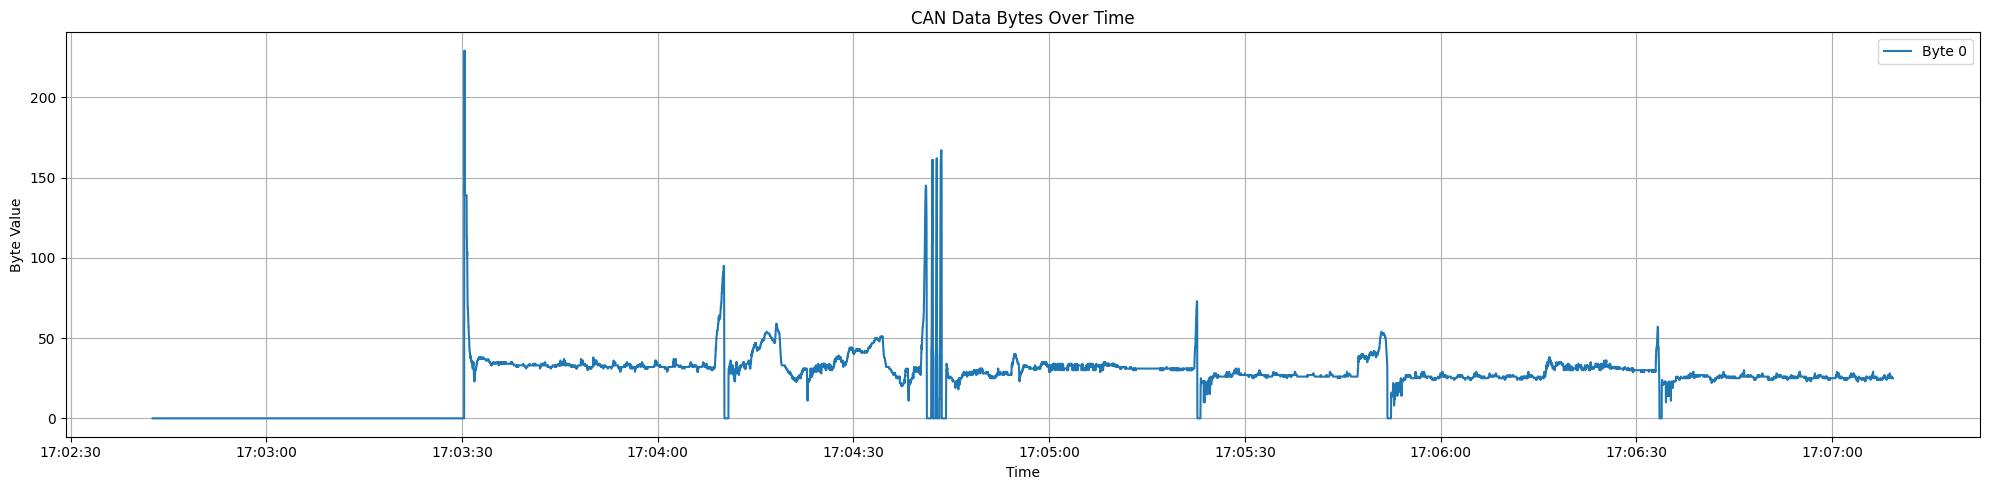

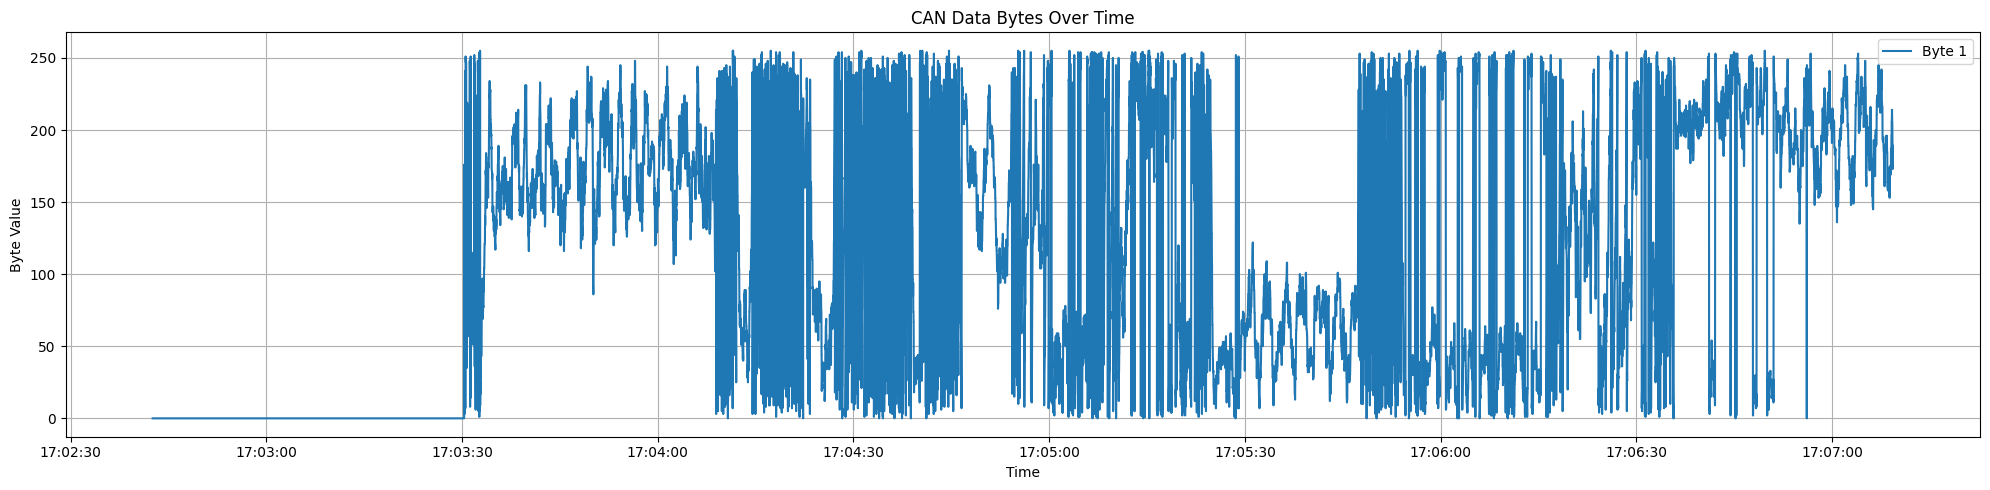

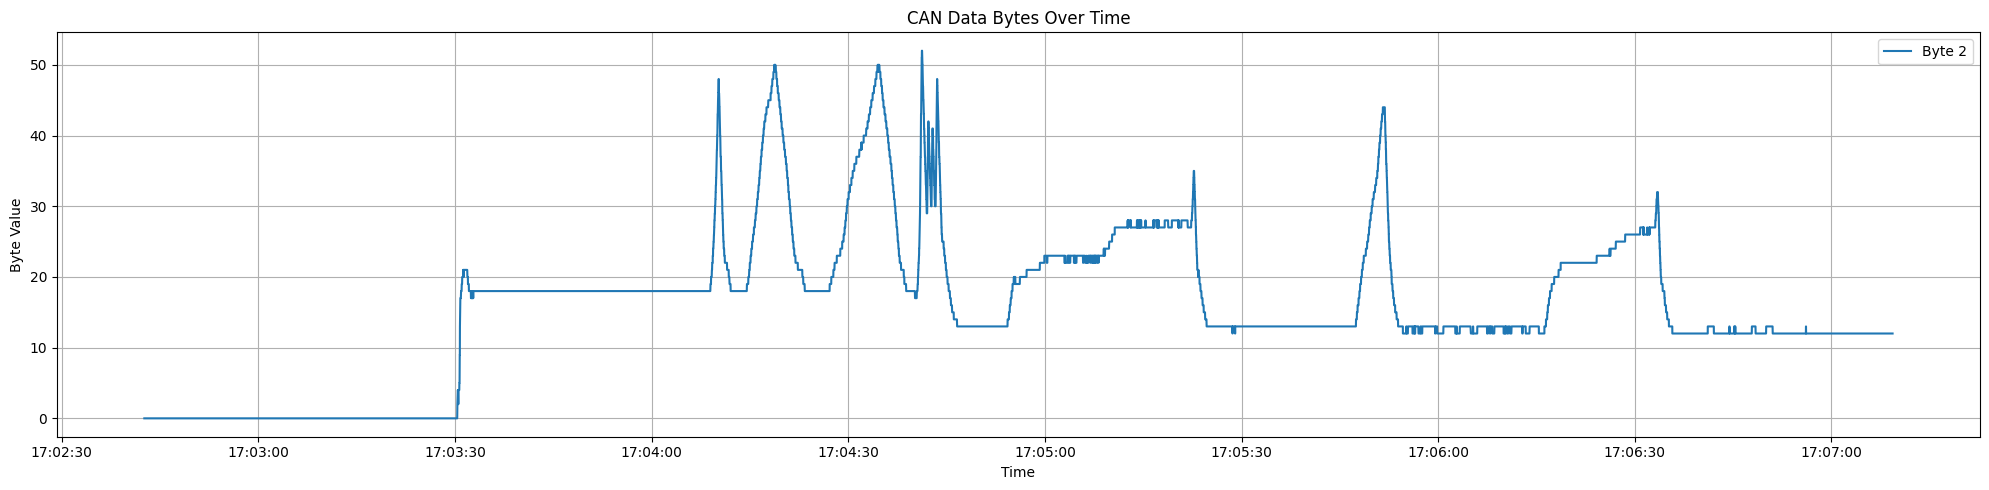

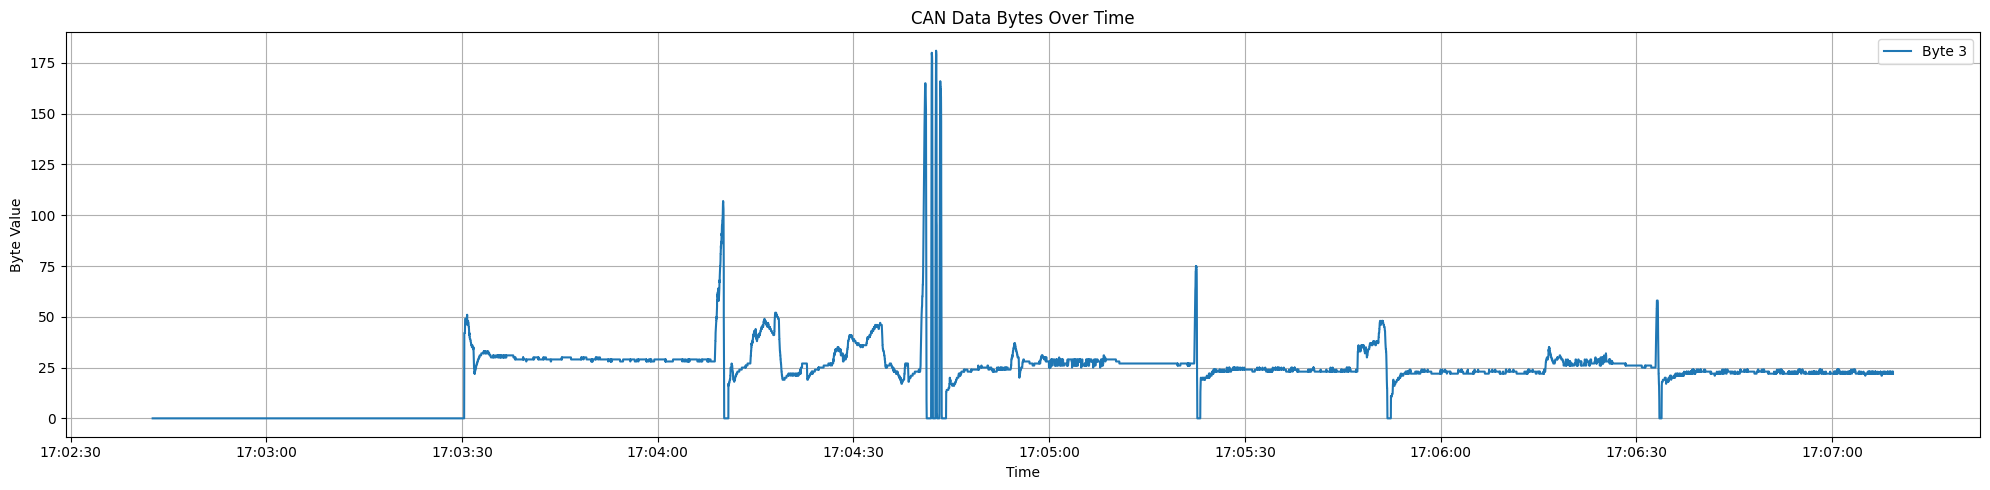

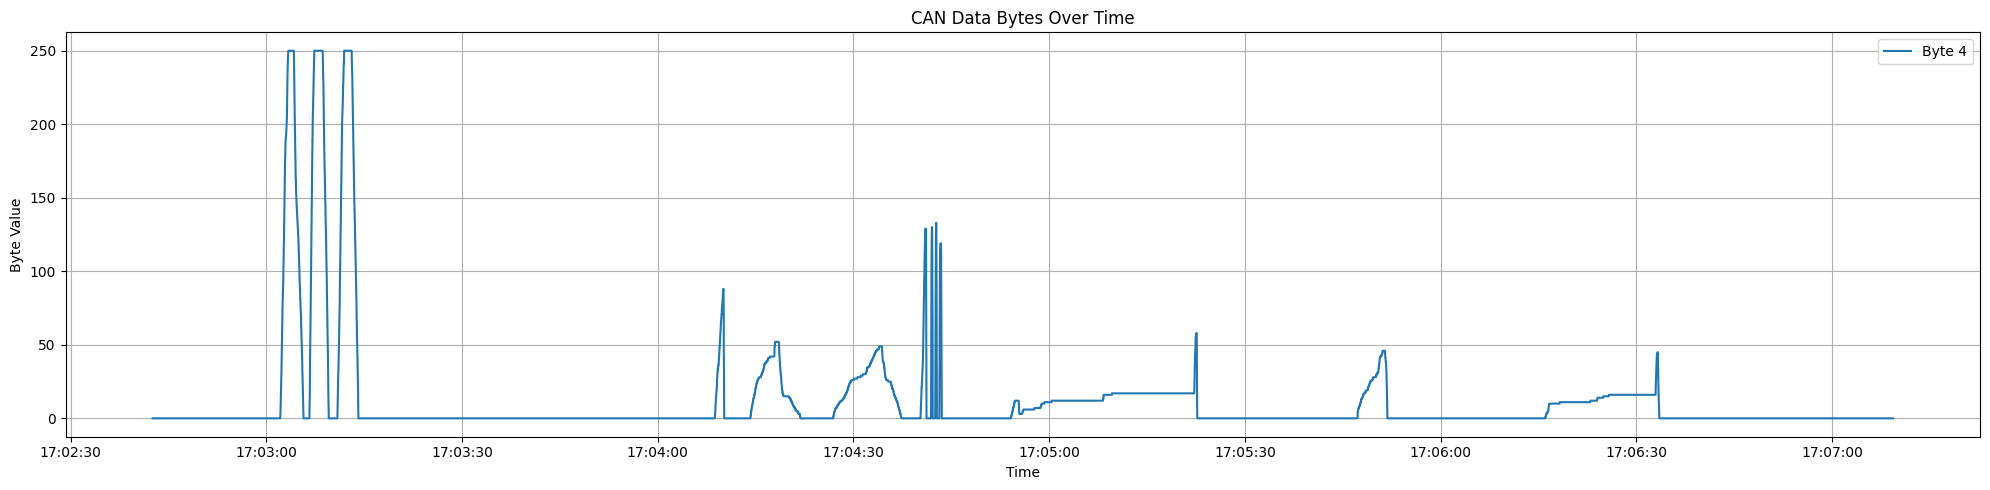

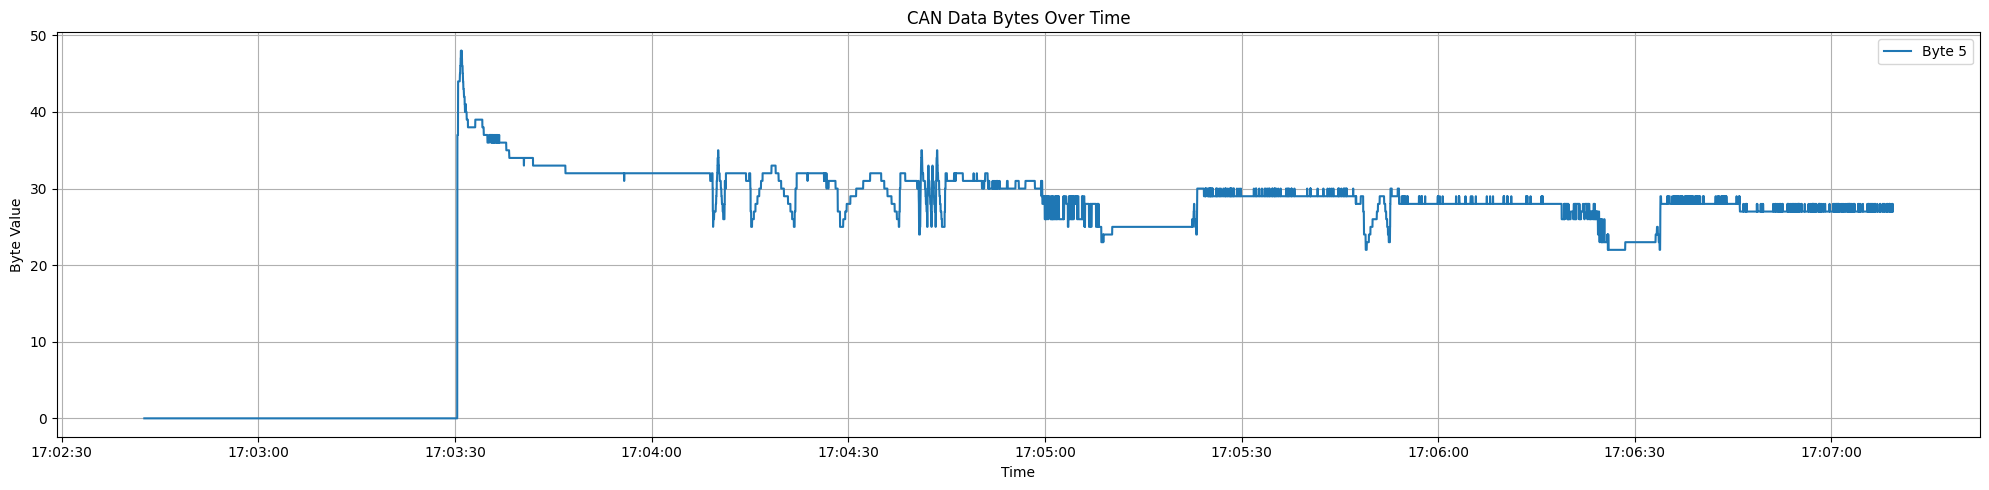

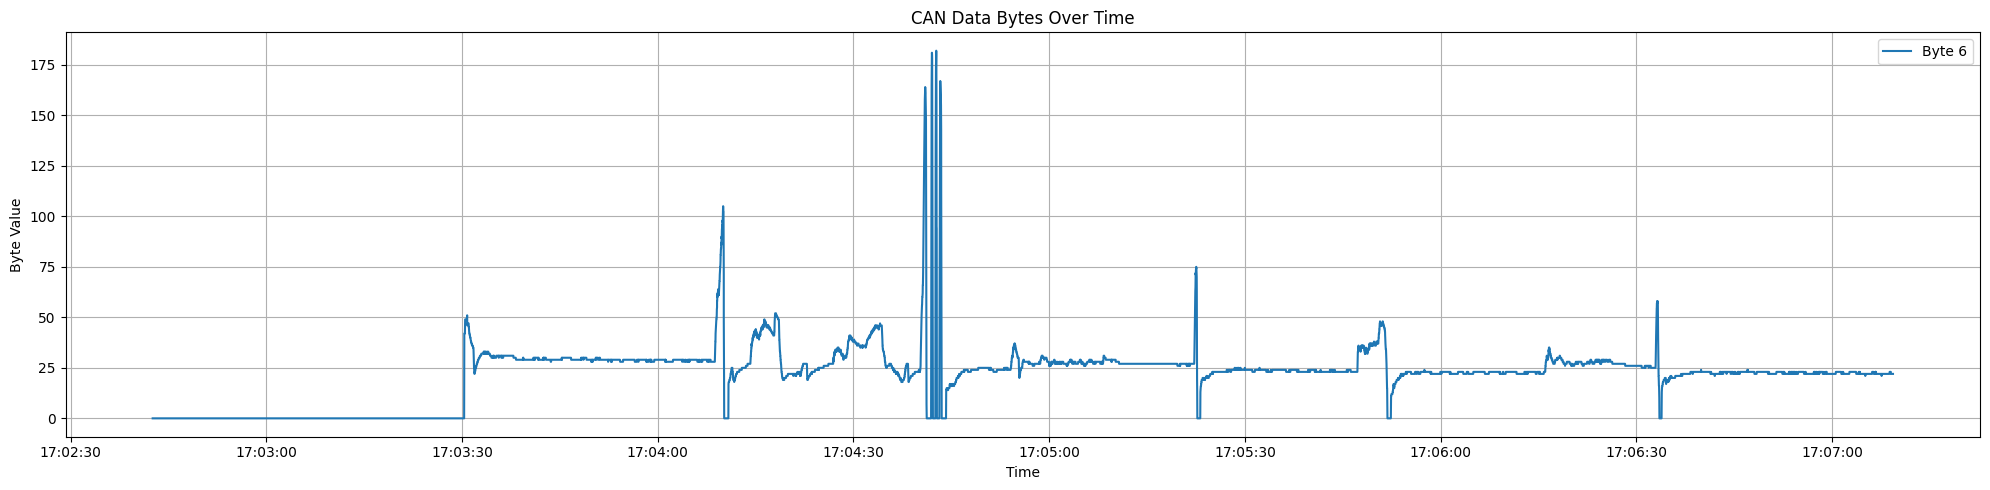

0x288
                    timestamp can_id                  data   b0  b1  b2  b3  \
1     2025-06-19 17:02:42.586  0x288   104 48 0 0 97 207 0  104  48   0   0   
6     2025-06-19 17:02:42.604  0x288   104 48 0 0 97 207 0  104  48   0   0   
11    2025-06-19 17:02:42.615  0x288   104 48 0 0 97 207 0  104  48   0   0   
16    2025-06-19 17:02:42.626  0x288   104 48 0 0 97 207 0  104  48   0   0   
21    2025-06-19 17:02:42.641  0x288   104 48 0 0 97 207 0  104  48   0   0   
...                       ...    ...                   ...  ...  ..  ..  ..   
80511 2025-06-19 17:07:09.287  0x288  143 48 0 0 82 211 10  143  48   0   0   
80515 2025-06-19 17:07:09.299  0x288  143 48 0 0 82 211 10  143  48   0   0   
80519 2025-06-19 17:07:09.306  0x288  143 48 0 0 82 211 10  143  48   0   0   
80524 2025-06-19 17:07:09.326  0x288  143 50 0 0 82 211 10  143  50   0   0   
80526 2025-06-19 17:07:09.334  0x288  143 34 0 0 82 211 10  143  34   0   0   

       b4   b5  b6  
1      97  207   0  
6  

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

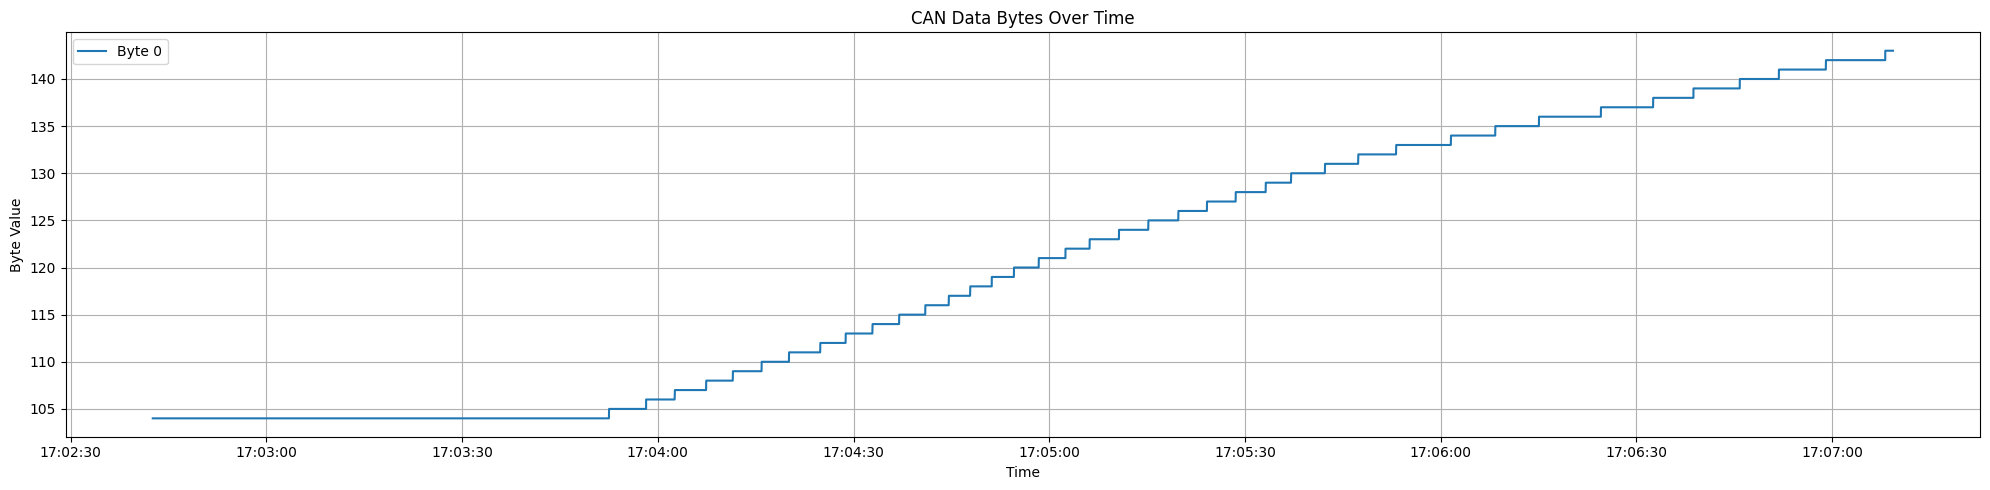

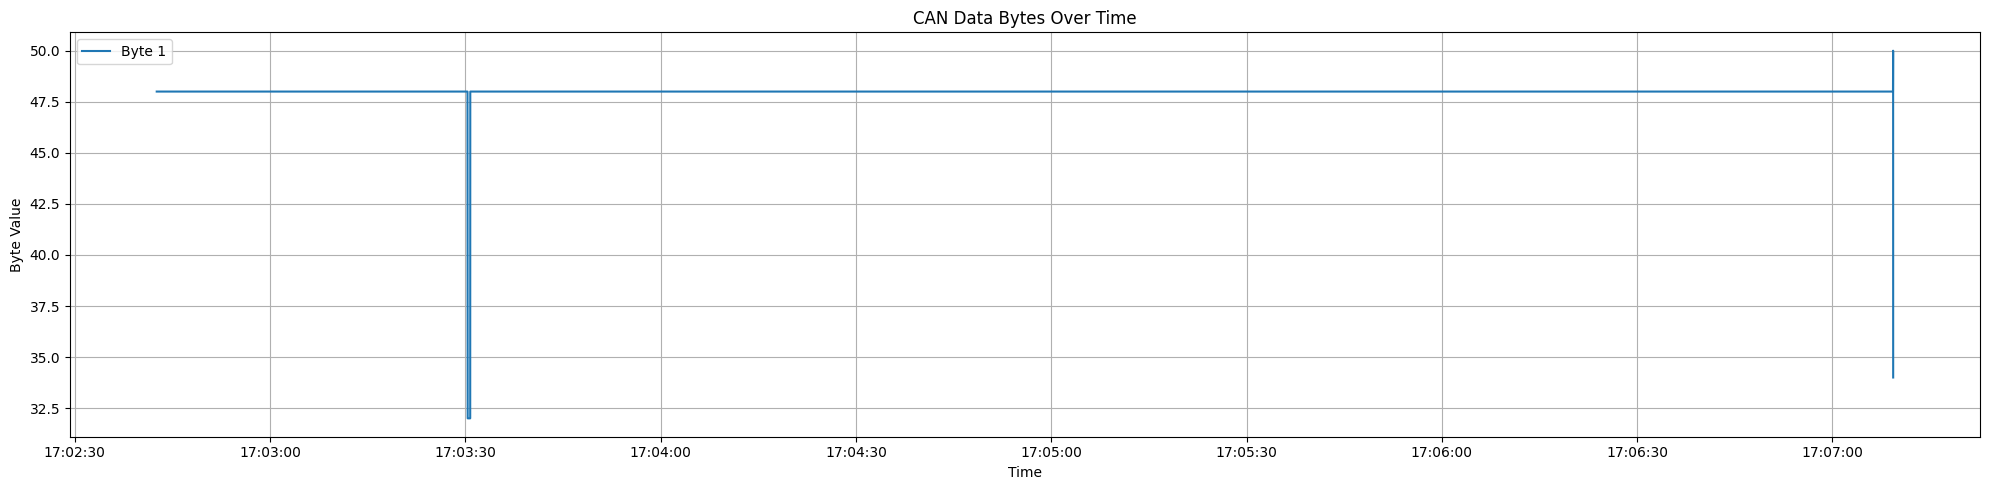

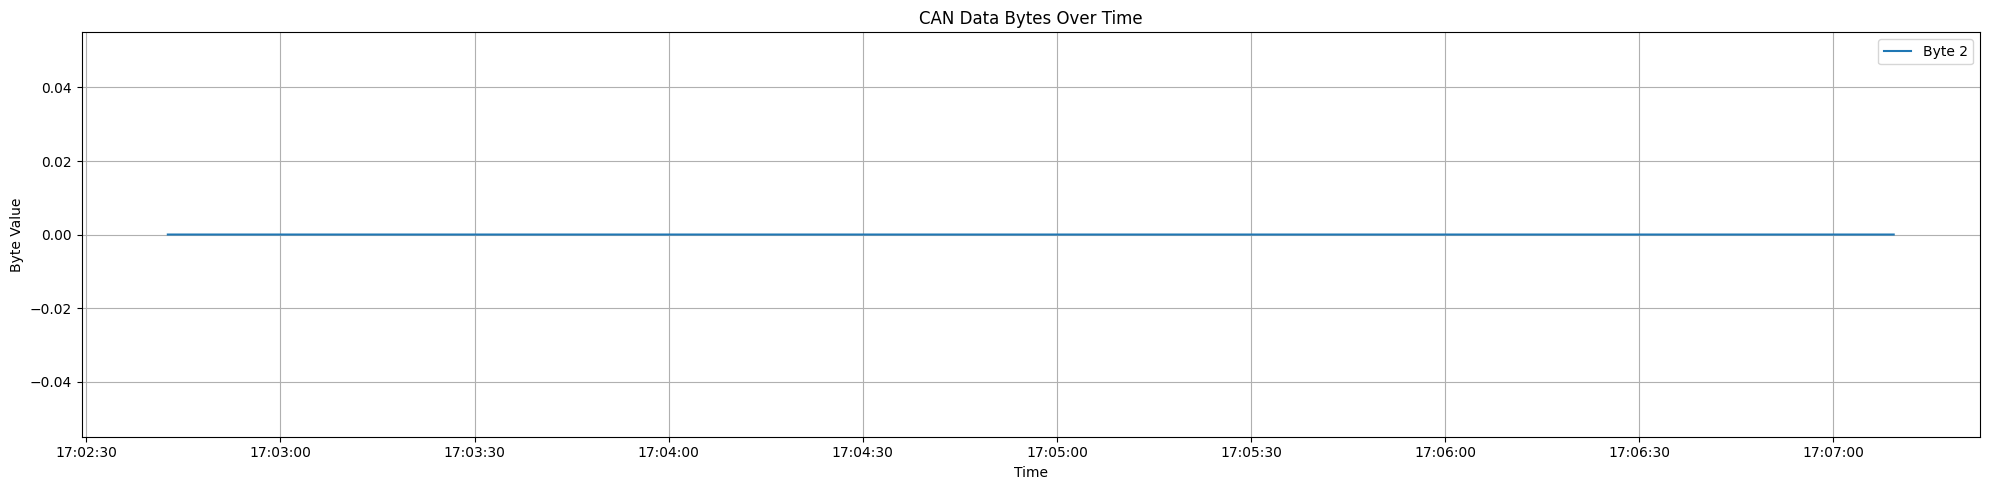

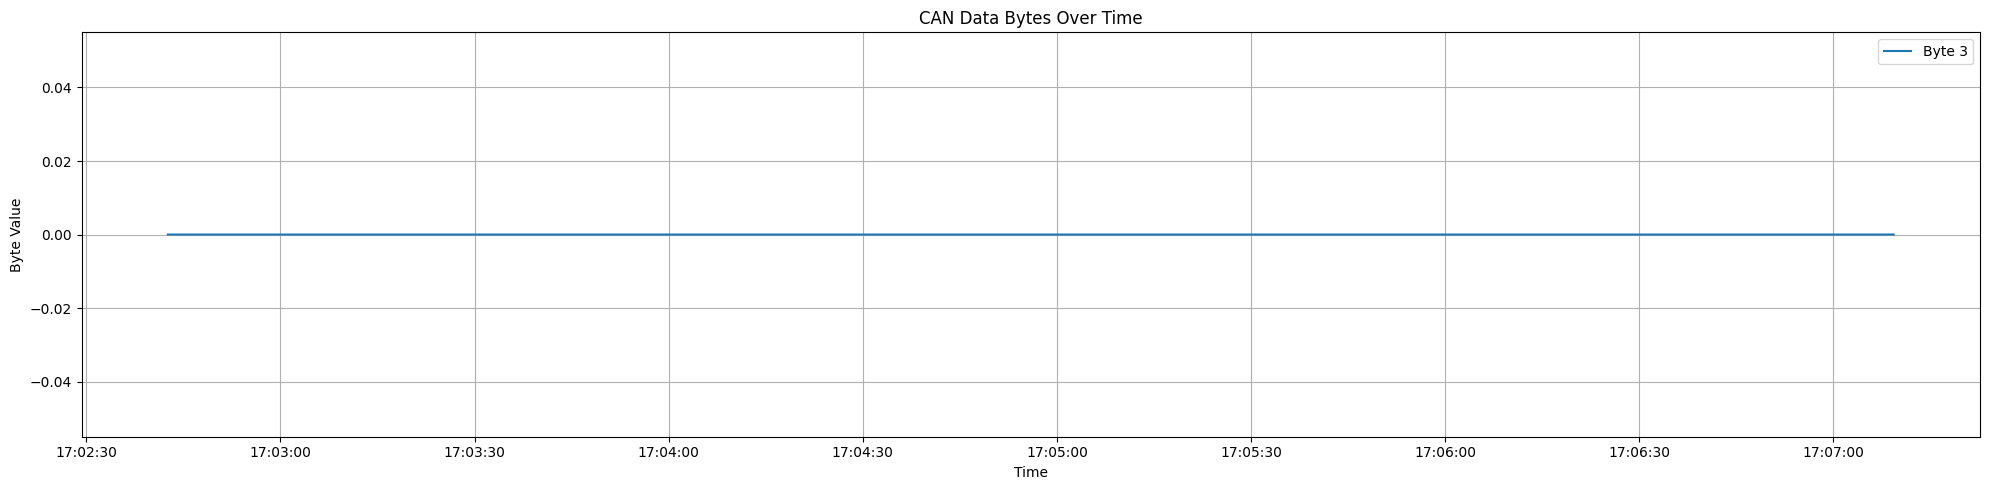

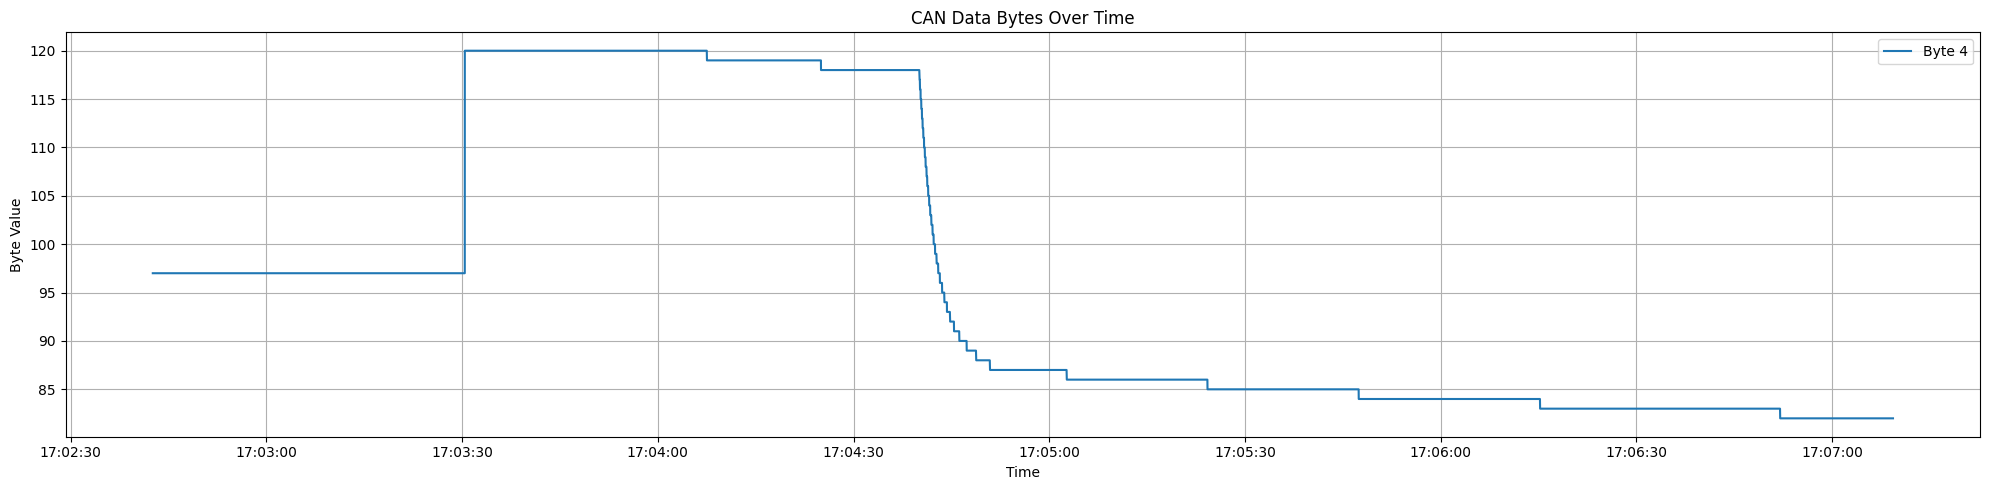

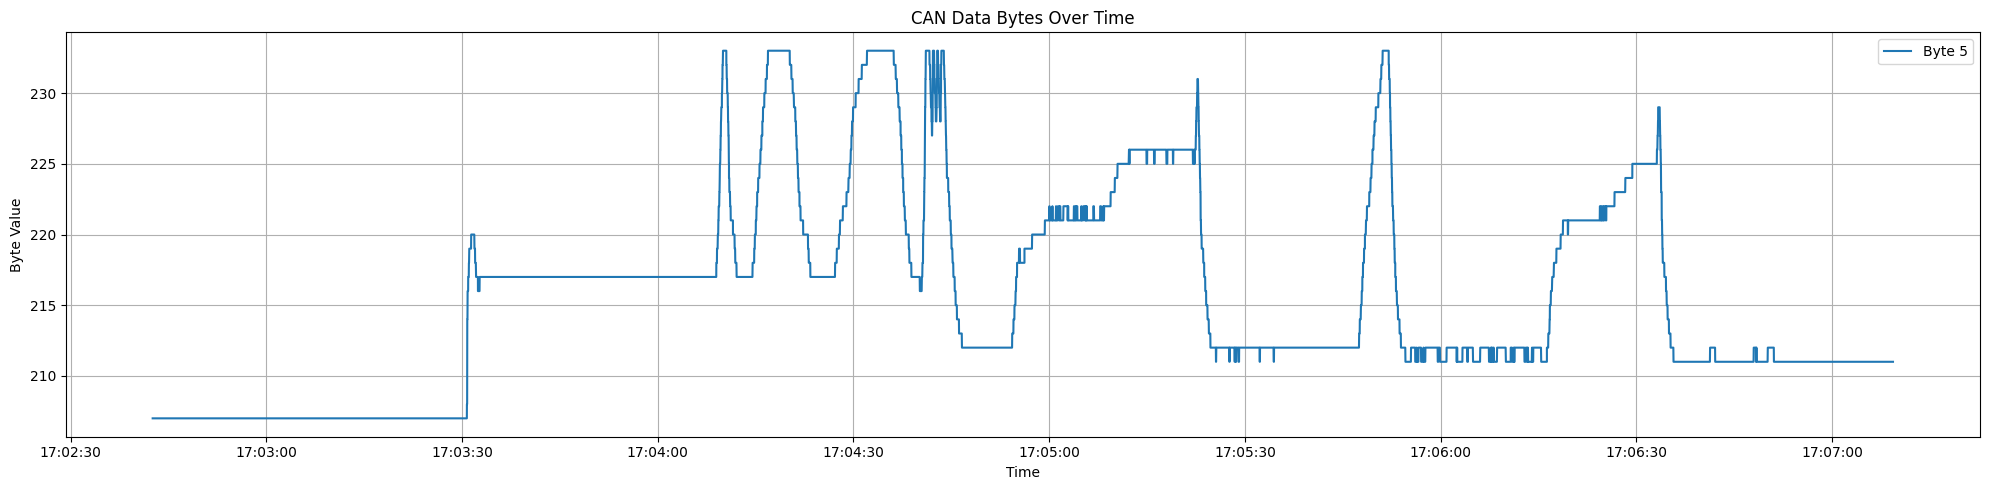

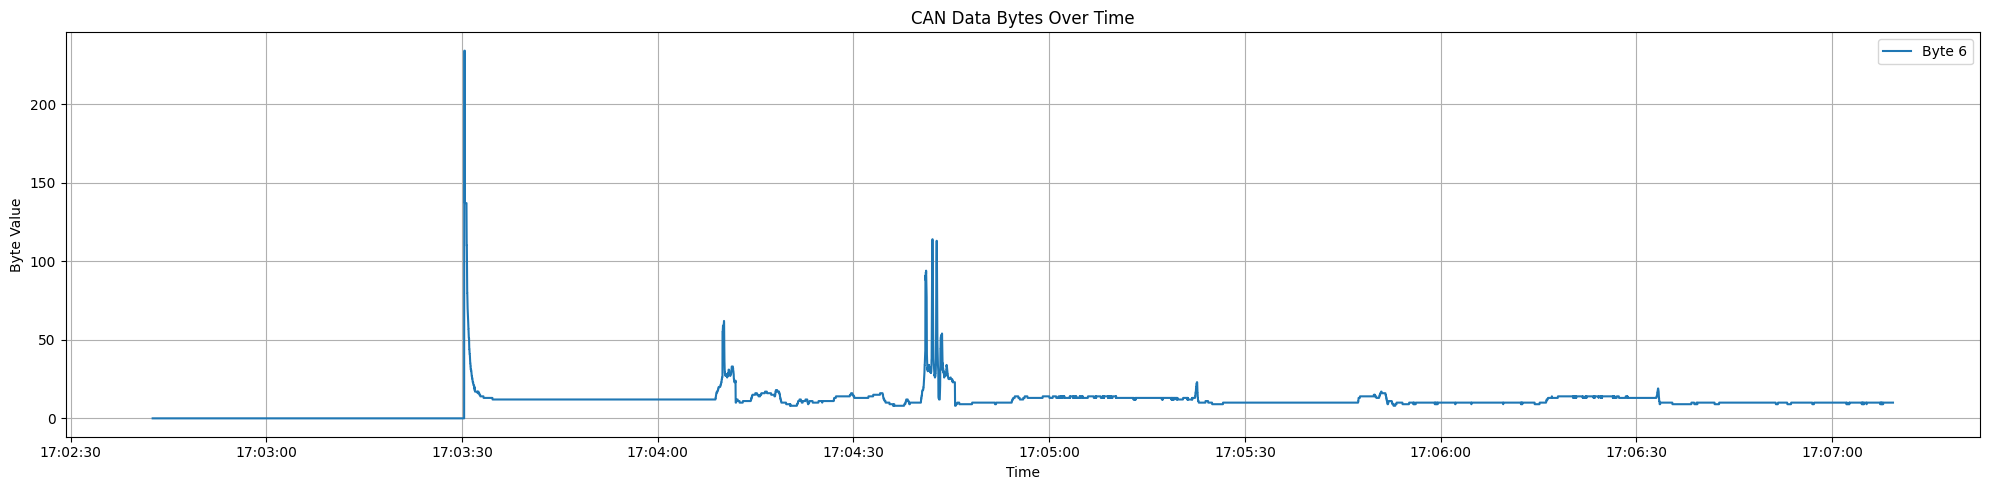

0x380
                    timestamp can_id                data   b0  b1  b2   b3  \
2     2025-06-19 17:02:42.586  0x380  103 0 0 128 0 0 17  103   0   0  128   
7     2025-06-19 17:02:42.604  0x380  103 0 0 128 0 0 17  103   0   0  128   
12    2025-06-19 17:02:42.625  0x380  103 0 0 128 0 0 27  103   0   0  128   
17    2025-06-19 17:02:42.641  0x380  103 0 0 128 0 0 40  103   0   0  128   
22    2025-06-19 17:02:42.657  0x380  103 0 0 128 0 0 44  103   0   0  128   
...                       ...    ...                 ...  ...  ..  ..  ...   
80509 2025-06-19 17:07:09.276  0x380   106 0 0 128 0 0 6  106   0   0  128   
80512 2025-06-19 17:07:09.287  0x380   106 0 0 128 0 0 6  106   0   0  128   
80516 2025-06-19 17:07:09.301  0x380   106 0 0 128 0 0 6  106   0   0  128   
80520 2025-06-19 17:07:09.314  0x380   106 0 0 128 0 0 6  106   0   0  128   
80527 2025-06-19 17:07:09.334  0x380   106 0 0 128 0 0 6  106   0   0  128   

       b4  b5  b6  
2       0   0  17  
7       0   0  17

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

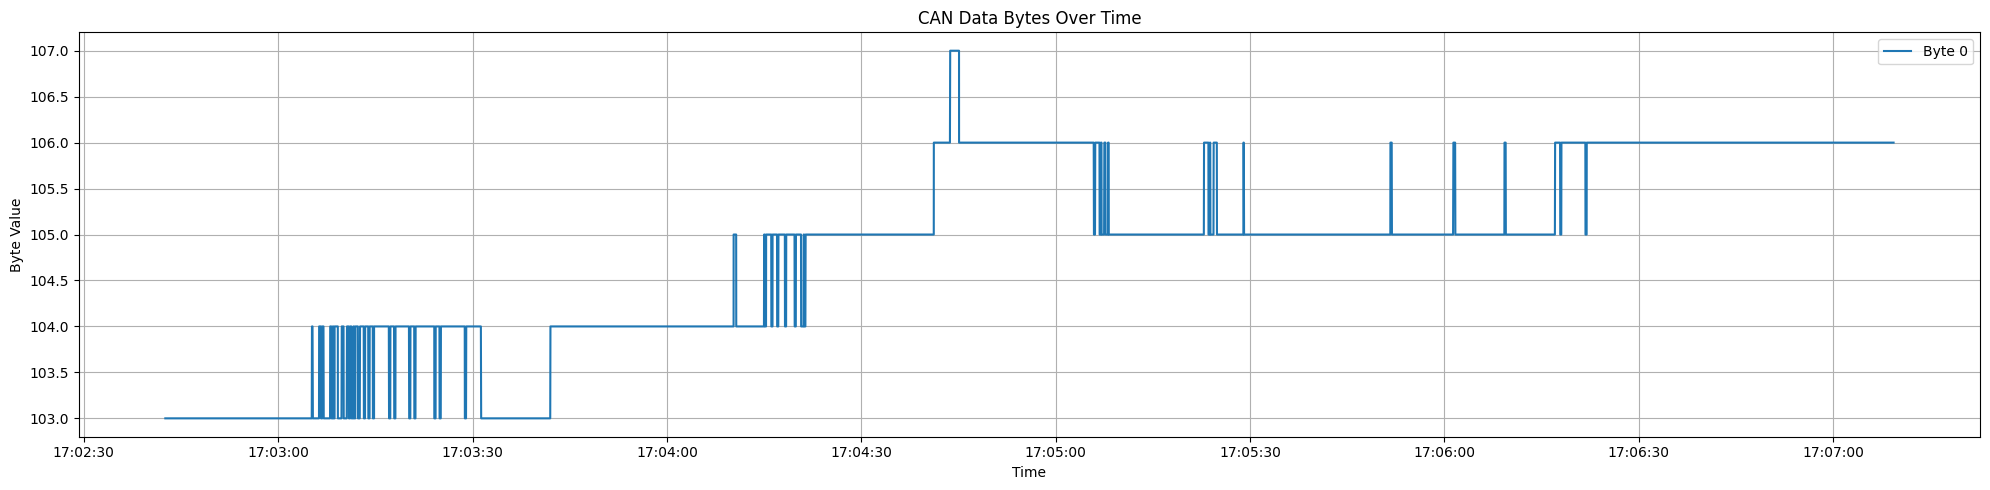

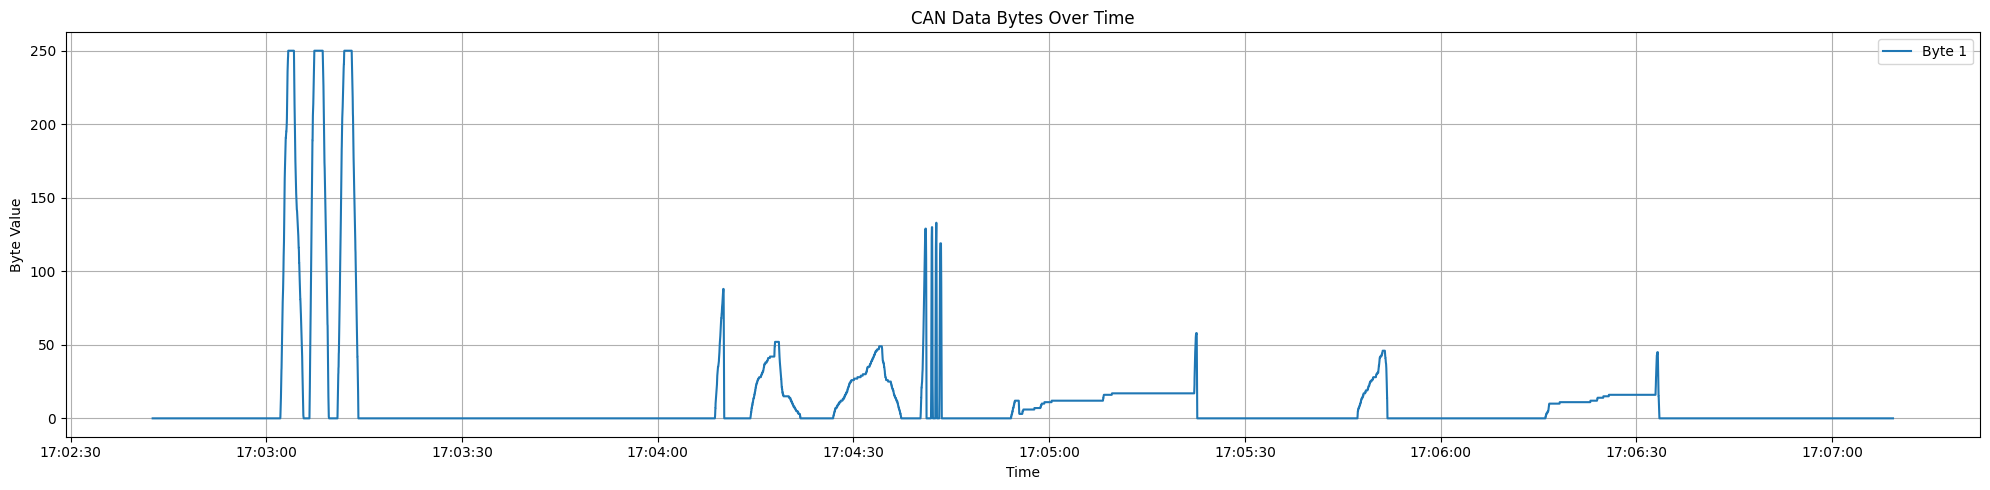

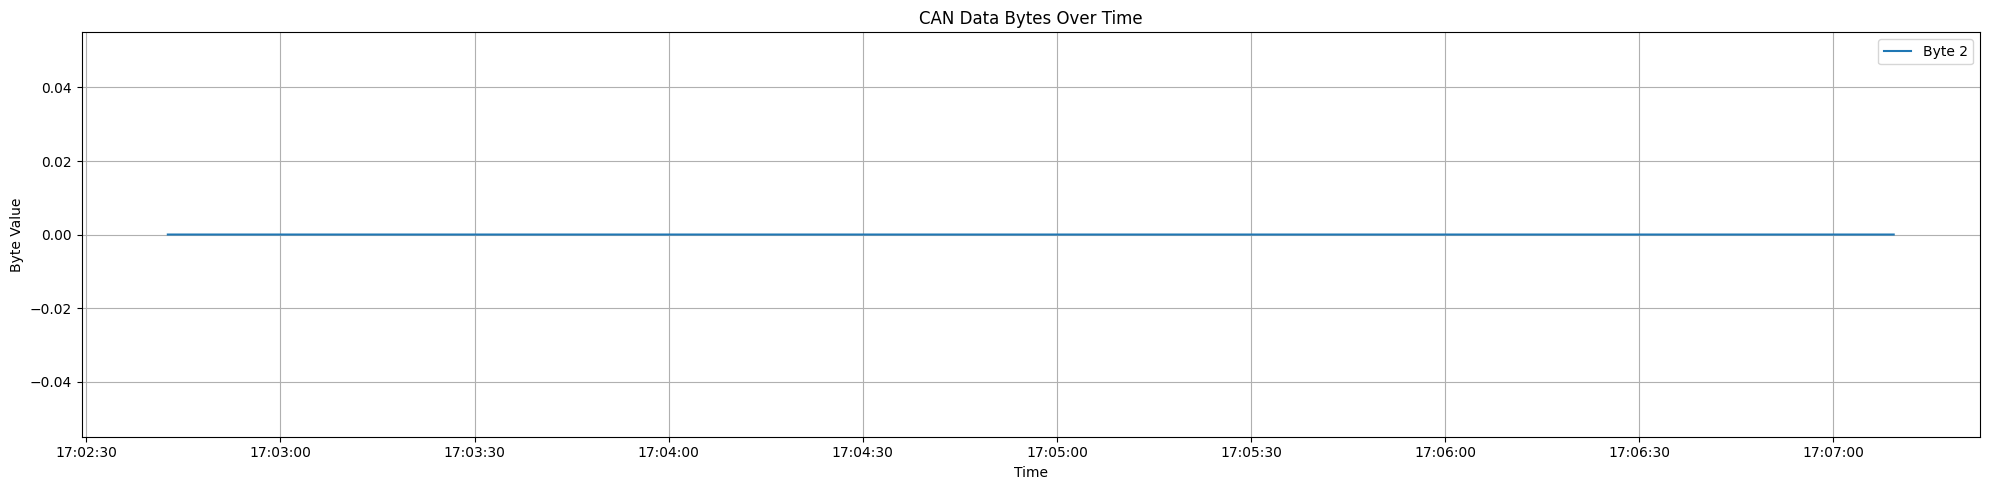

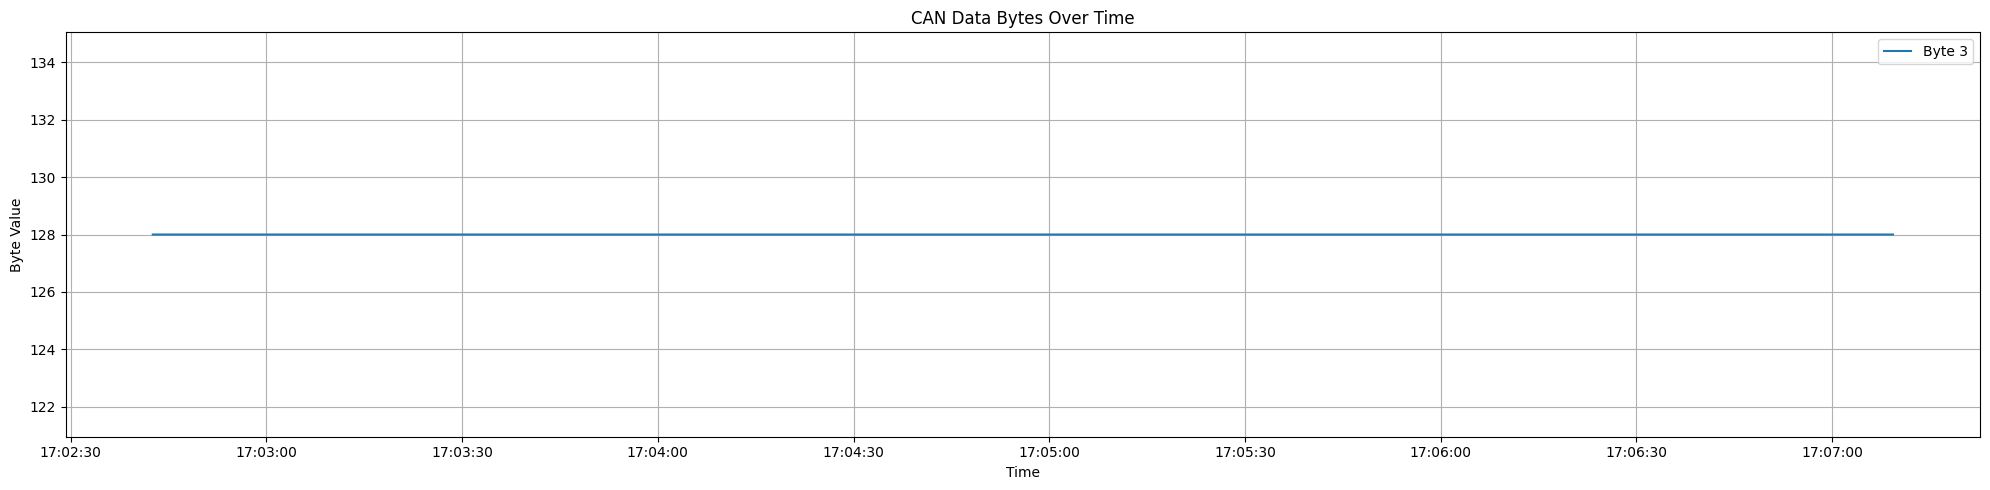

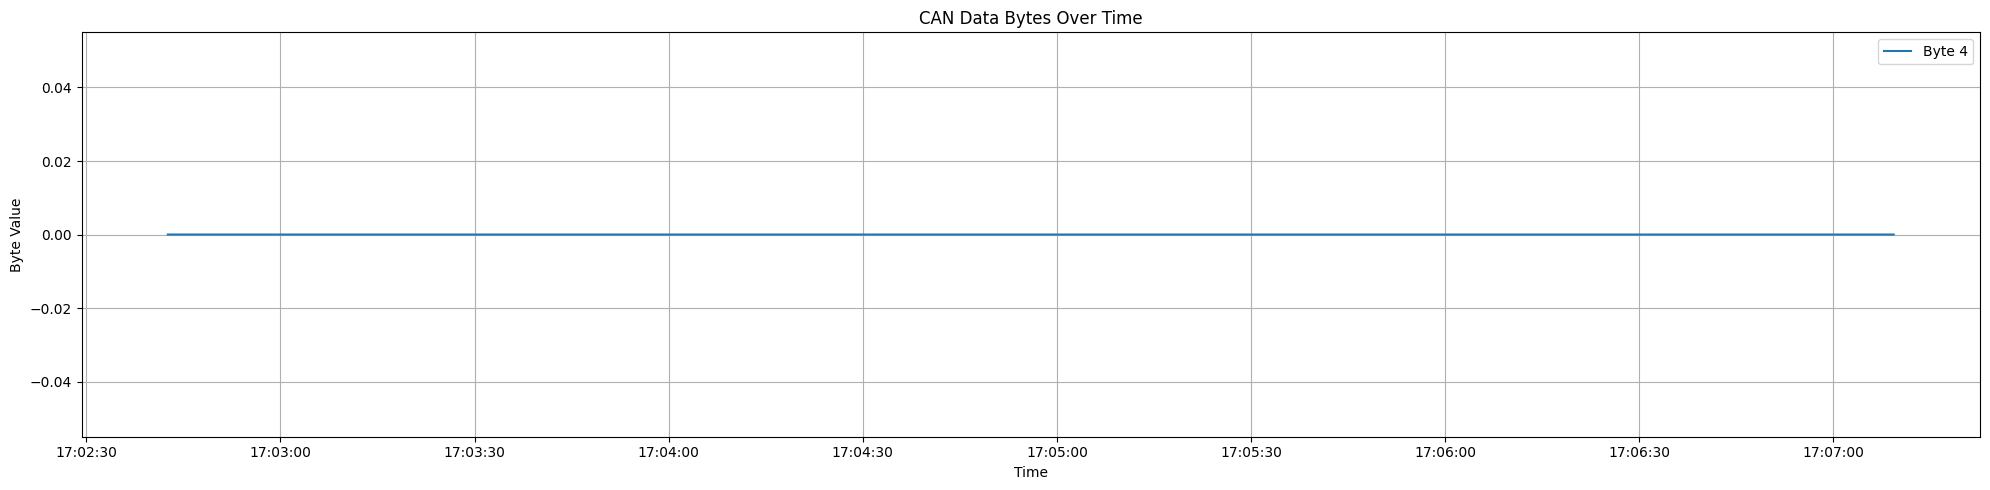

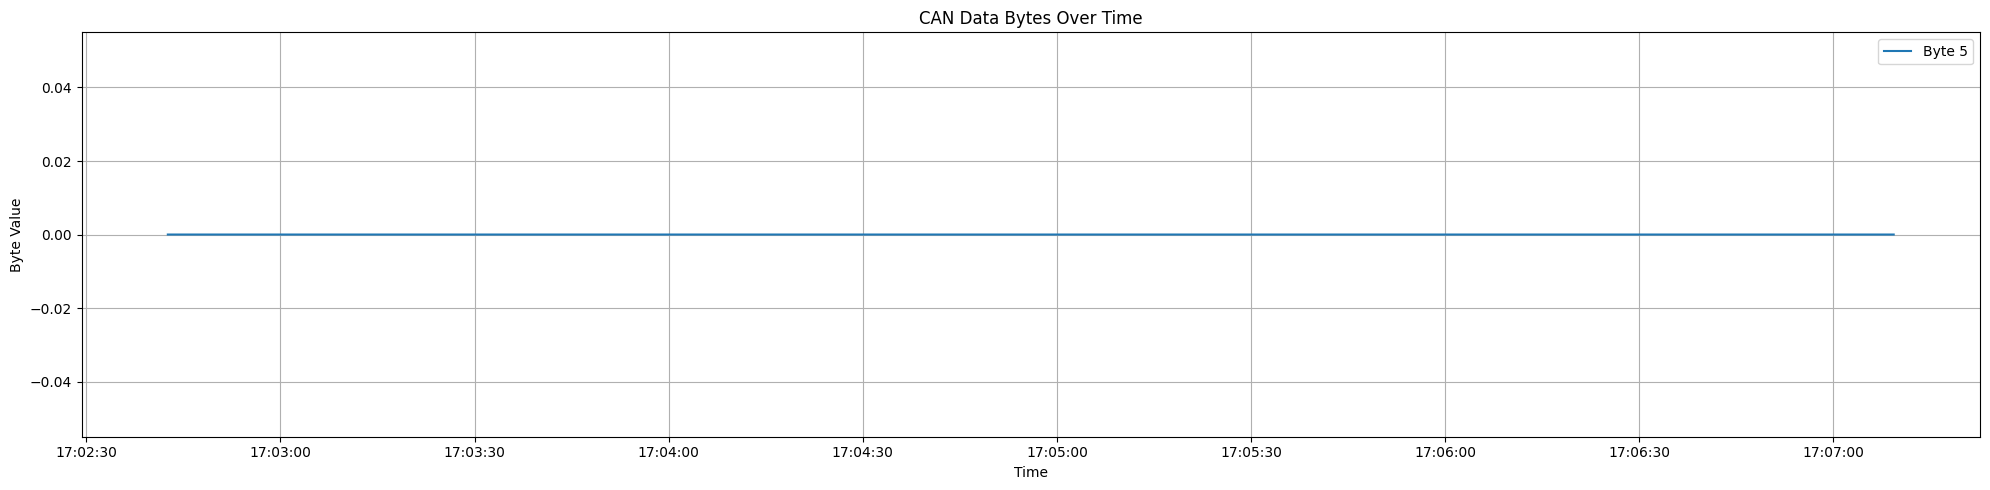

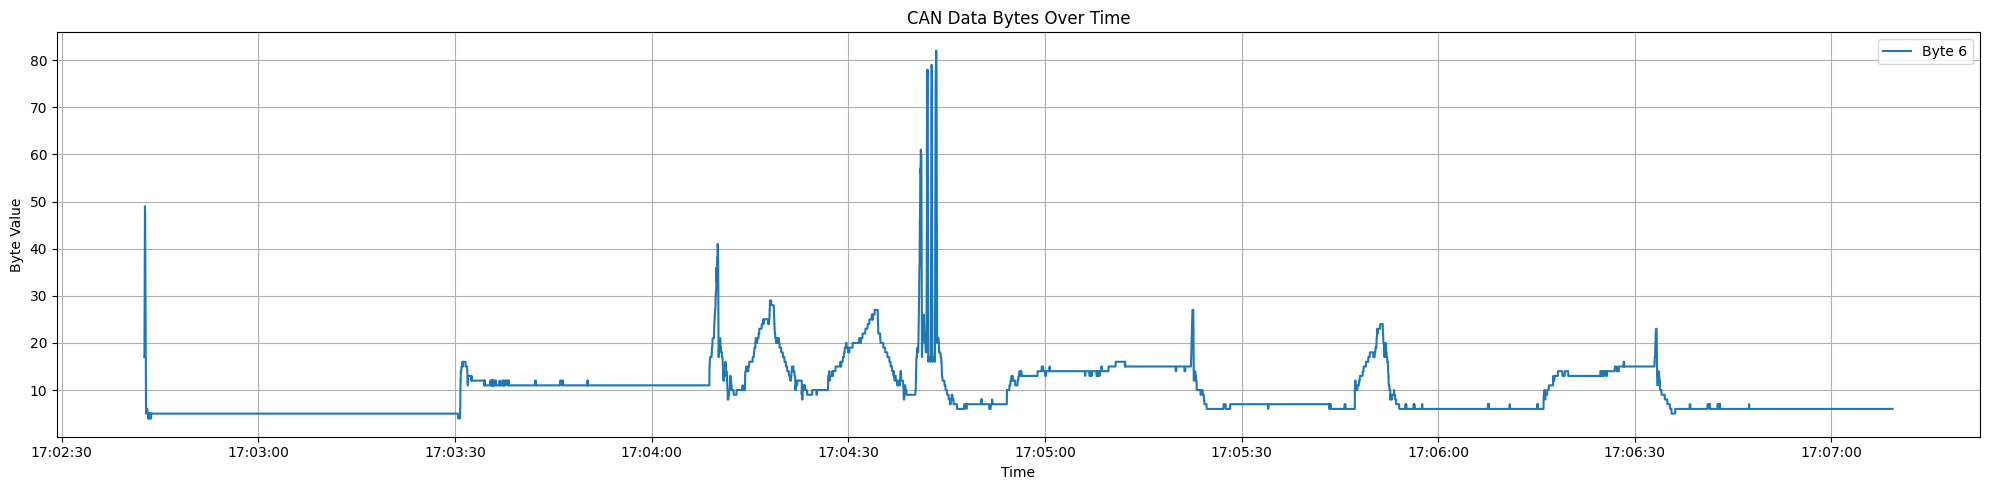

0x488
                    timestamp can_id                   data  b0   b1   b2  \
3     2025-06-19 17:02:42.586  0x488    0 73 116 166 0 0 32   0   73  116   
8     2025-06-19 17:02:42.604  0x488   1 139 116 166 0 0 48   1  139  116   
13    2025-06-19 17:02:42.626  0x488   2 130 116 166 0 0 64   2  130  116   
18    2025-06-19 17:02:42.641  0x488   2 120 116 166 0 0 80   2  120  116   
23    2025-06-19 17:02:42.659  0x488   3 111 116 166 0 0 96   3  111  116   
...                       ...    ...                    ...  ..  ...  ...   
80481 2025-06-19 17:07:09.182  0x488  22 22 116 166 0 0 128  22   22  116   
80499 2025-06-19 17:07:09.248  0x488  22 22 116 166 0 0 224  22   22  116   
80501 2025-06-19 17:07:09.254  0x488  22 22 116 166 0 0 240  22   22  116   
80513 2025-06-19 17:07:09.293  0x488   22 23 116 166 0 0 48  22   23  116   
80517 2025-06-19 17:07:09.301  0x488   22 23 116 166 0 0 64  22   23  116   

        b3  b4  b5   b6  
3      166   0   0   32  
8      166   0   

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

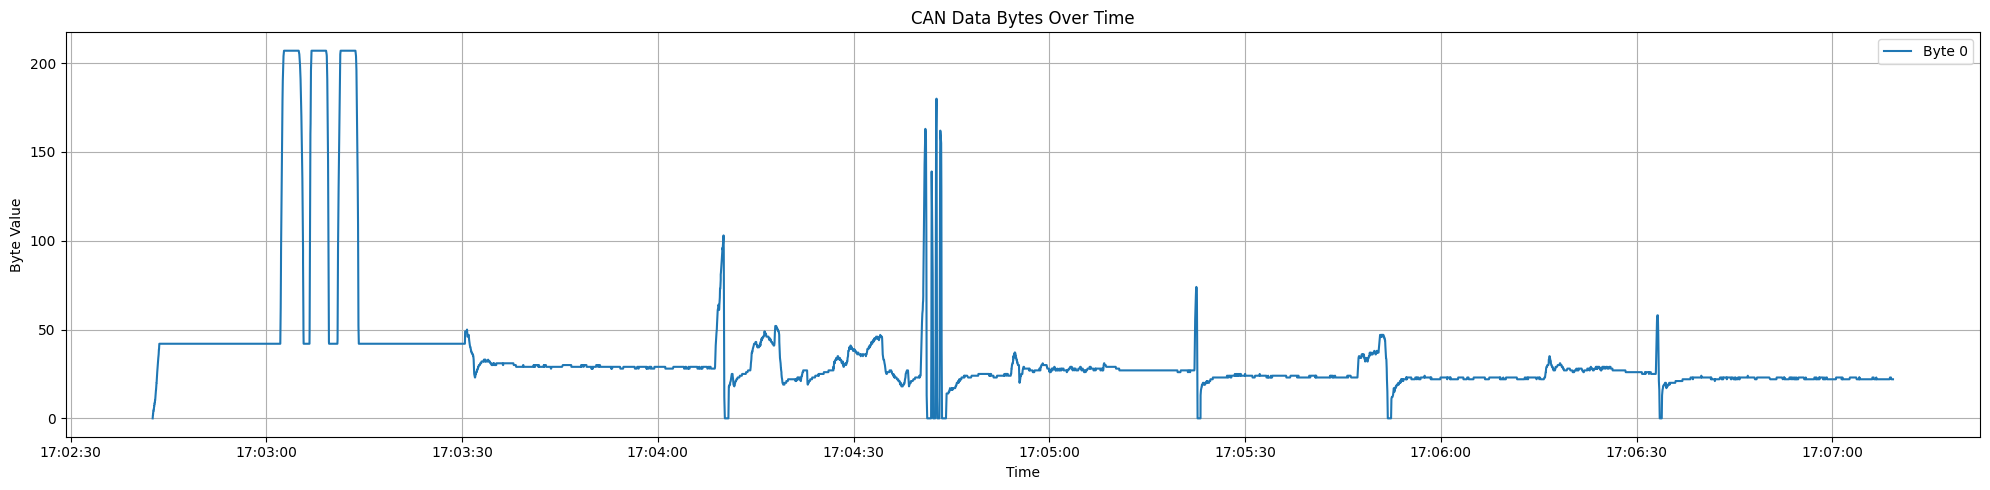

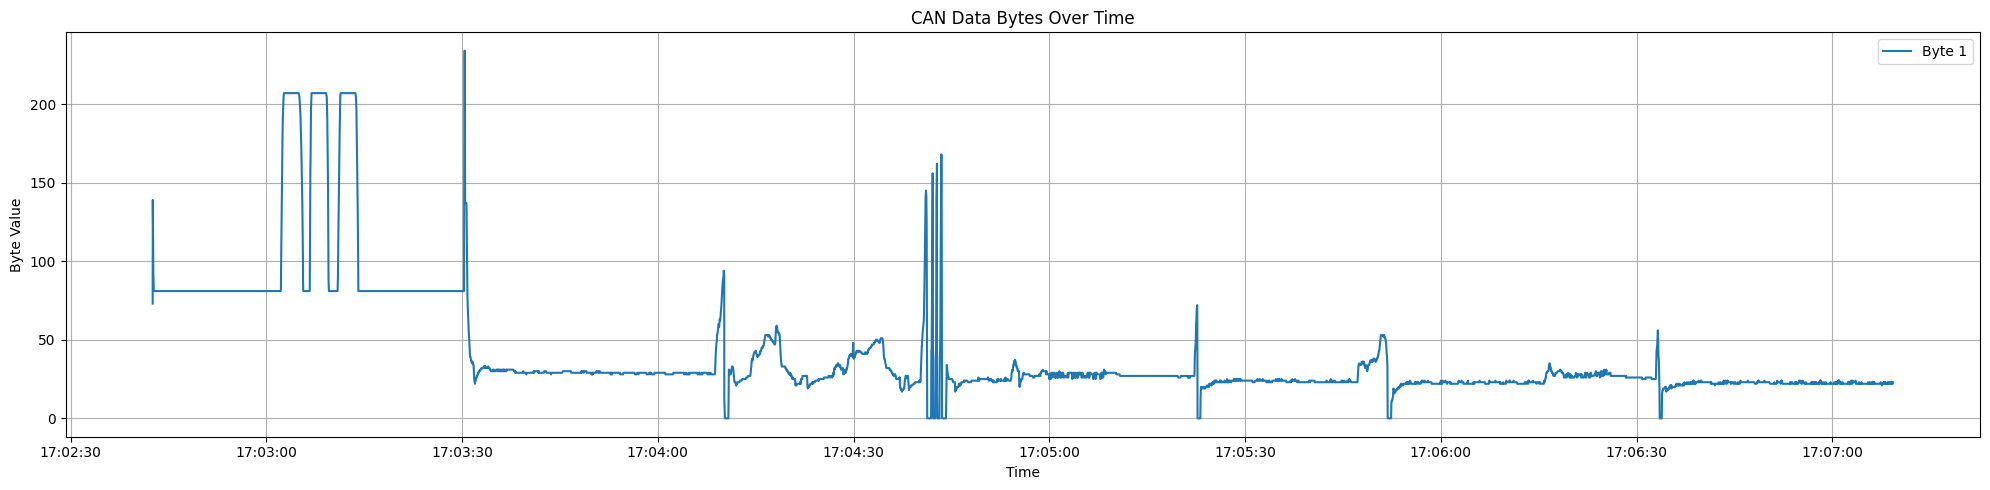

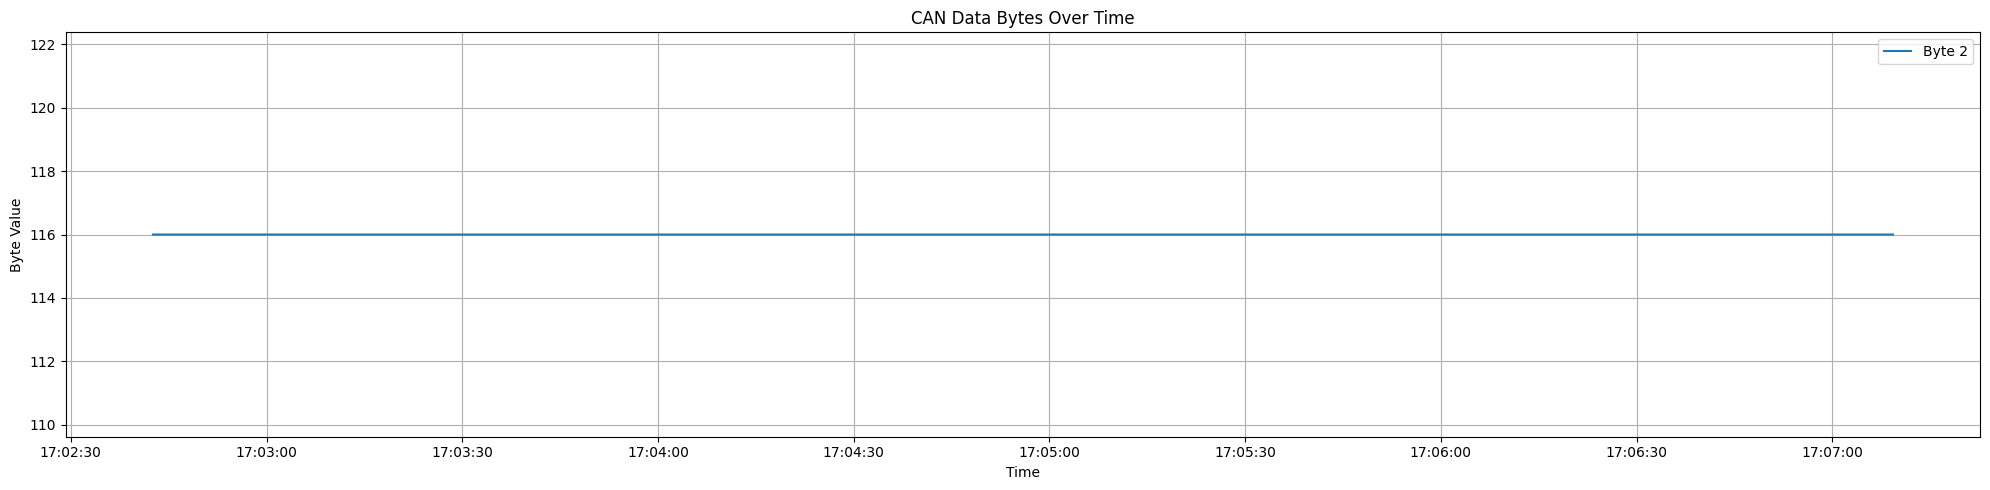

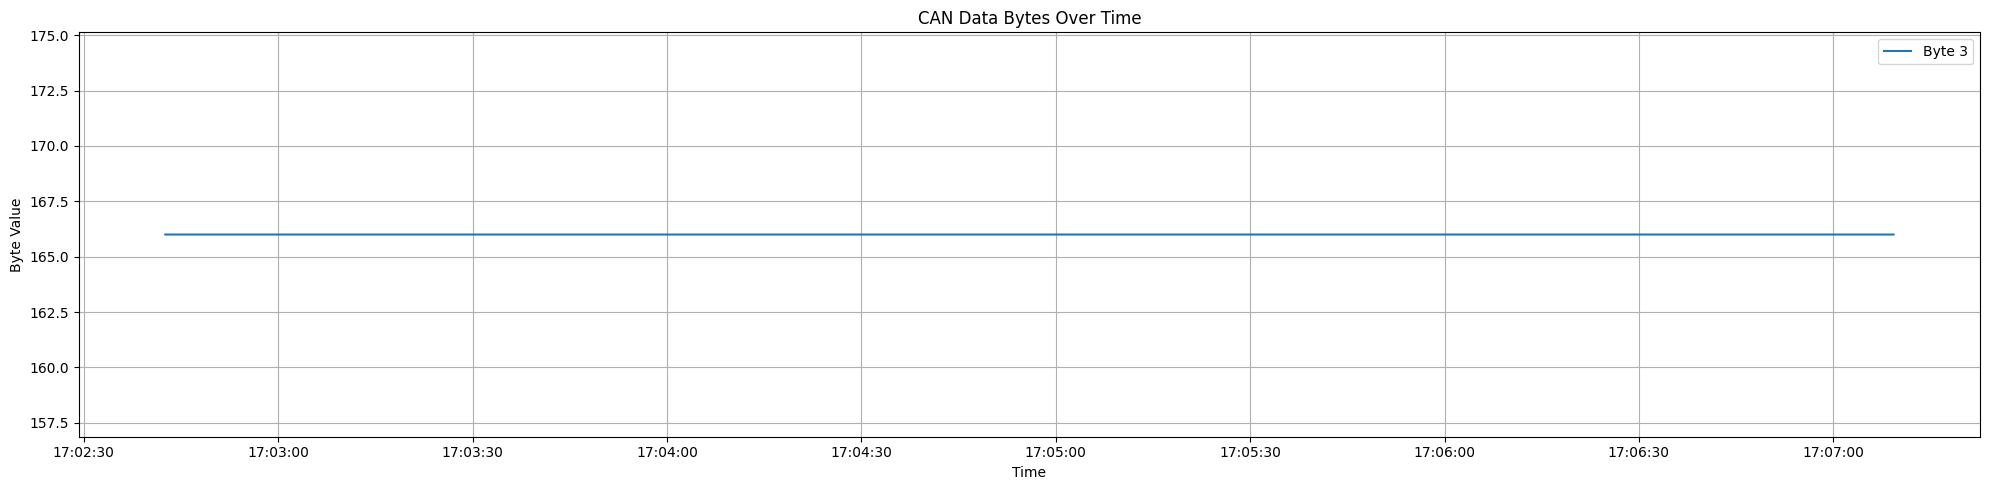

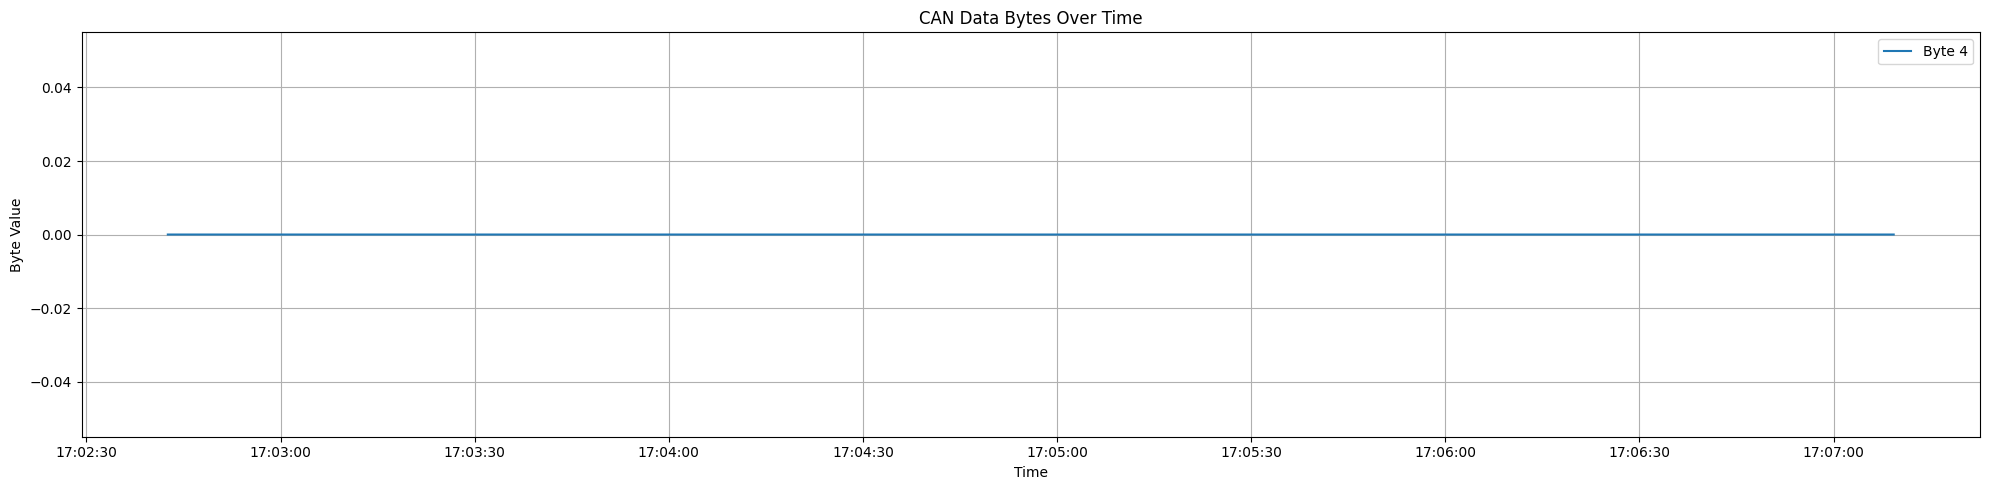

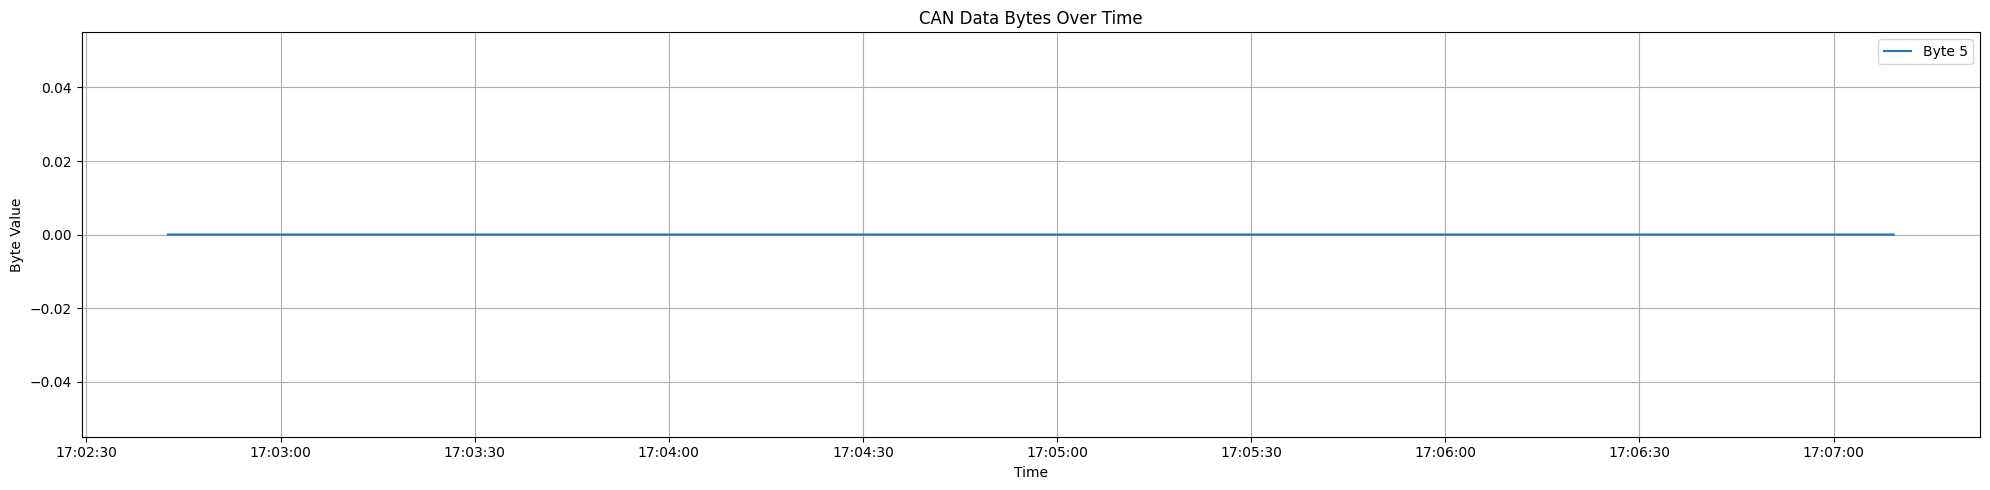

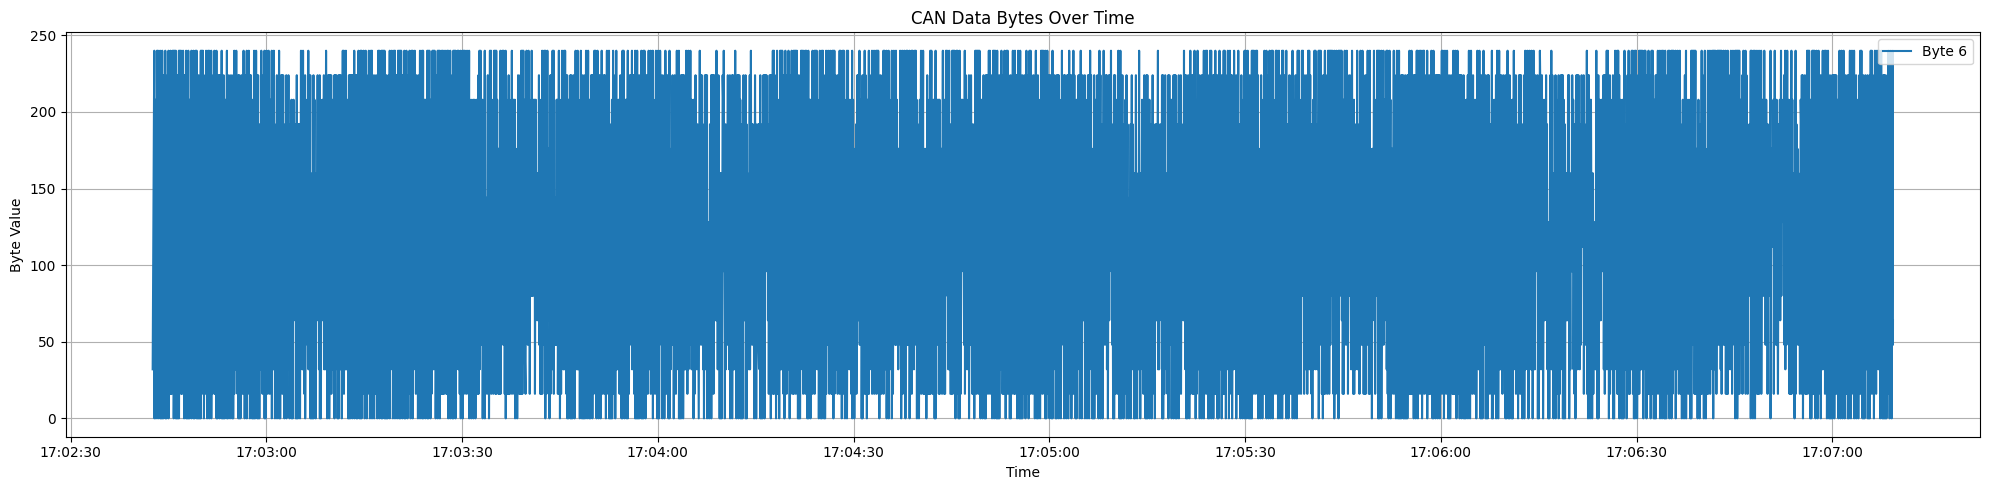

0x588
Didnt work
0x480
                    timestamp can_id                  data  b0   b1   b2  b3  \
9     2025-06-19 17:02:42.604  0x480      12 0 0 0 64 0 67  12    0    0   0   
19    2025-06-19 17:02:42.641  0x480      12 0 0 0 64 0 67  12    0    0   0   
29    2025-06-19 17:02:42.681  0x480      12 0 0 0 64 0 67  12    0    0   0   
45    2025-06-19 17:02:42.728  0x480      12 0 0 0 64 0 21  12    0    0   0   
57    2025-06-19 17:02:42.760  0x480      12 0 0 0 64 0 21  12    0    0   0   
...                       ...    ...                   ...  ..  ...  ...  ..   
80230 2025-06-19 17:07:08.354  0x480    0 4 190 0 64 2 247   0    4  190   0   
80327 2025-06-19 17:07:08.668  0x480   0 61 190 0 64 2 206   0   61  190   0   
80424 2025-06-19 17:07:08.994  0x480  0 128 190 0 64 2 115   0  128  190   0   
80482 2025-06-19 17:07:09.192  0x480  0 168 190 0 64 2 148   0  168  190   0   
80502 2025-06-19 17:07:09.258  0x480  0 184 190 0 64 2 132   0  184  190   0   

       b4  b5   

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

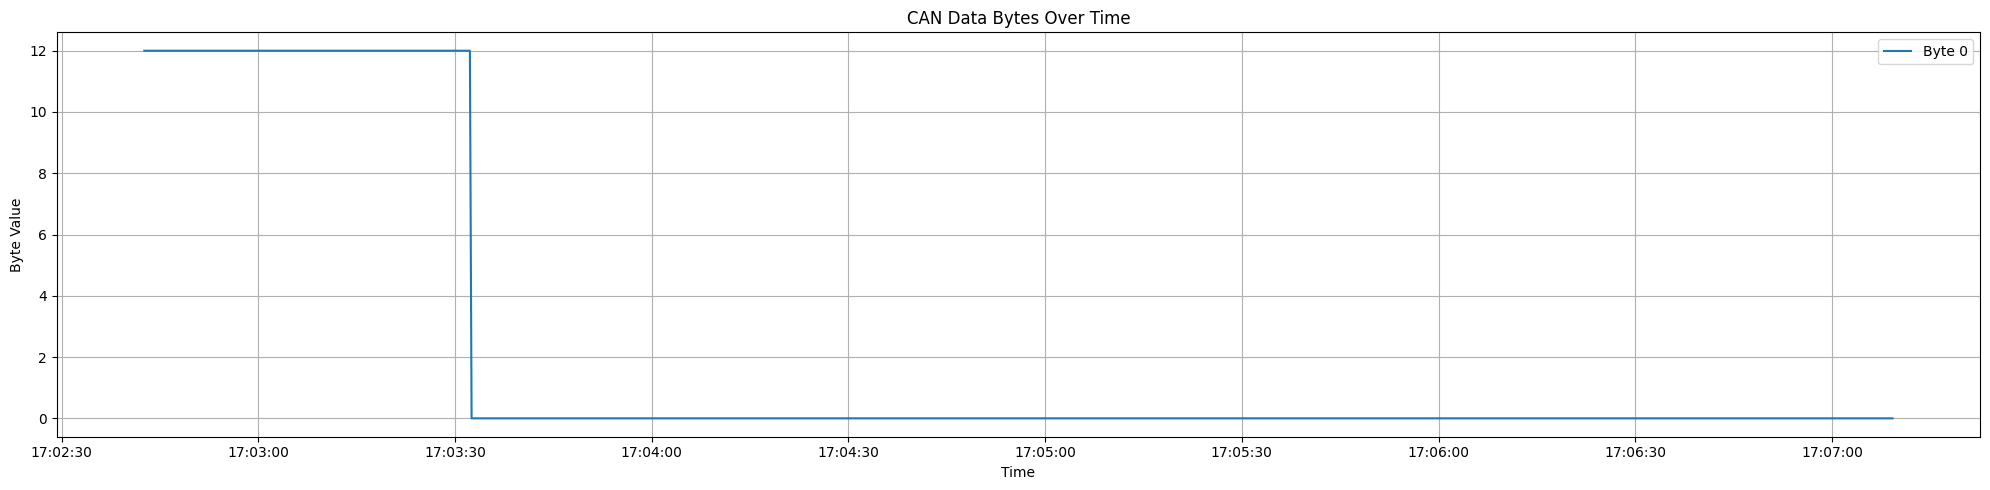

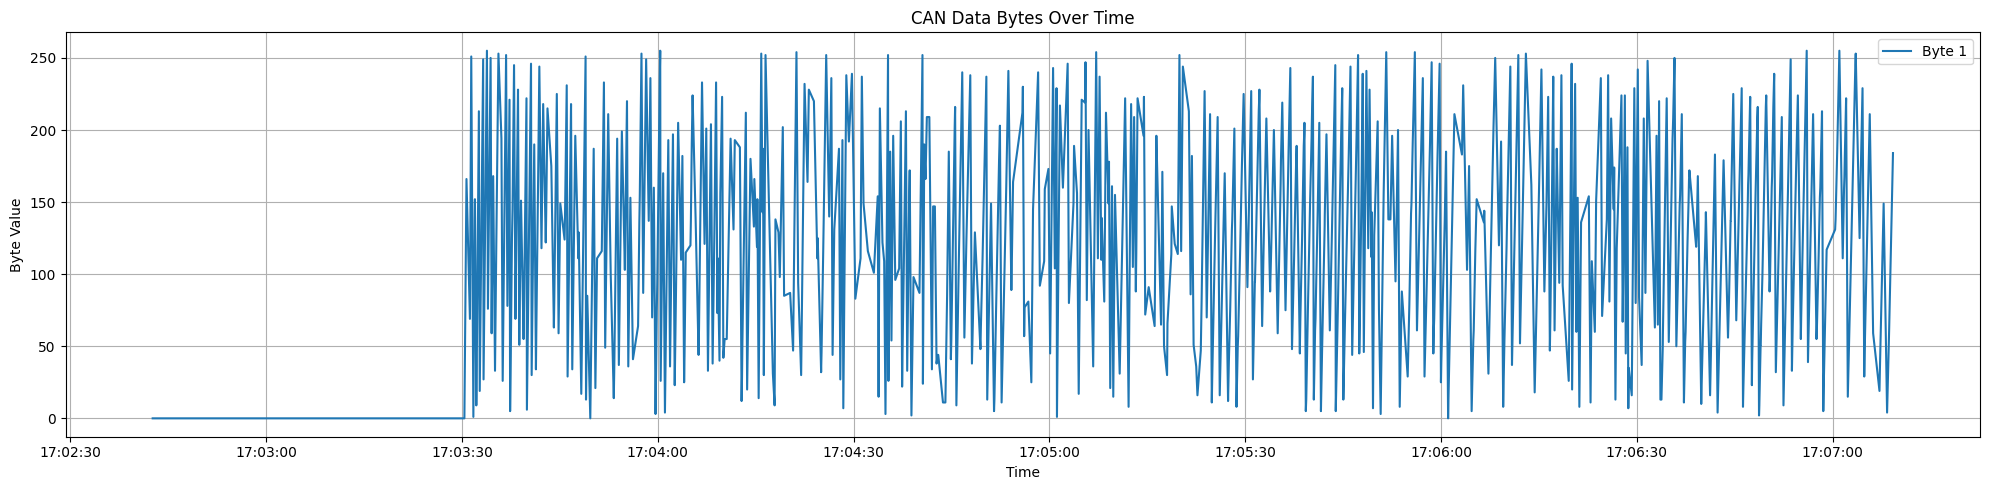

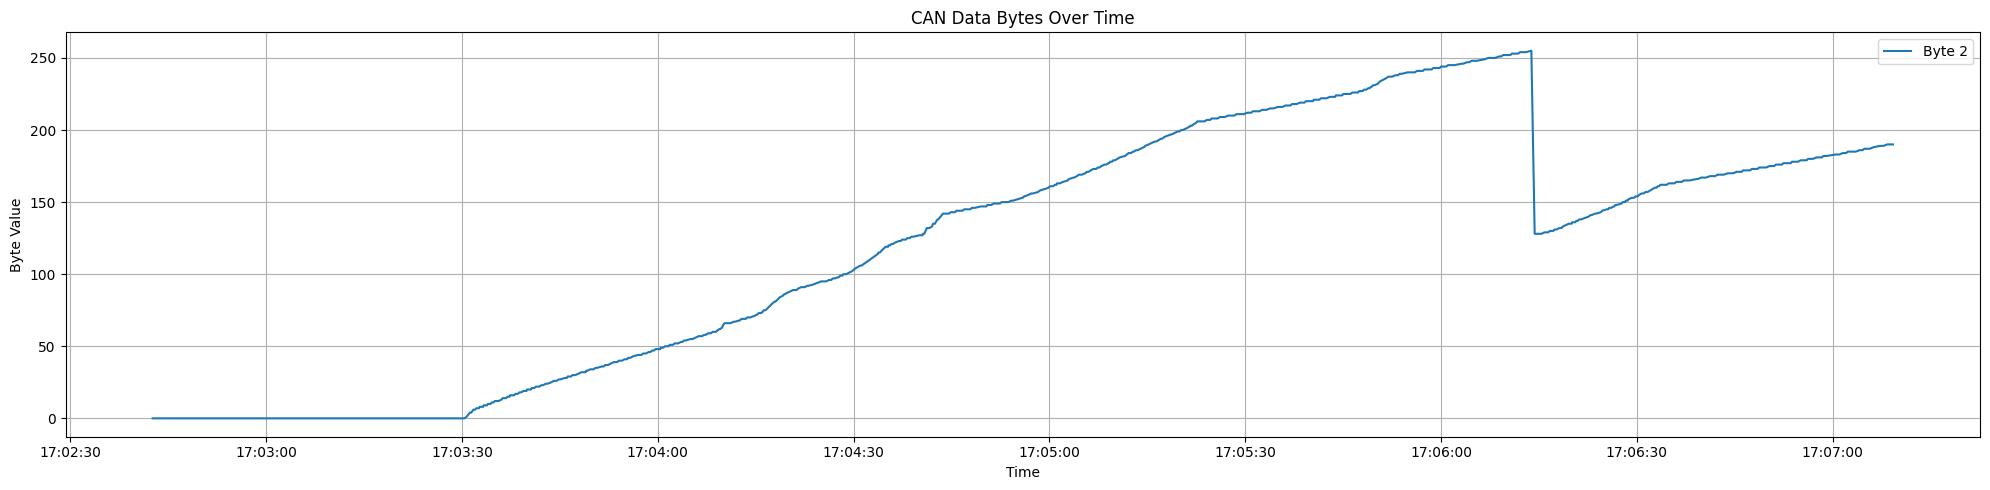

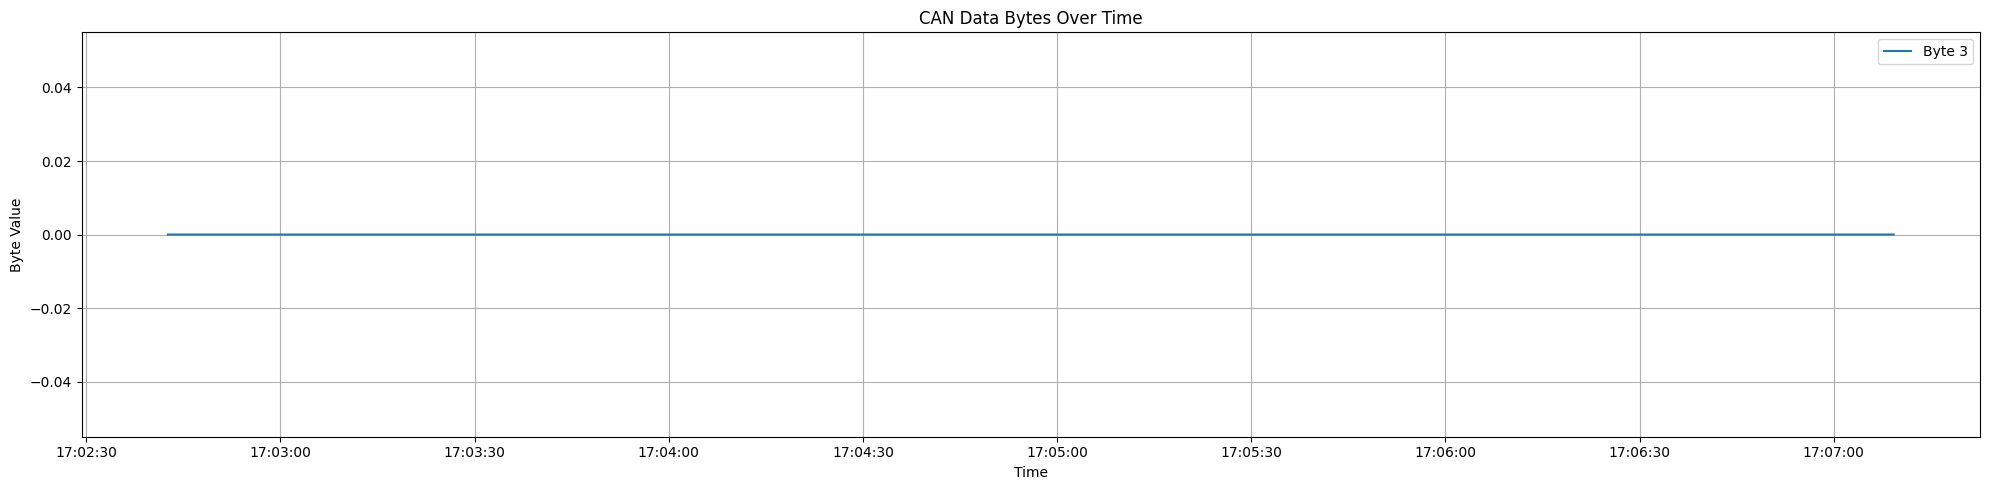

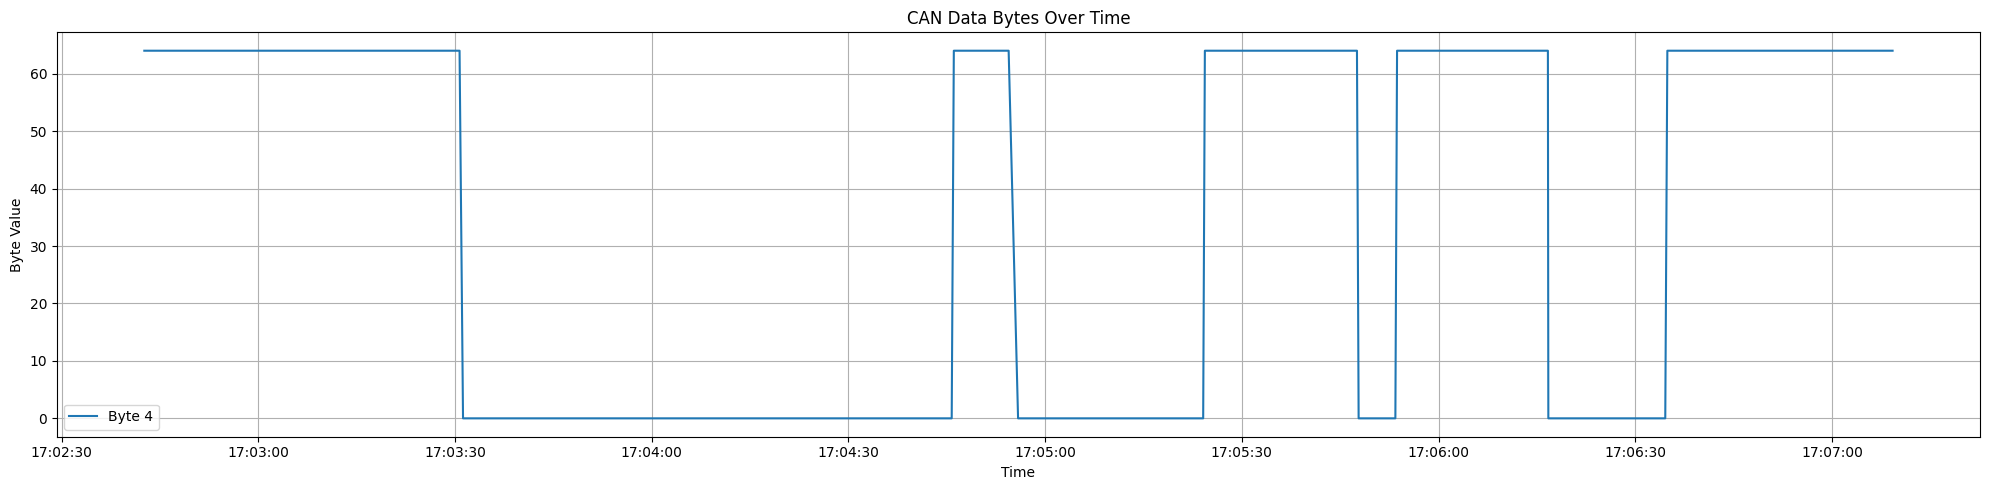

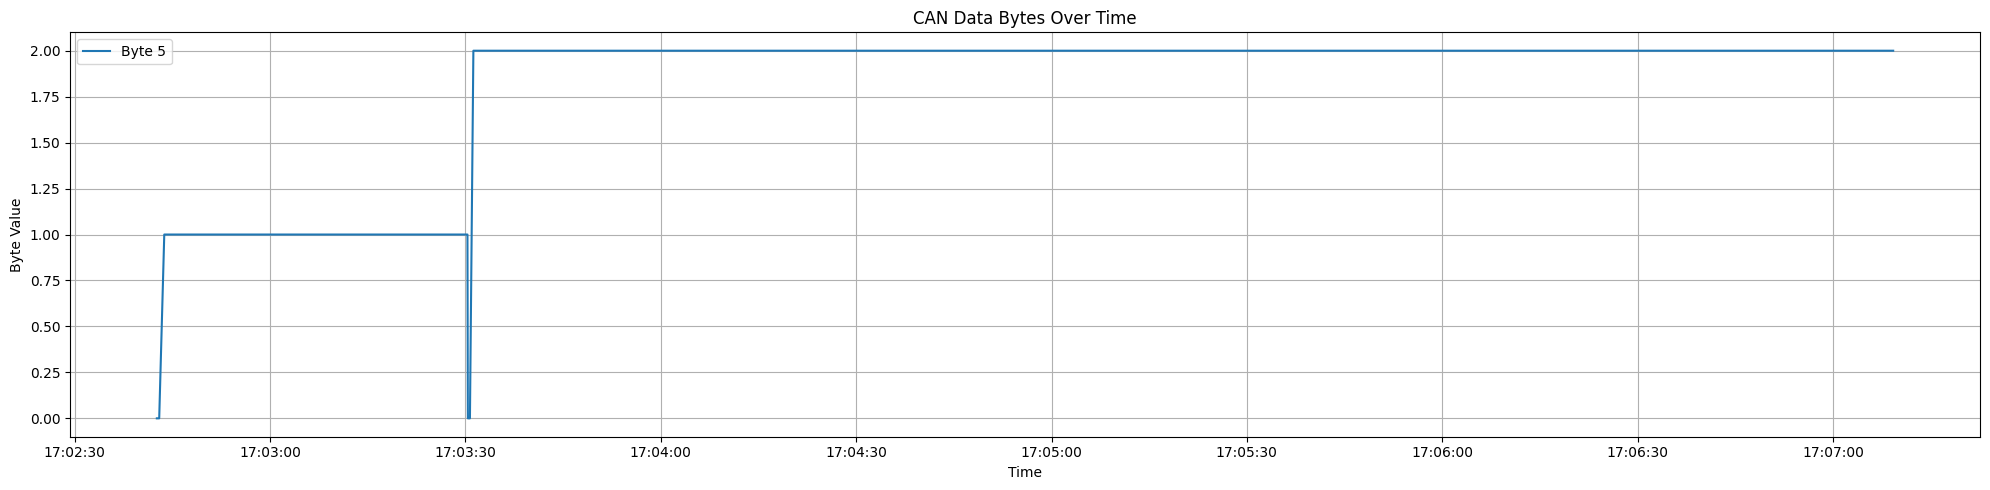

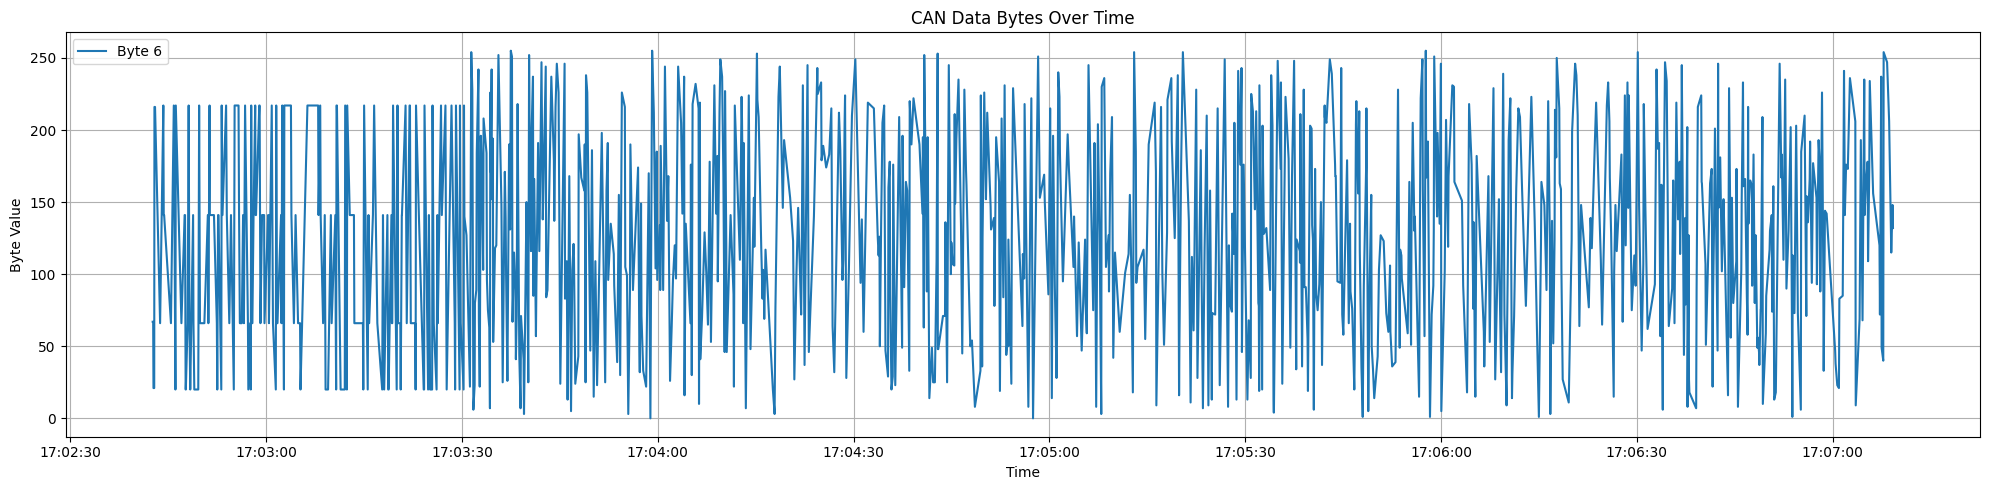

0x320
                    timestamp can_id             data  b0   b1  b2  b3  b4  \
35    2025-06-19 17:02:42.696  0x320    3 0 0 0 0 0 0   3    0   0   0   0   
51    2025-06-19 17:02:42.744  0x320    3 0 0 0 0 0 0   3    0   0   0   0   
63    2025-06-19 17:02:42.786  0x320    3 0 0 0 0 0 0   3    0   0   0   0   
76    2025-06-19 17:02:42.822  0x320    3 0 0 0 0 0 0   3    0   0   0   0   
87    2025-06-19 17:02:42.863  0x320    3 0 0 0 0 0 0   3    0   0   0   0   
...                       ...    ...              ...  ..  ...  ..  ..  ..   
80503 2025-06-19 17:07:09.258  0x320  3 135 0 0 0 0 0   3  135   0   0   0   
80522 2025-06-19 17:07:09.321  0x320  3 135 0 0 0 0 0   3  135   0   0   0   
80528 2025-06-19 17:07:09.342  0x320  0 135 0 0 0 0 0   0  135   0   0   0   
80530 2025-06-19 17:07:09.349  0x320  0 135 0 0 0 0 0   0  135   0   0   0   
80535 2025-06-19 17:07:09.357  0x320  0 135 0 0 0 0 0   0  135   0   0   0   

       b5  b6  
35      0   0  
51      0   0  
63      0

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

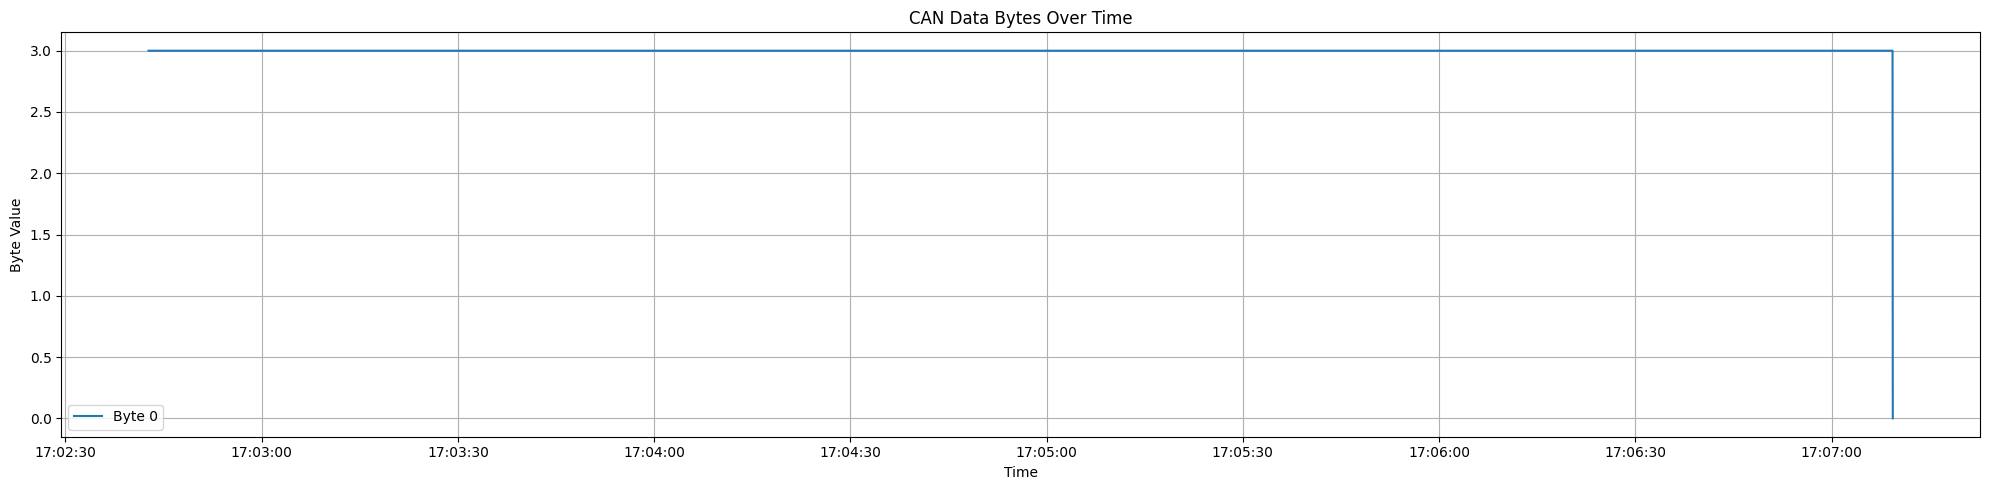

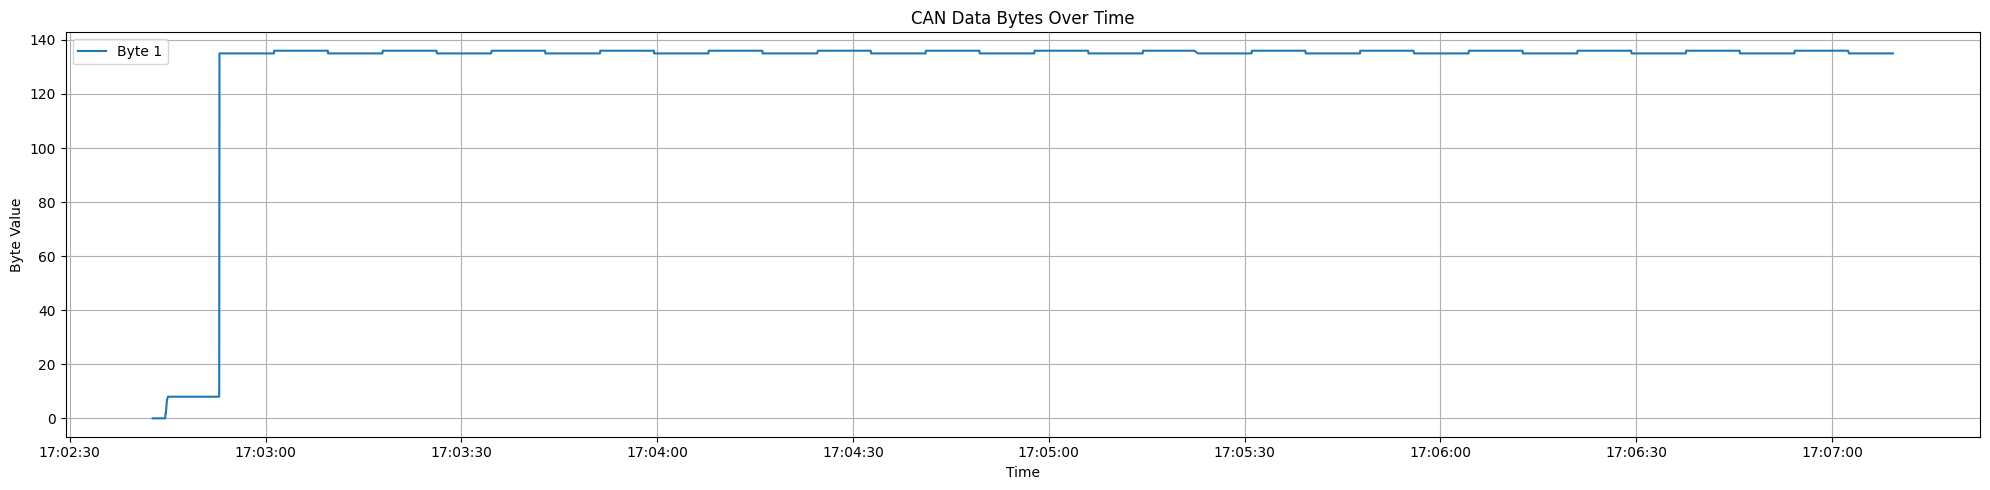

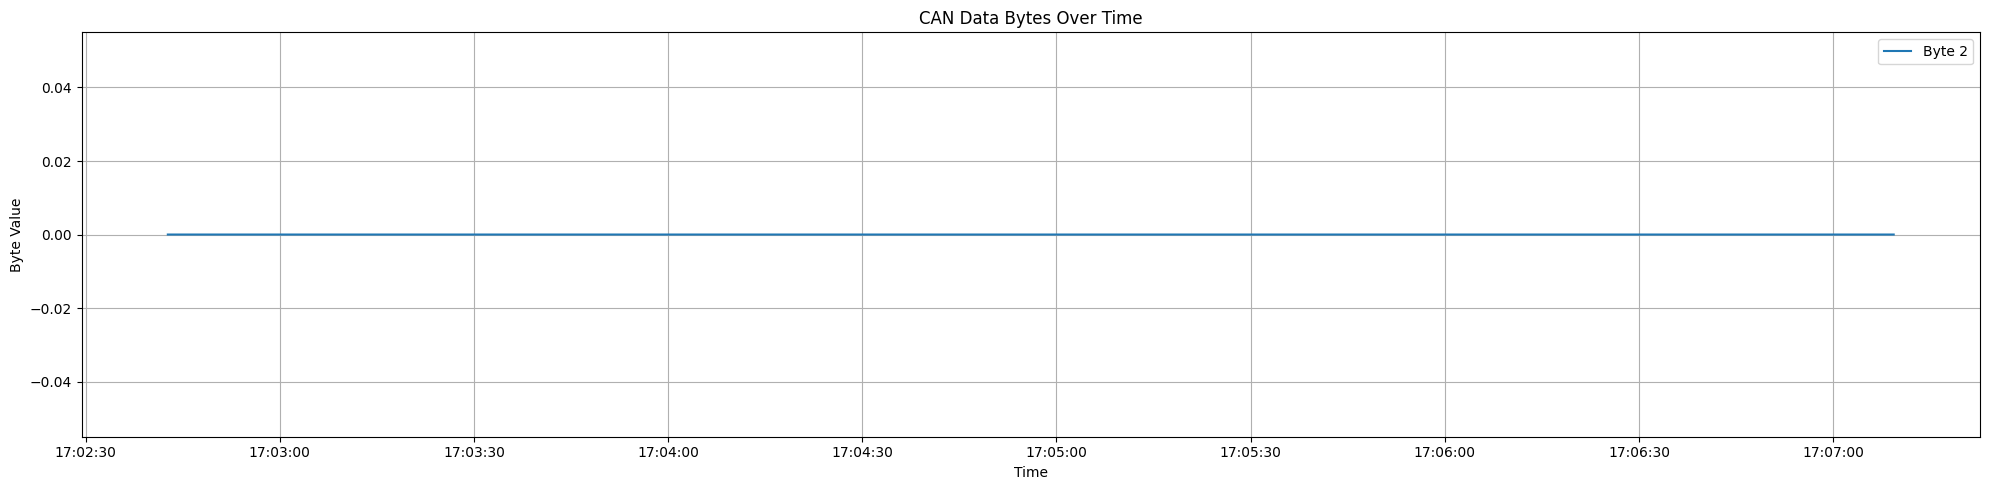

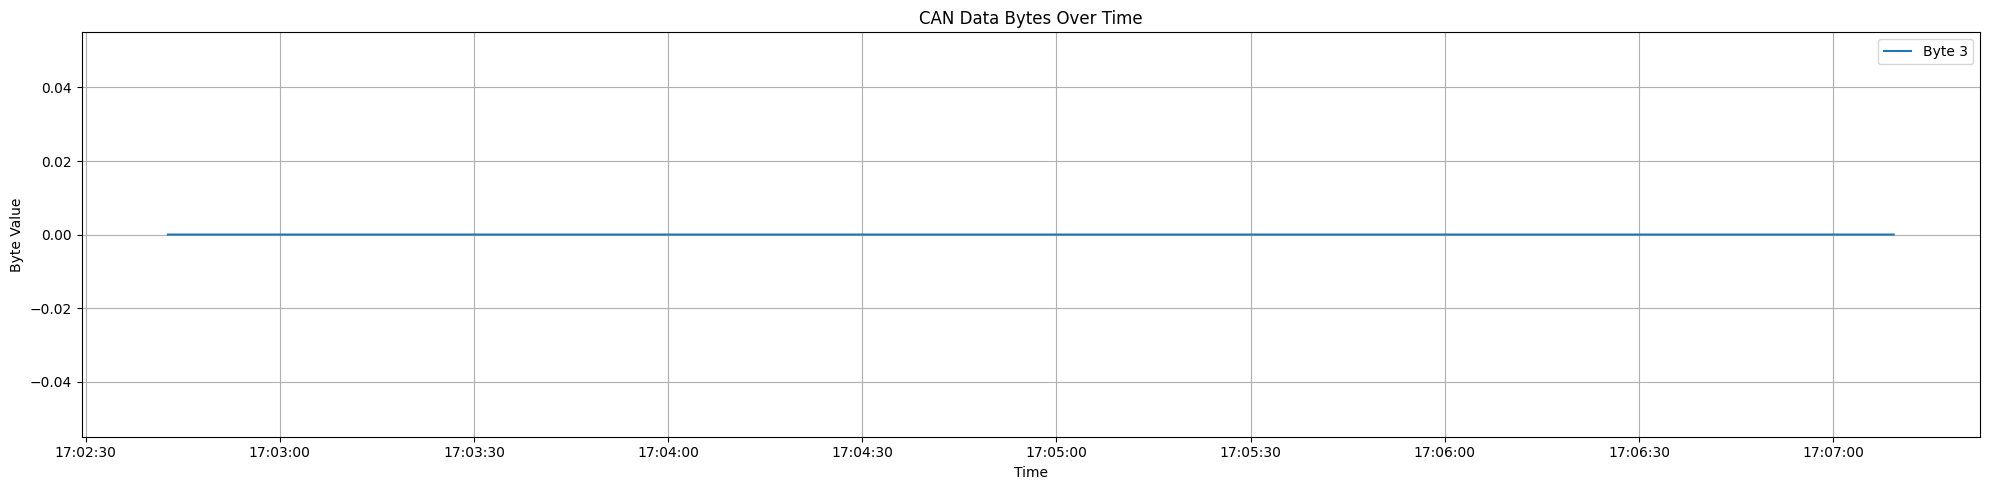

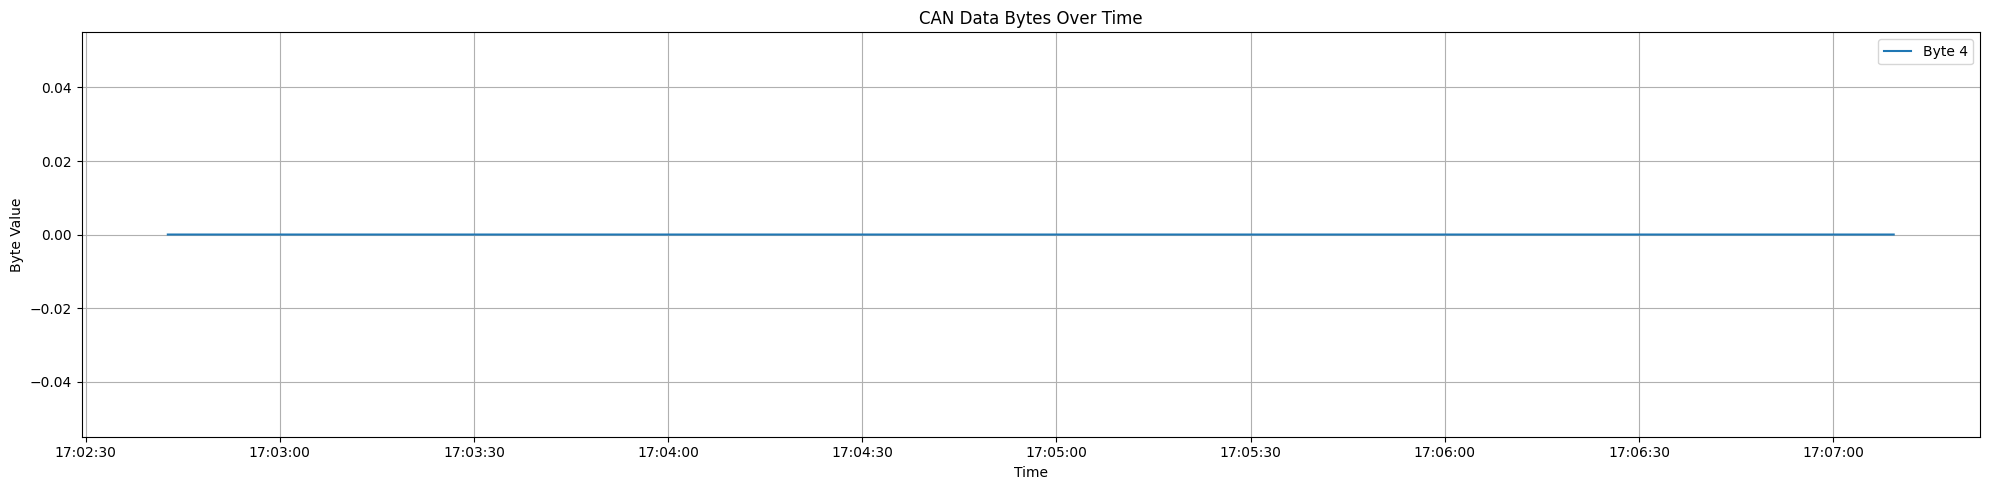

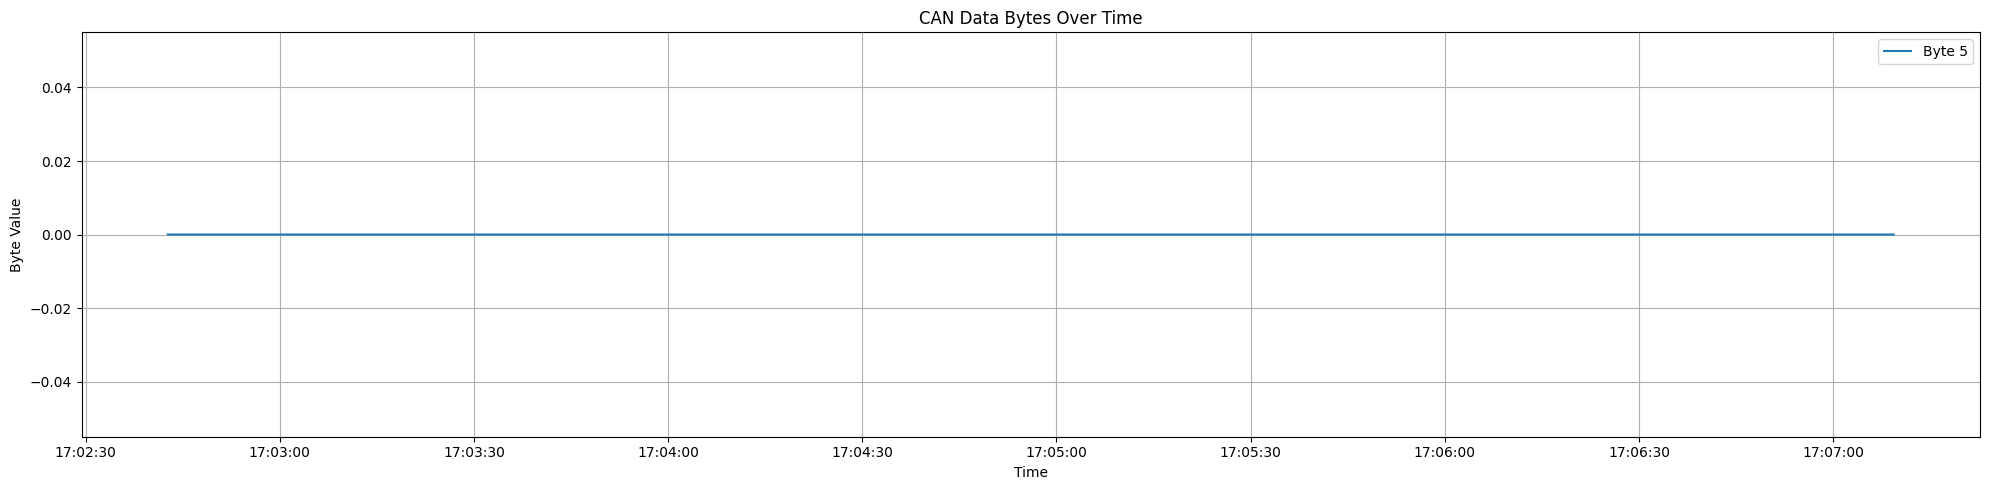

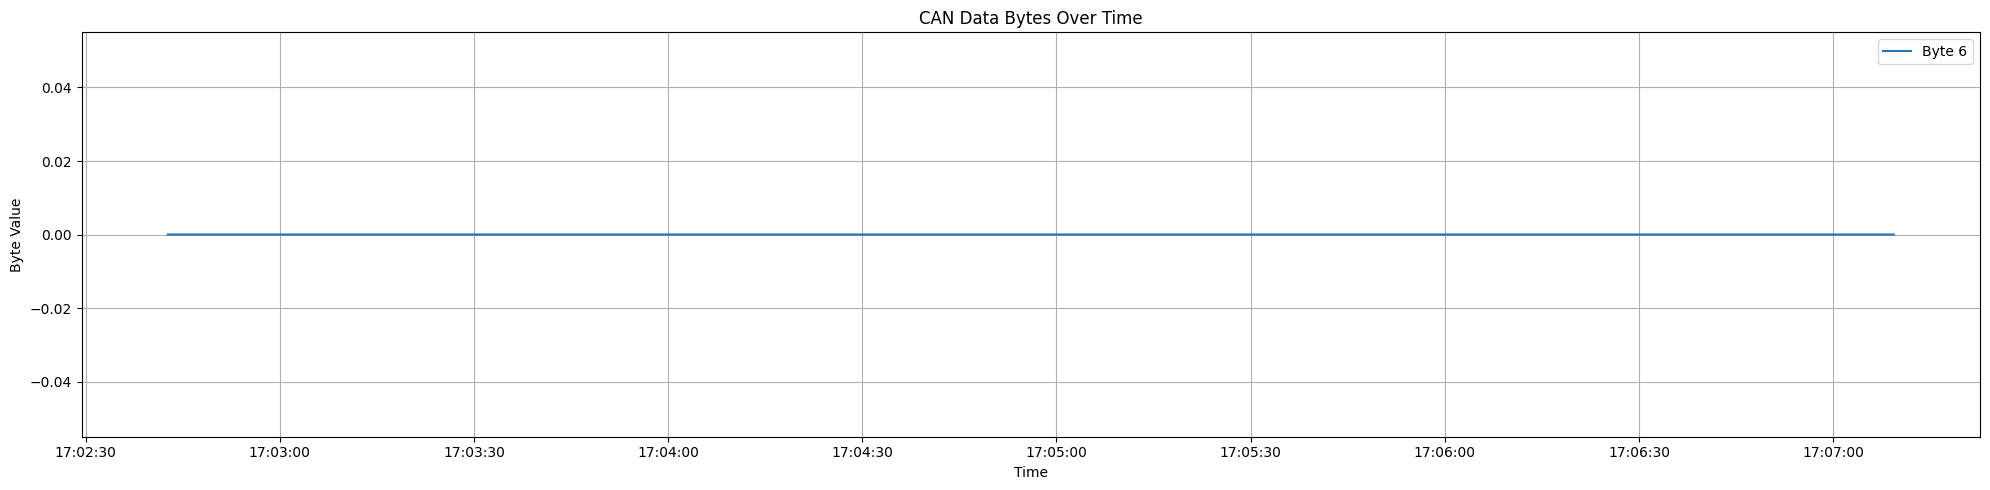

0x420
                    timestamp can_id               data  b0  b1  b2   b3  b4  \
36    2025-06-19 17:02:42.696  0x420  0 0 0 104 0 128 0   0   0   0  104   0   
212   2025-06-19 17:02:43.256  0x420  0 0 0 104 0 128 0   0   0   0  104   0   
463   2025-06-19 17:02:44.057  0x420  0 0 0 104 0 128 0   0   0   0  104   0   
713   2025-06-19 17:02:44.855  0x420  0 0 0 104 0 128 0   0   0   0  104   0   
1215  2025-06-19 17:02:46.459  0x420  0 0 0 104 0 128 0   0   0   0  104   0   
...                       ...    ...                ...  ..  ..  ..  ...  ..   
79844 2025-06-19 17:07:07.063  0x420  0 0 0 142 0 128 0   0   0   0  142   0   
79904 2025-06-19 17:07:07.265  0x420  0 0 0 142 0 128 0   0   0   0  142   0   
79965 2025-06-19 17:07:07.467  0x420  0 0 0 142 0 128 0   0   0   0  142   0   
80445 2025-06-19 17:07:09.063  0x420  0 0 0 143 0 128 0   0   0   0  143   0   
80504 2025-06-19 17:07:09.265  0x420  0 0 0 143 0 128 0   0   0   0  143   0   

        b5  b6  
36     128   0  

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

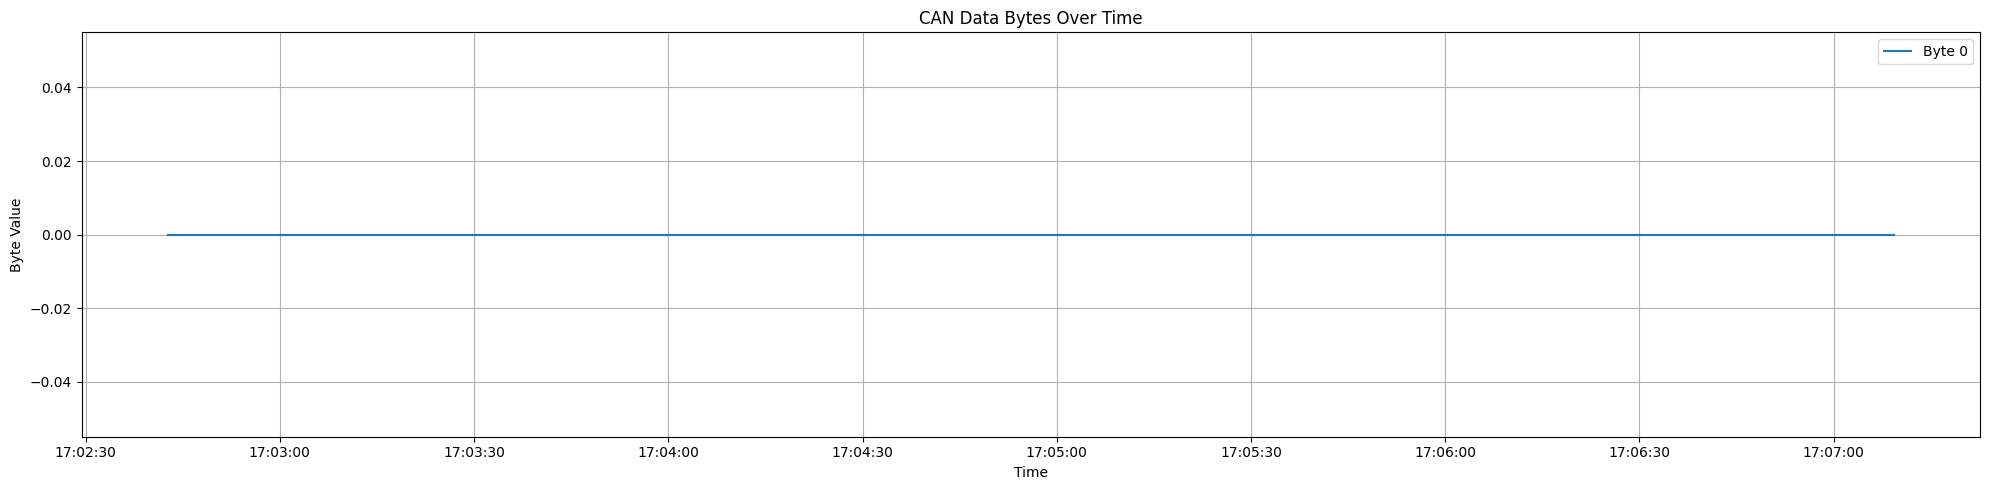

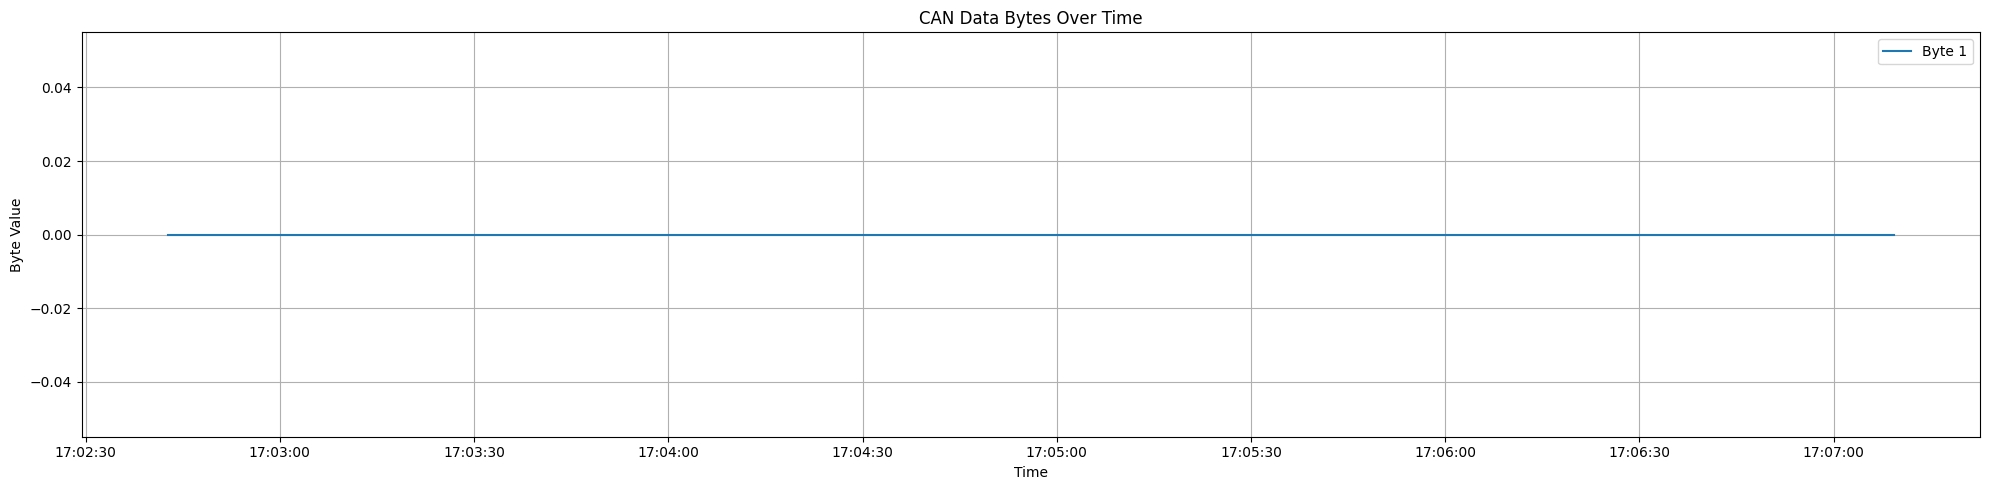

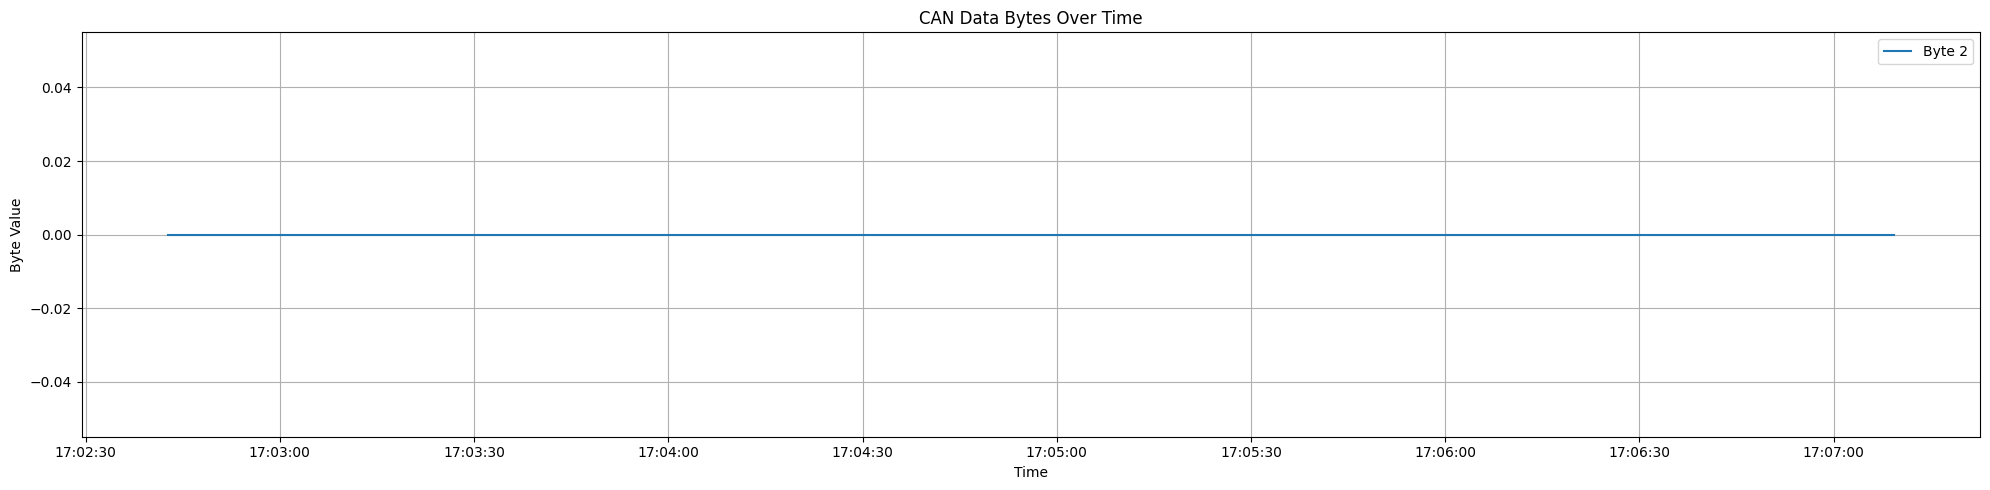

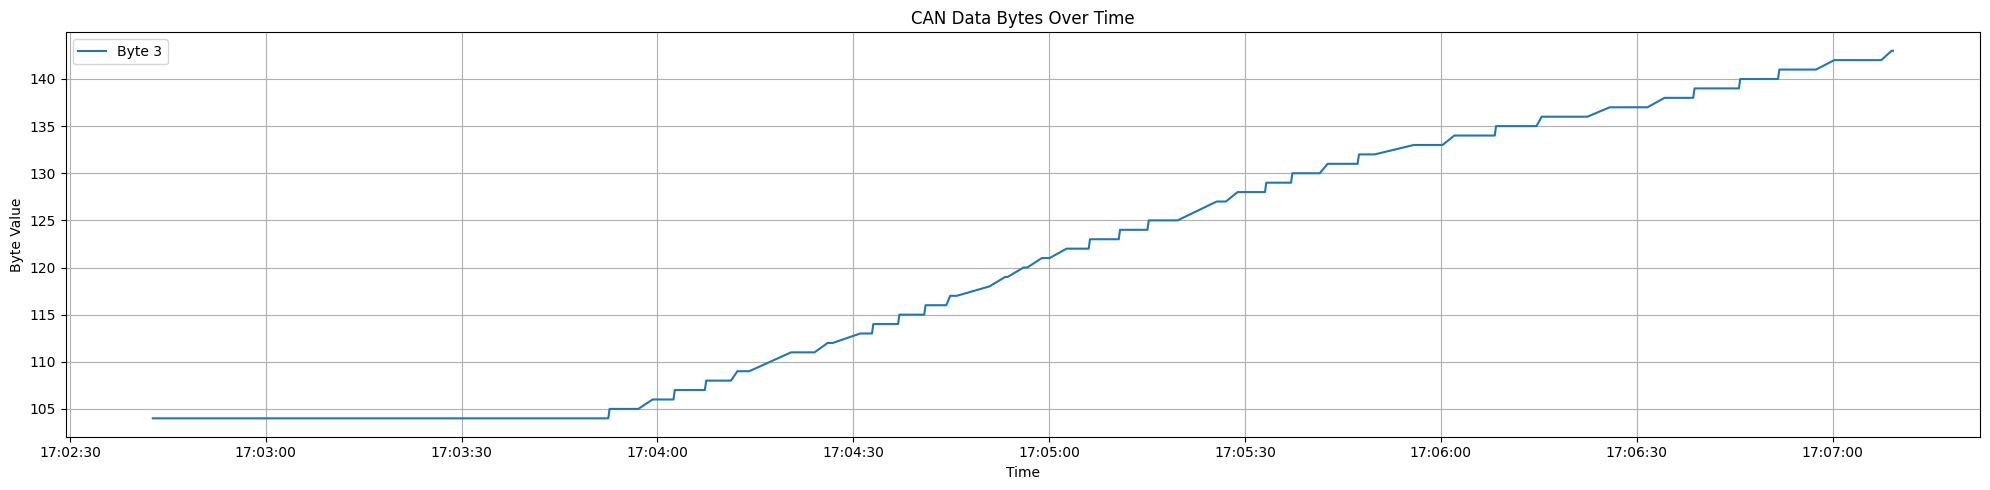

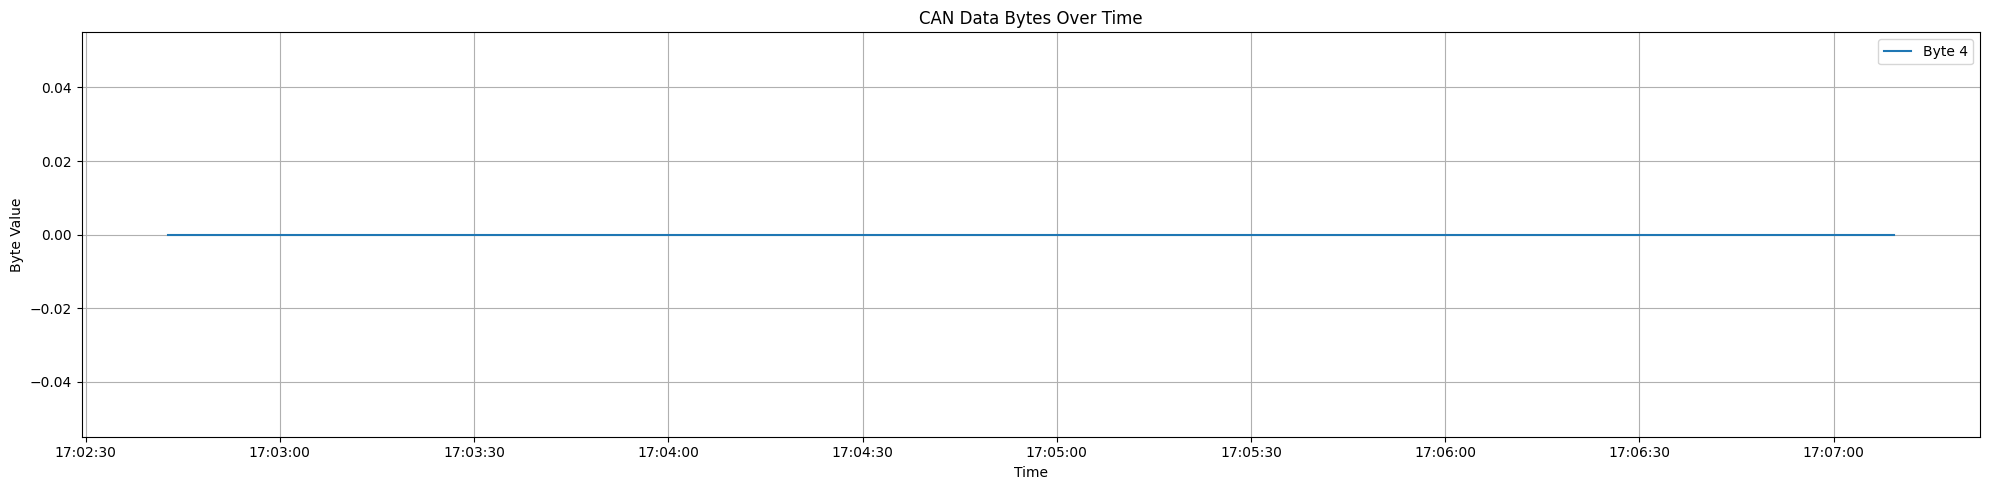

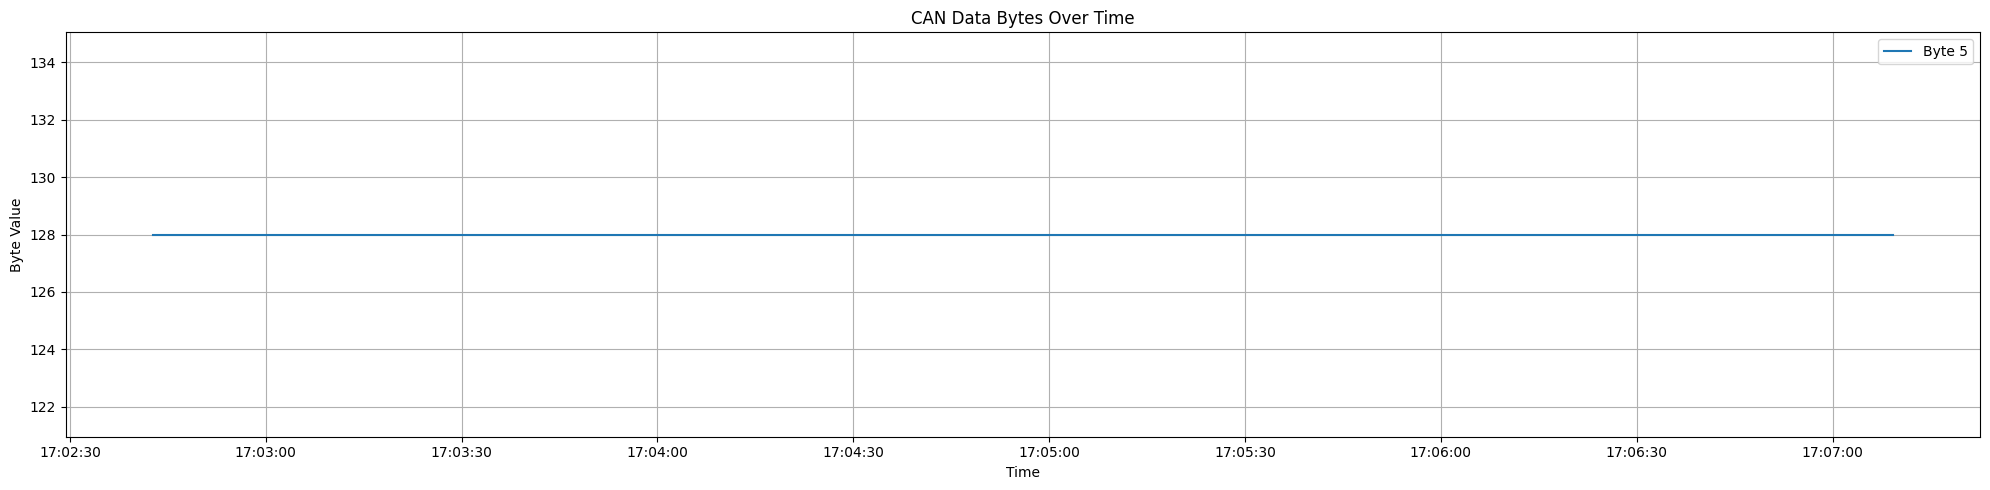

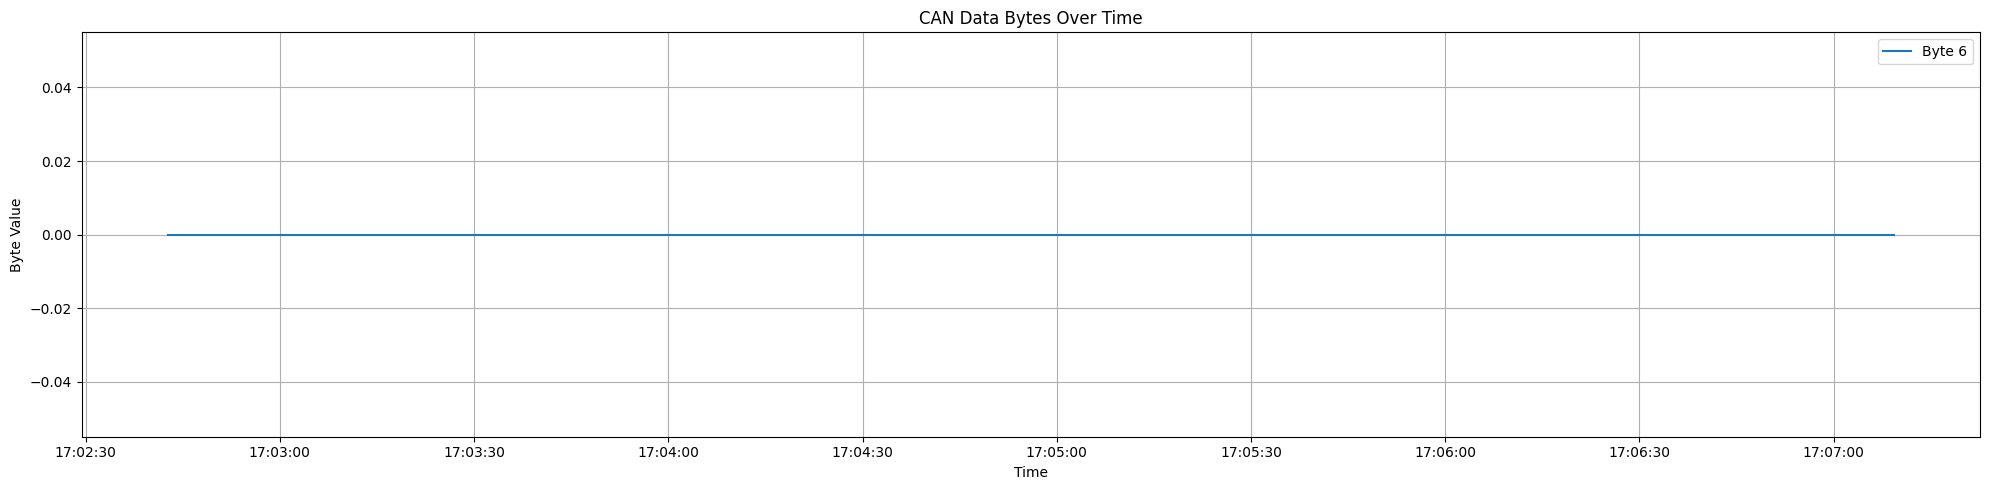

0x470
Didnt work
0x570
Didnt work
0x5D0
Didnt work
0x5D8
                    timestamp can_id           data  b0  b1  b2  b3  b4  b5  \
40    2025-06-19 17:02:42.712  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
104   2025-06-19 17:02:42.911  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
619   2025-06-19 17:02:44.557  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
870   2025-06-19 17:02:45.355  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
1025  2025-06-19 17:02:45.848  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
...                       ...    ...            ...  ..  ..  ..  ..  ..  ..   
79307 2025-06-19 17:07:05.266  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
79637 2025-06-19 17:07:06.362  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
80026 2025-06-19 17:07:07.671  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
80355 2025-06-19 17:07:08.765  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   0   
80534 2025-06-19 17:07:09.357  0x5D8  4 0 0 0 0 0 0   4   0   0   0   0   

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

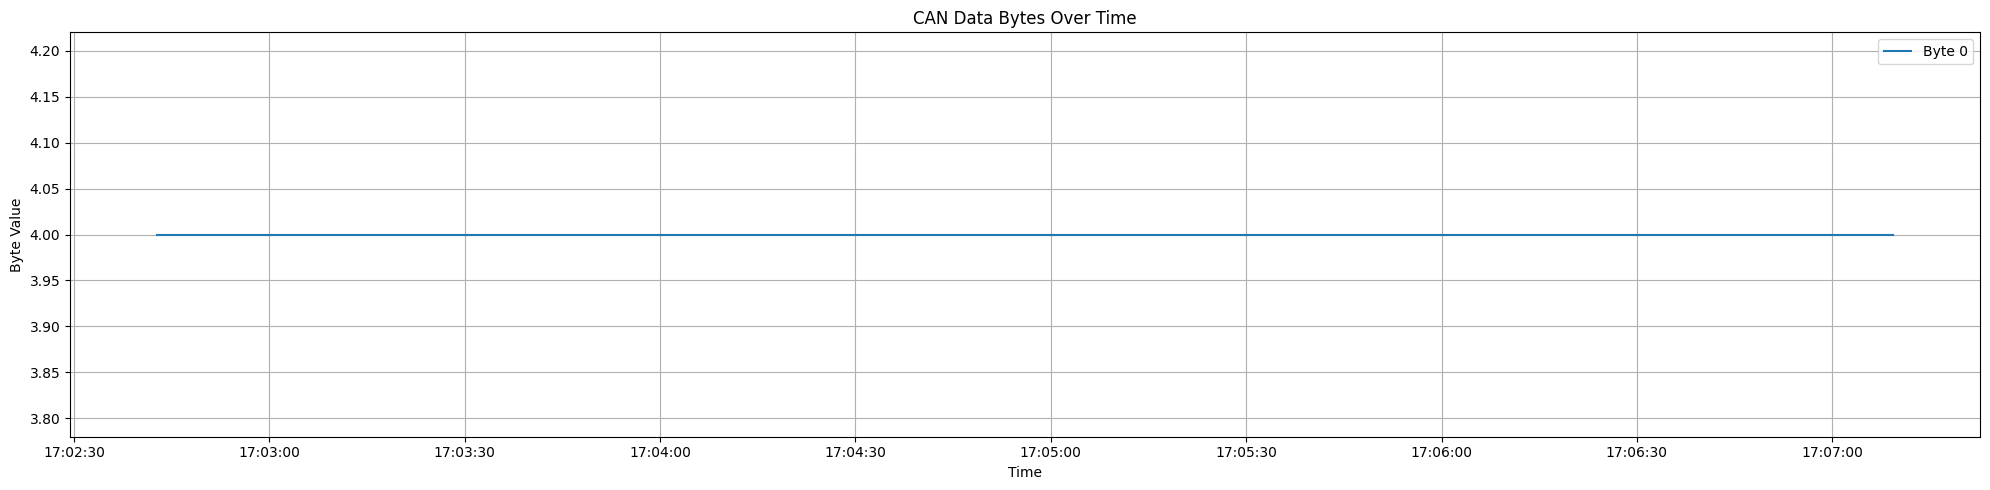

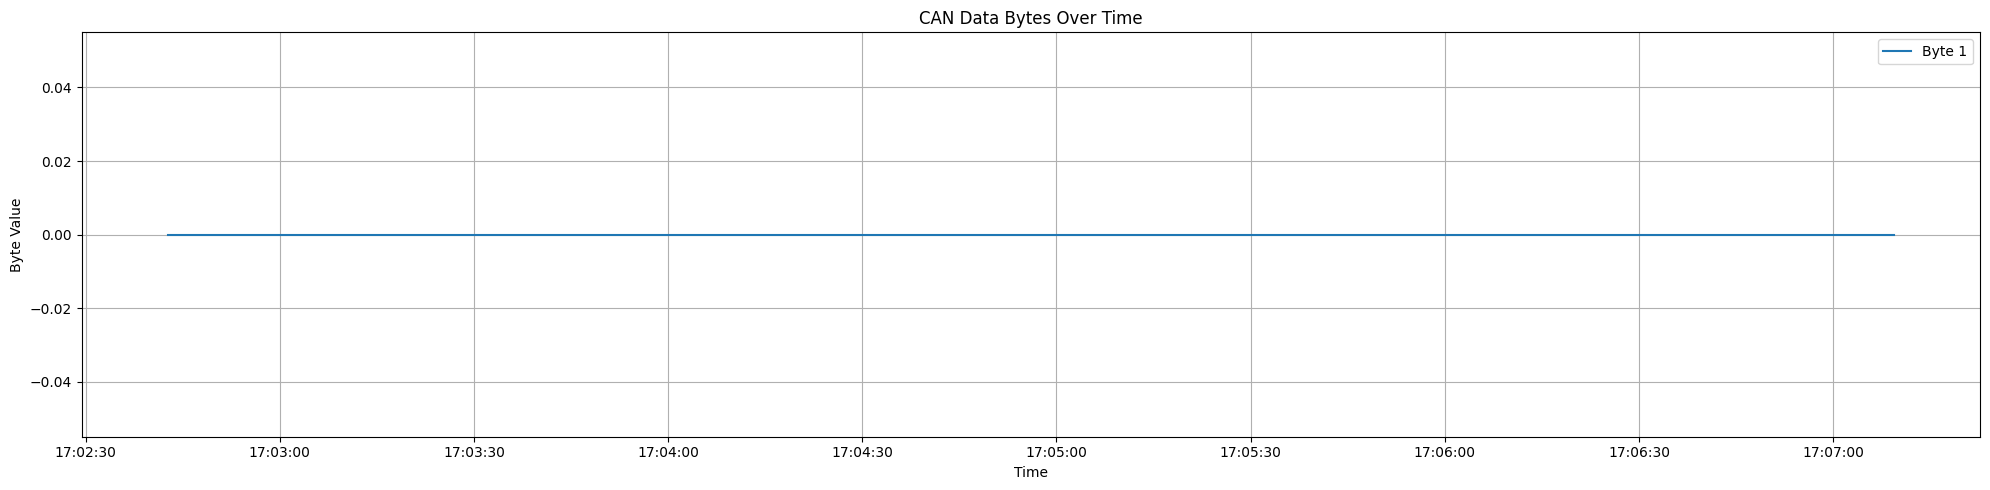

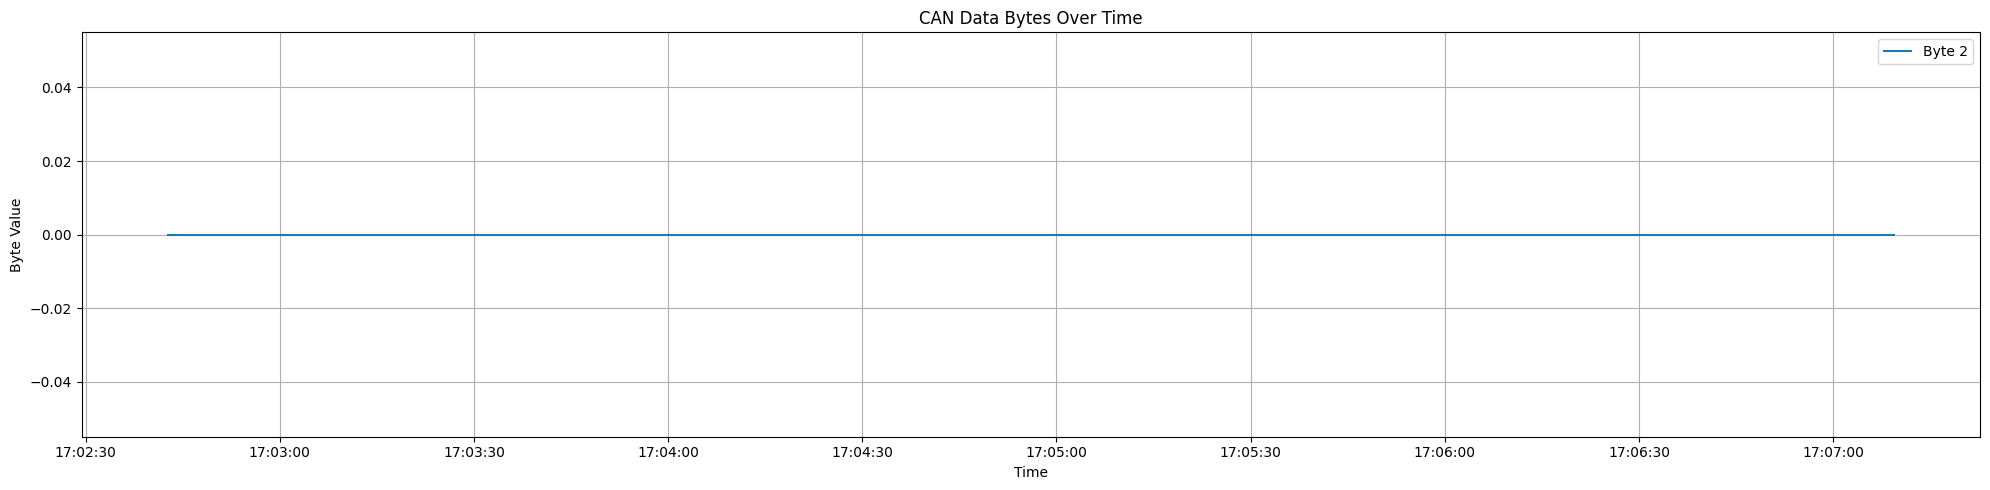

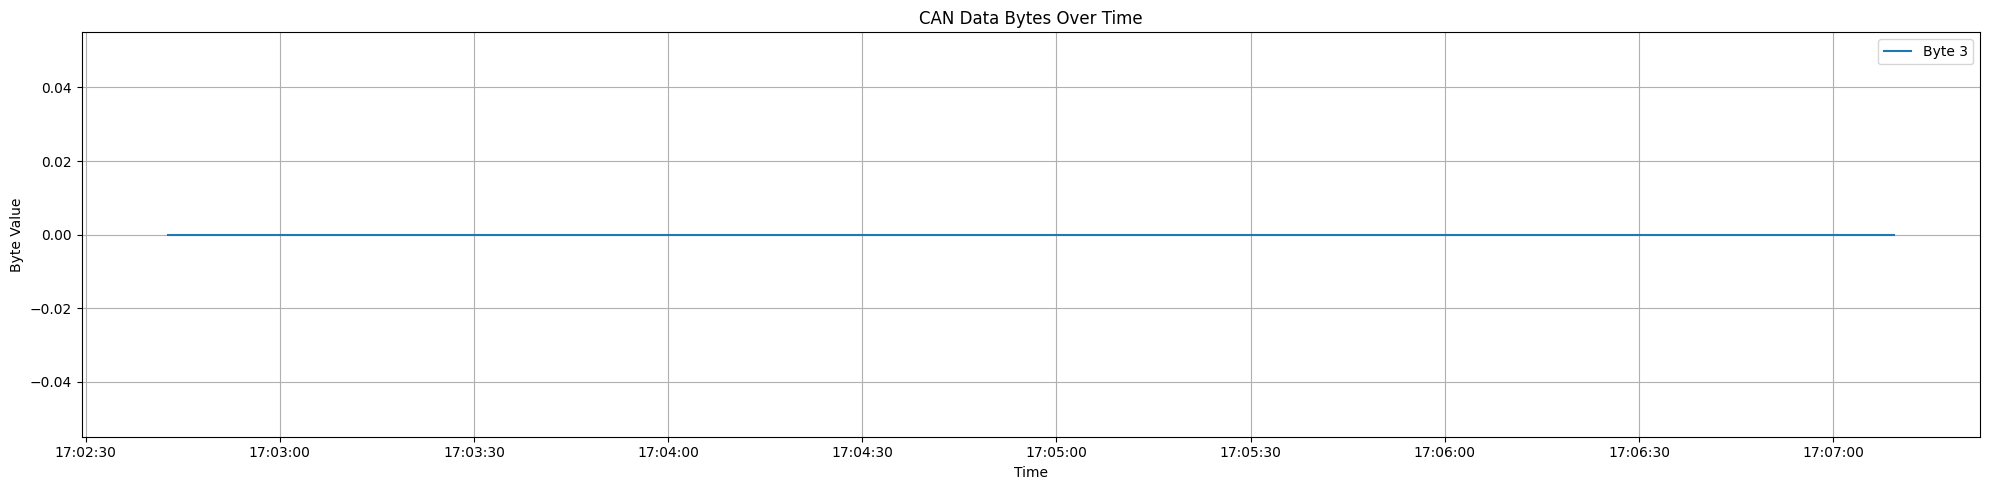

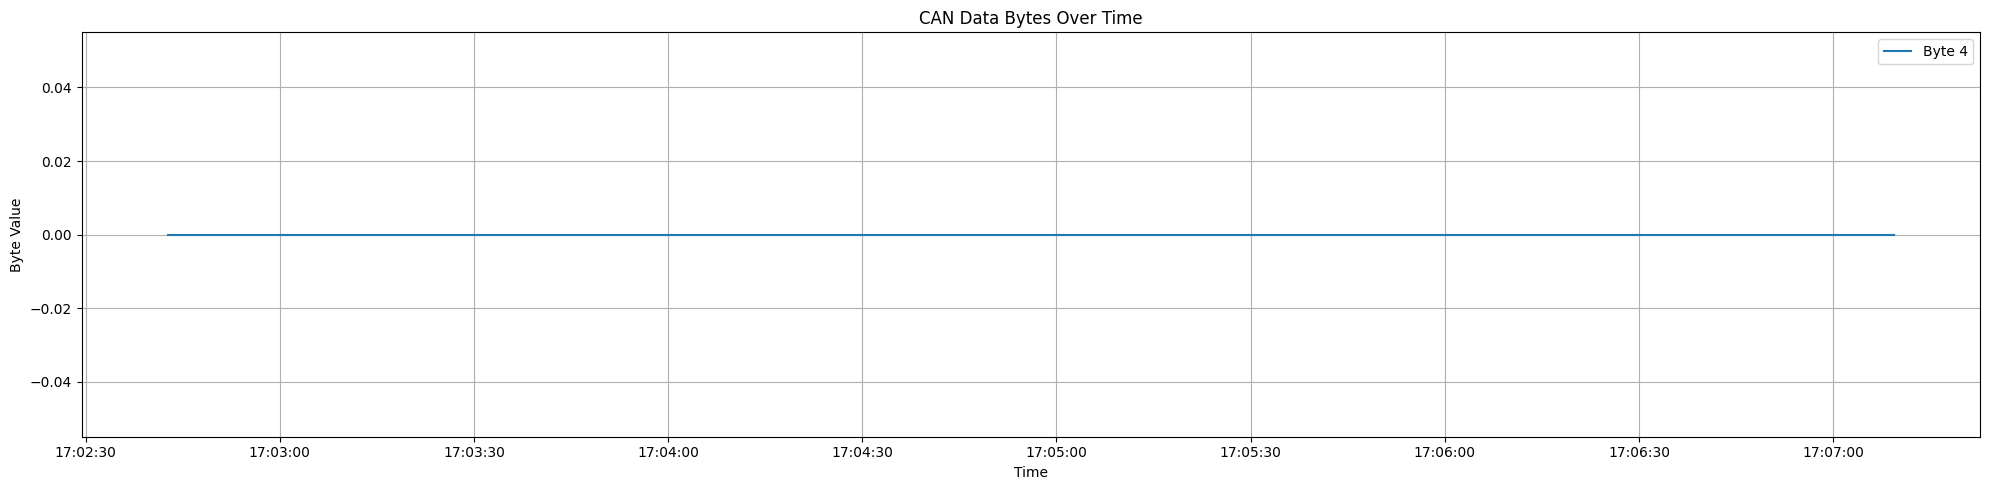

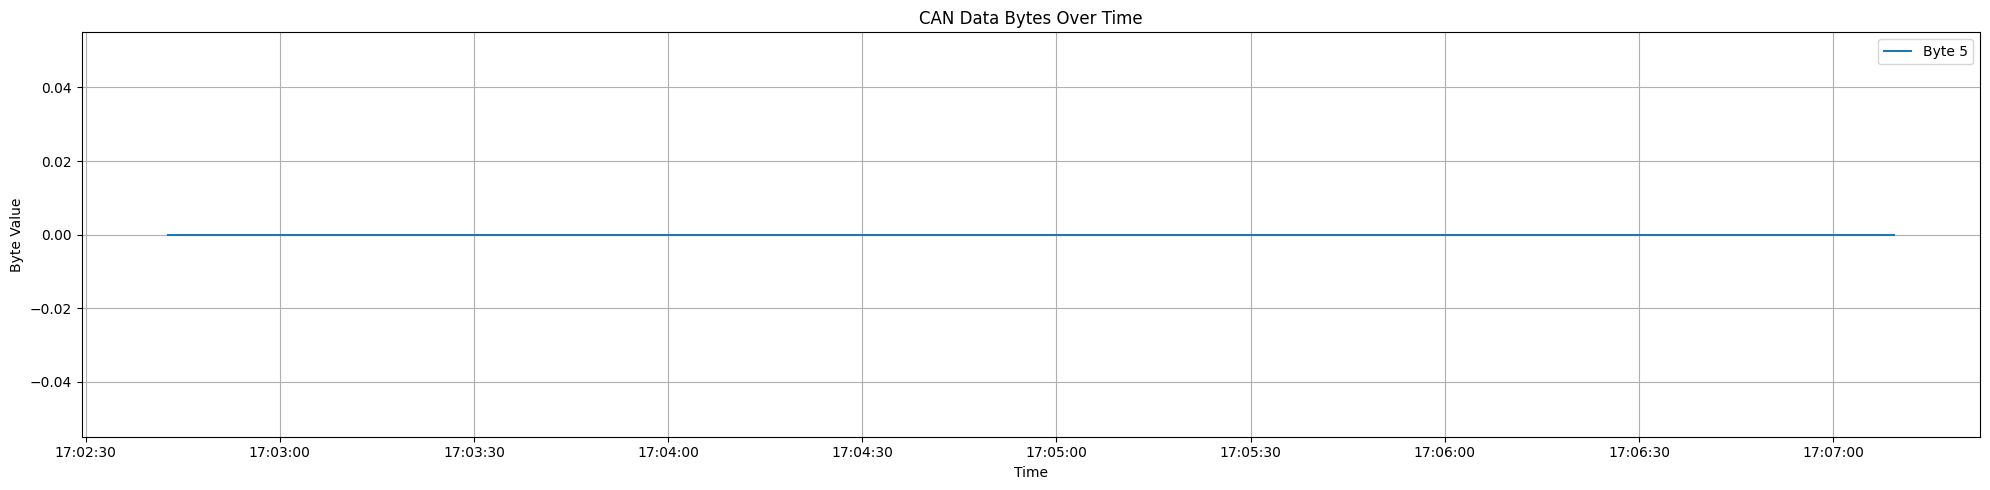

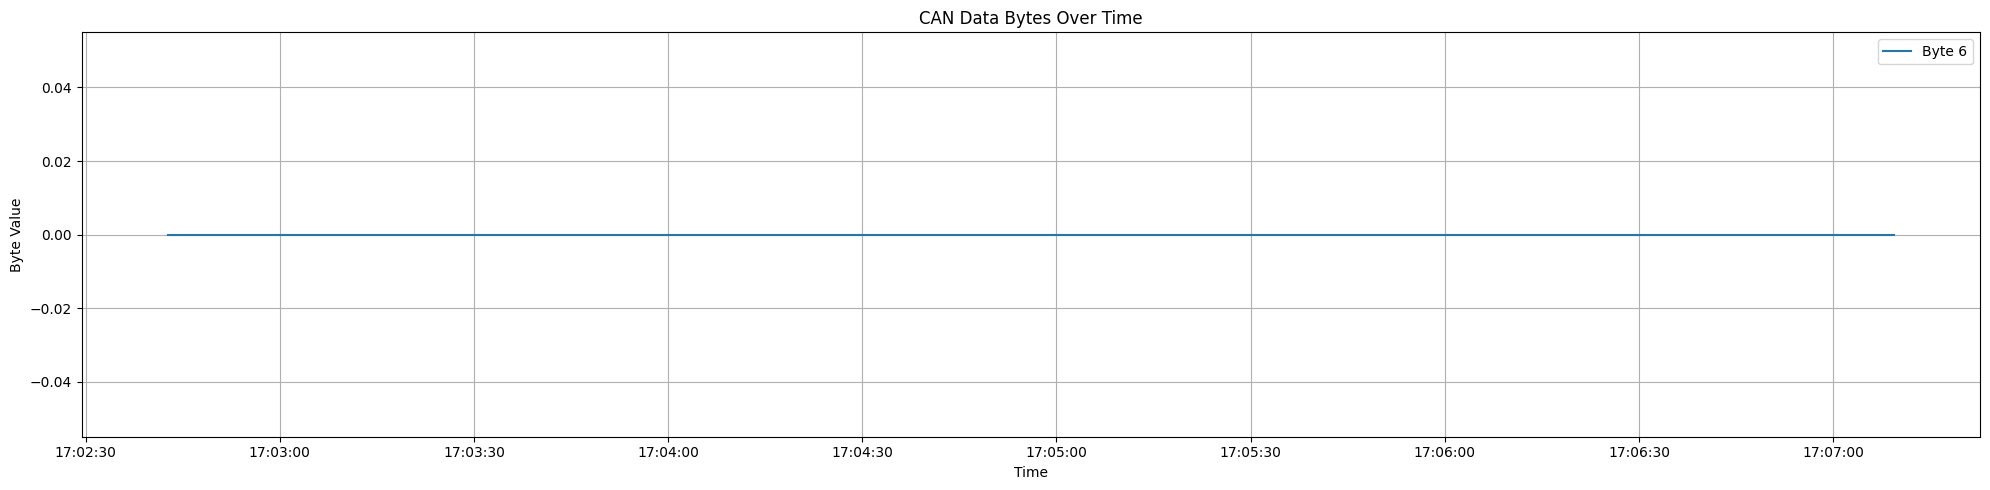

0x10
Didnt work
0x11
Didnt work
0x520
                    timestamp can_id                    data   b0  b1   b2  \
93    2025-06-19 17:02:42.879  0x520    0 1 169 71 158 162 1    0   1  169   
366   2025-06-19 17:02:43.751  0x520    0 1 169 71 158 162 1    0   1  169   
867   2025-06-19 17:02:45.348  0x520    0 1 169 71 158 162 1    0   1  169   
927   2025-06-19 17:02:45.535  0x520   66 1 169 71 158 162 1   66   1  169   
1178  2025-06-19 17:02:46.340  0x520   66 1 169 71 158 162 1   66   1  169   
...                       ...    ...                     ...  ...  ..  ...   
80290 2025-06-19 17:07:08.546  0x520    0 1 169 71 158 162 1    0   1  169   
80351 2025-06-19 17:07:08.751  0x520   66 1 169 71 158 162 1   66   1  169   
80411 2025-06-19 17:07:08.952  0x520  143 1 169 71 158 162 1  143   1  169   
80471 2025-06-19 17:07:09.154  0x520  192 1 169 71 158 162 1  192   1  169   
80529 2025-06-19 17:07:09.344  0x520    0 1 169 71 158 162 1    0   1  169   

       b3   b4   b5  b6  

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

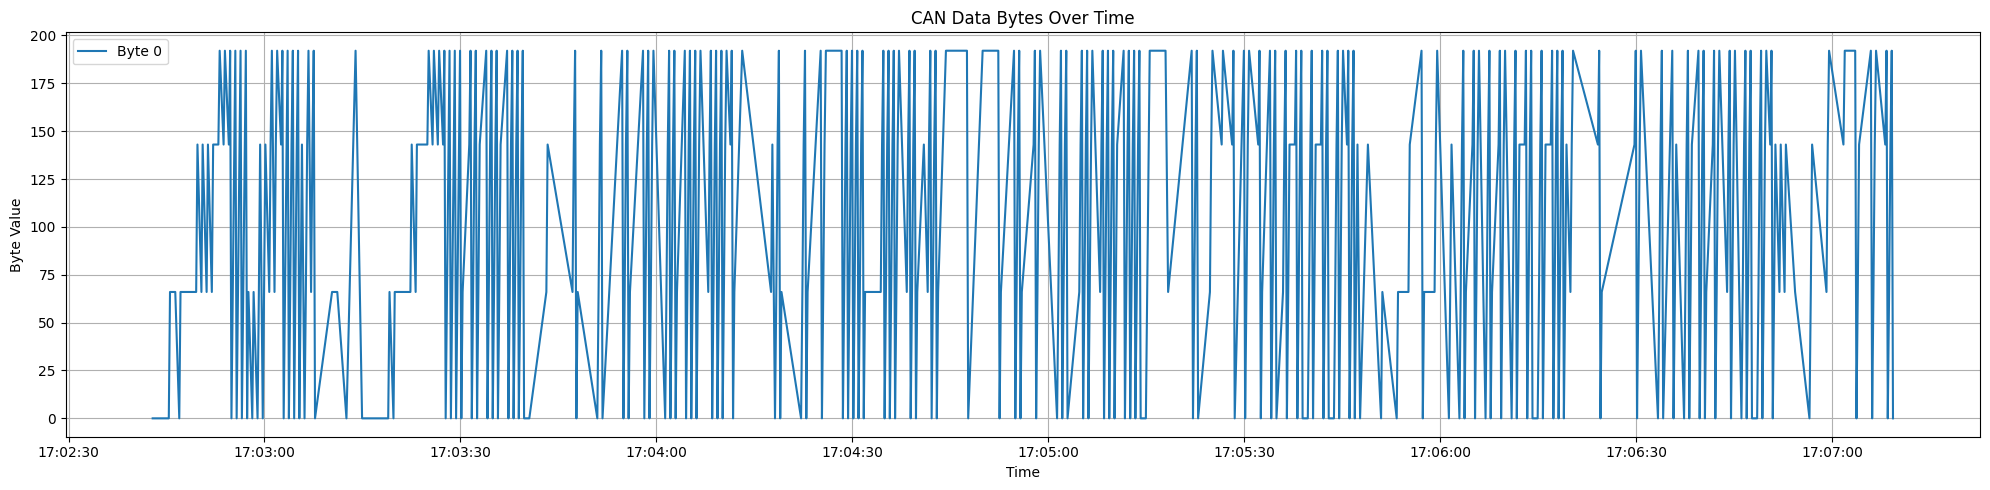

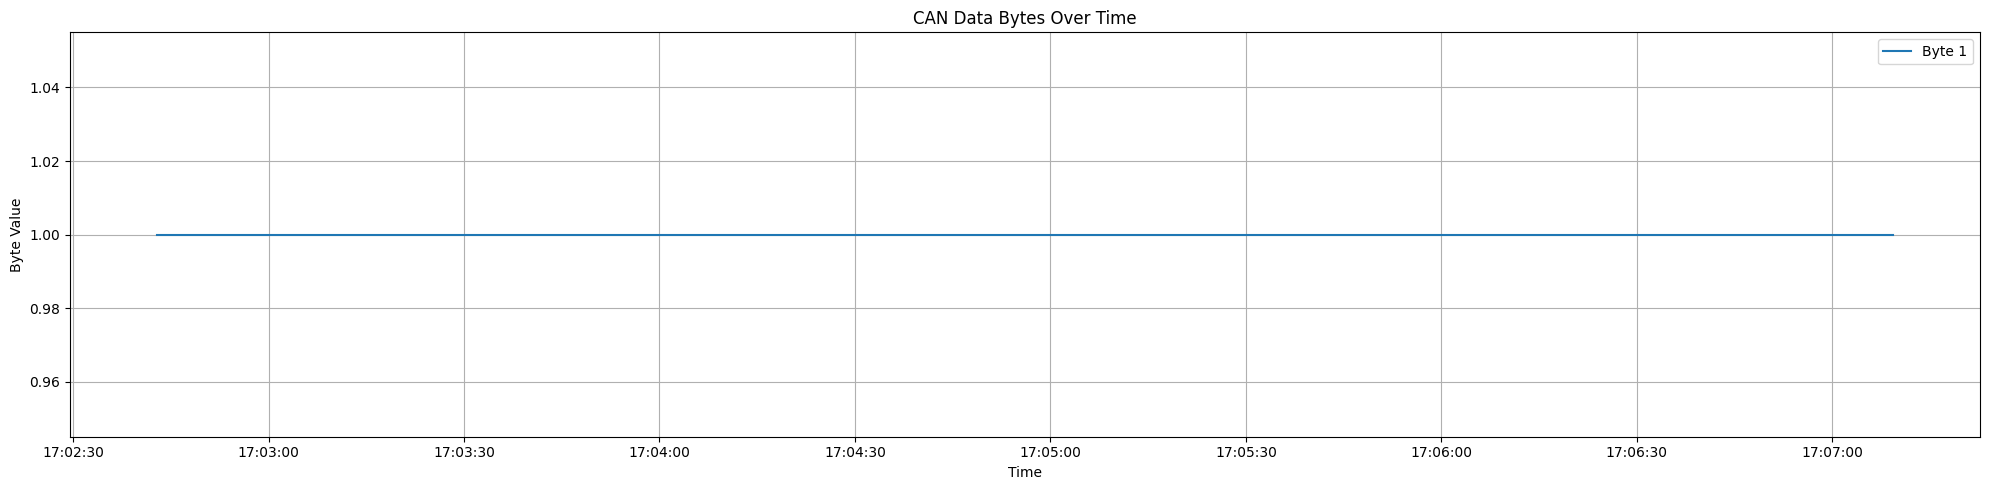

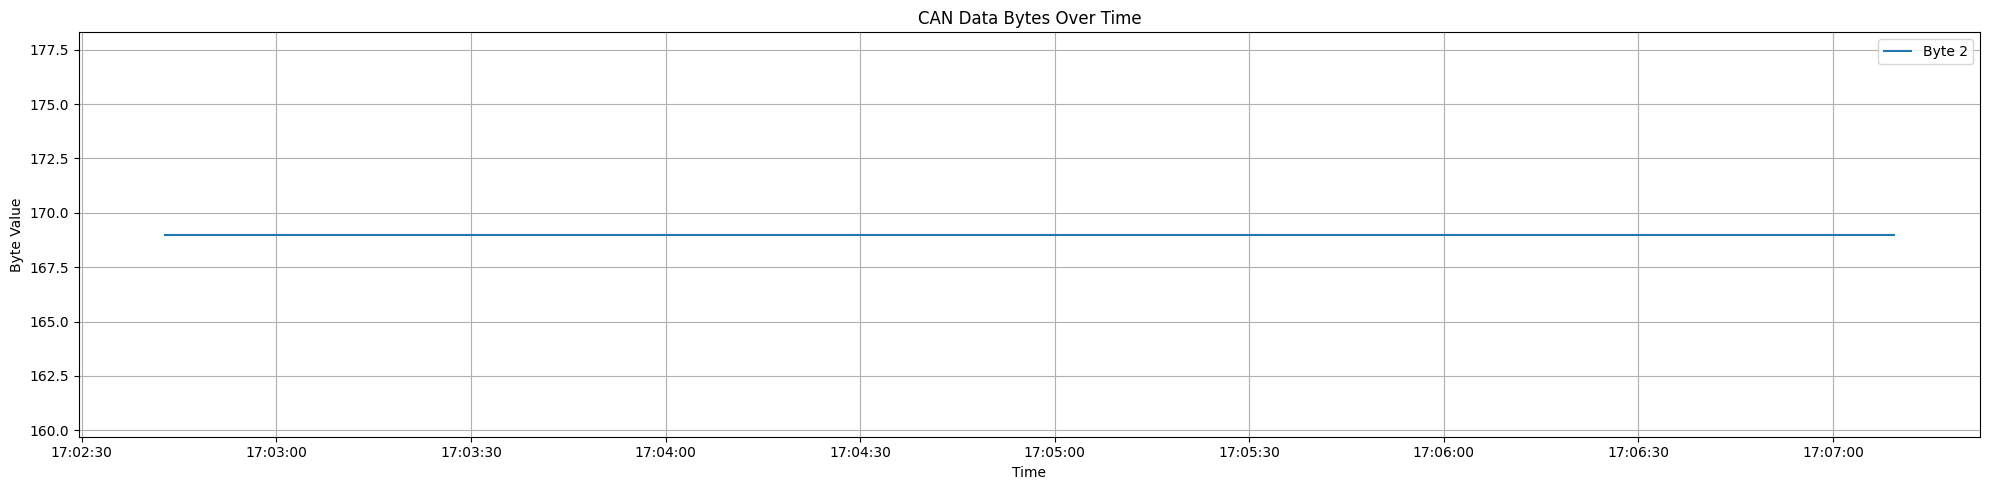

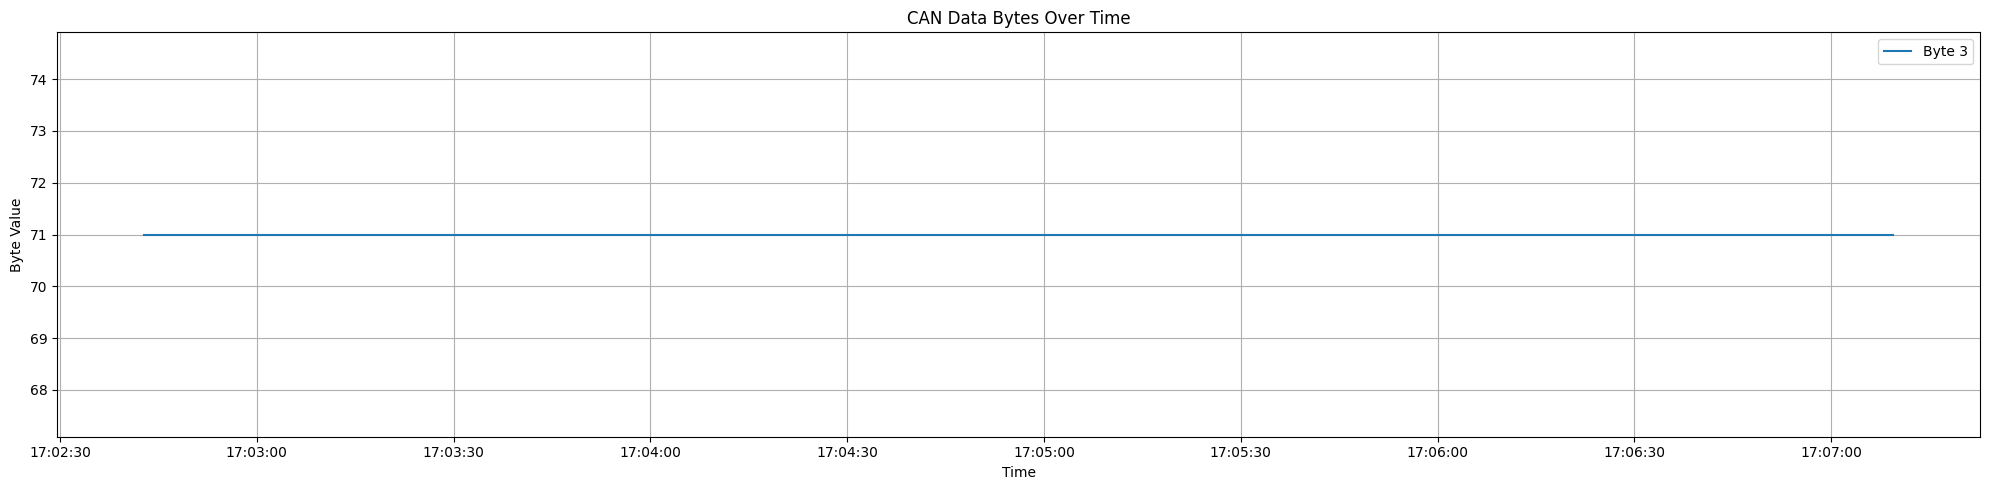

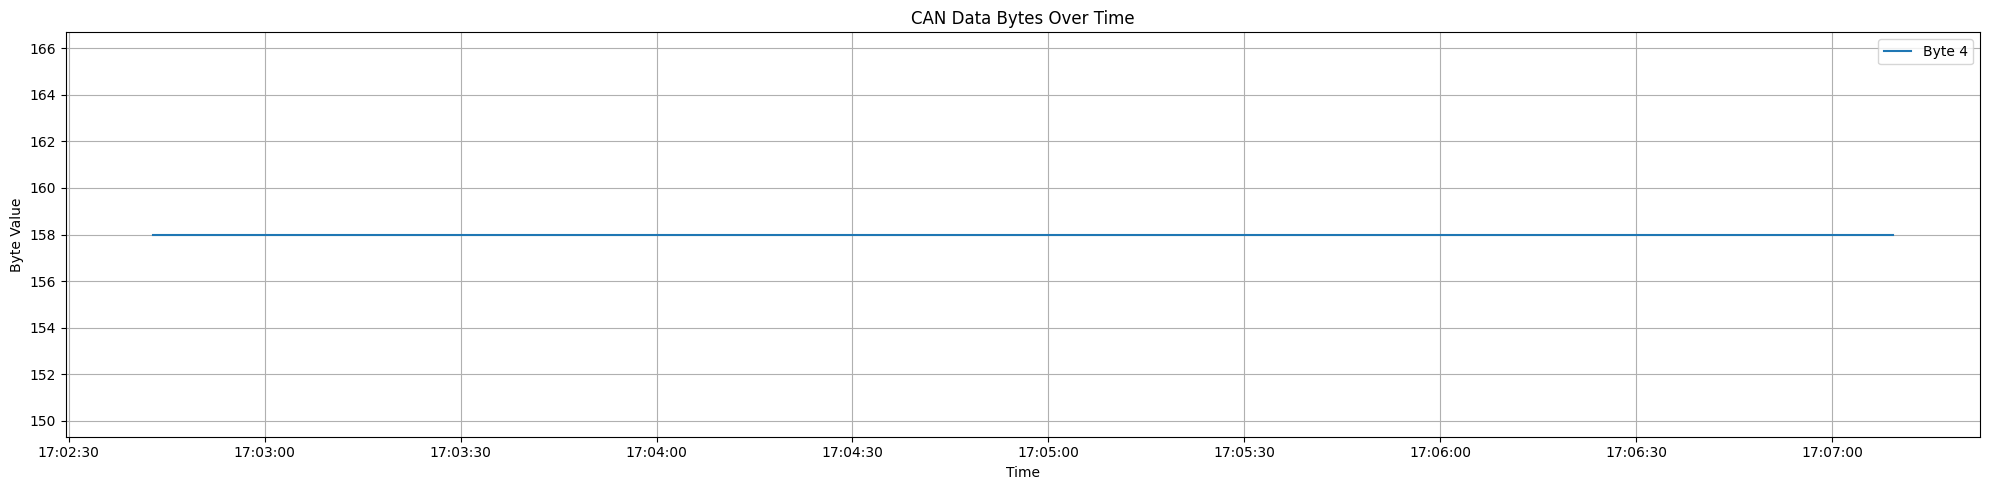

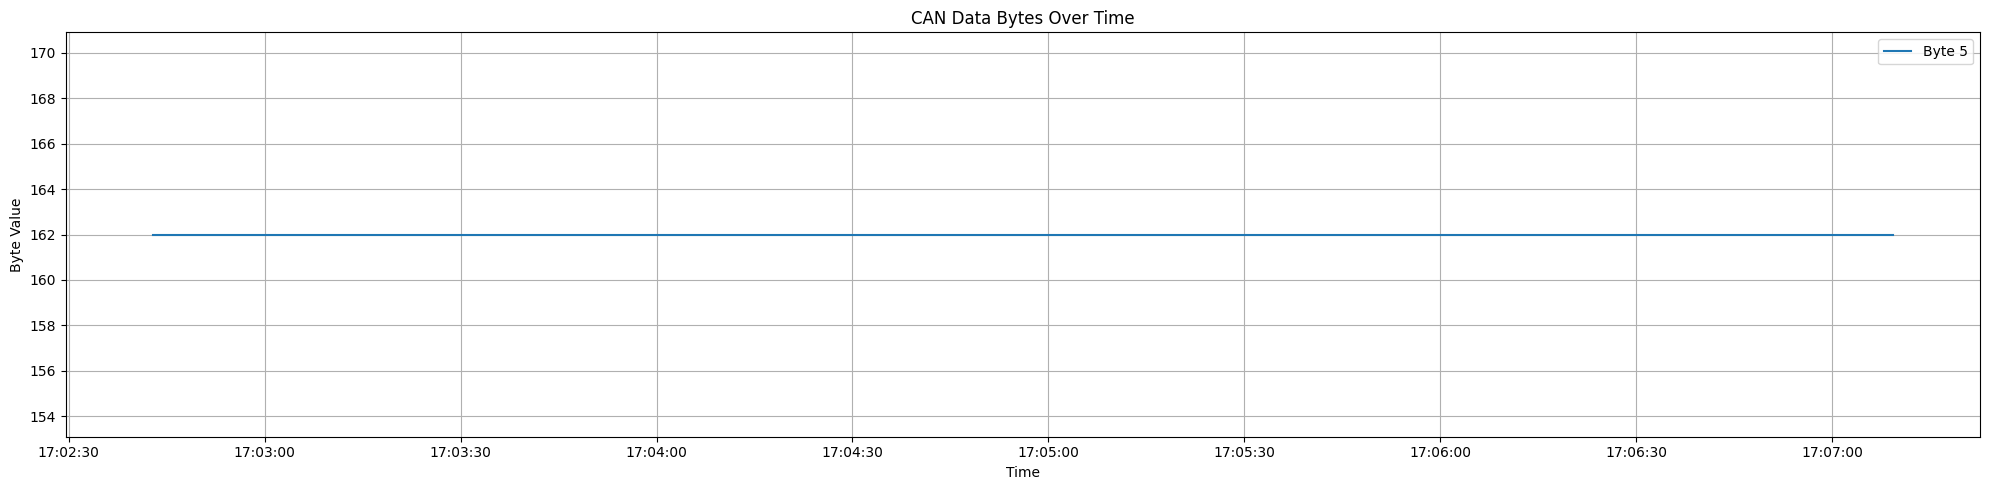

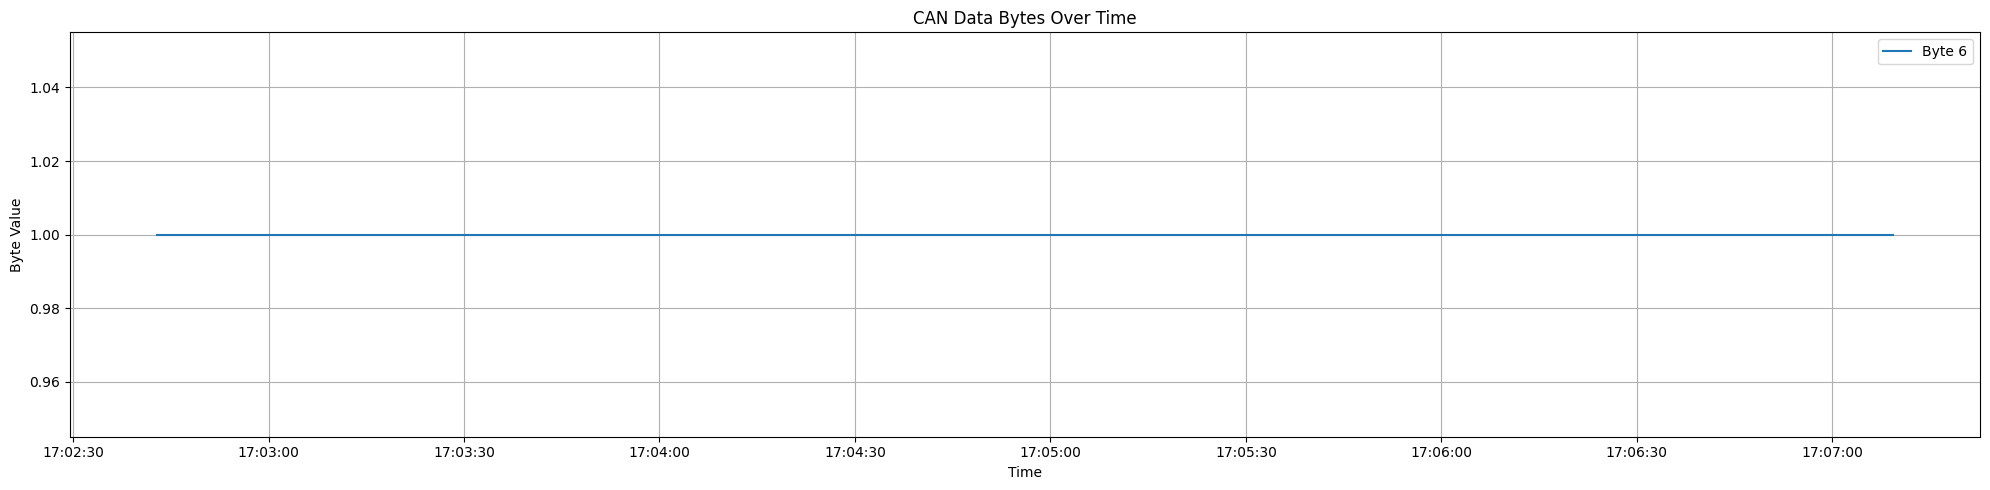

0x580
                    timestamp can_id                 data  b0  b1  b2  b3  b4  \
117   2025-06-19 17:02:42.953  0x580  0 0 25 15 74 68 144   0   0  25  15  74   
751   2025-06-19 17:02:44.980  0x580  0 0 25 15 74 68 144   0   0  25  15  74   
2321  2025-06-19 17:02:49.974  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
4217  2025-06-19 17:02:55.962  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
6450  2025-06-19 17:03:02.972  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
8975  2025-06-19 17:03:10.961  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
9288  2025-06-19 17:03:11.975  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
14296 2025-06-19 17:03:27.958  0x580  0 0 25 15 74 68 144   0   0  25  15  74   
17942 2025-06-19 17:03:39.961  0x580  0 0 25 15 74 68 144   0   0  25  15  74   
18847 2025-06-19 17:03:42.970  0x580  0 0 25 15 74 68 144   0   0  25  15  74   
24148 2025-06-19 17:04:00.967  0x580        0 0 0 0 0 0 0   0   0   0   0   0   
25043 2025-06-19 17:04

C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador["timestamp"] = pd.to_datetime(acelerador["timestamp"])
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acelerador[["b0", "b1", "b2", "b3", "b4", "b5", "b6"]] = (
C:\Users\vinic\AppData\Local\Temp\ipykernel_59736\1033235527.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

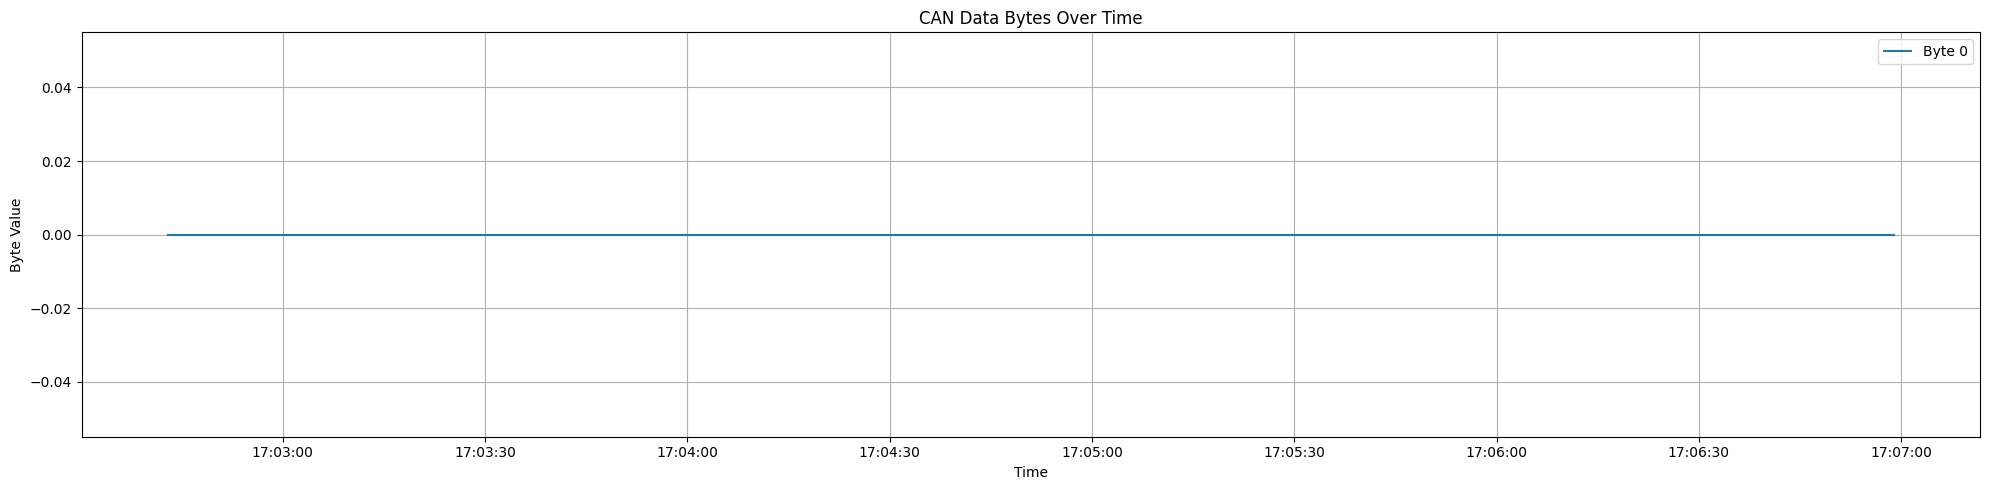

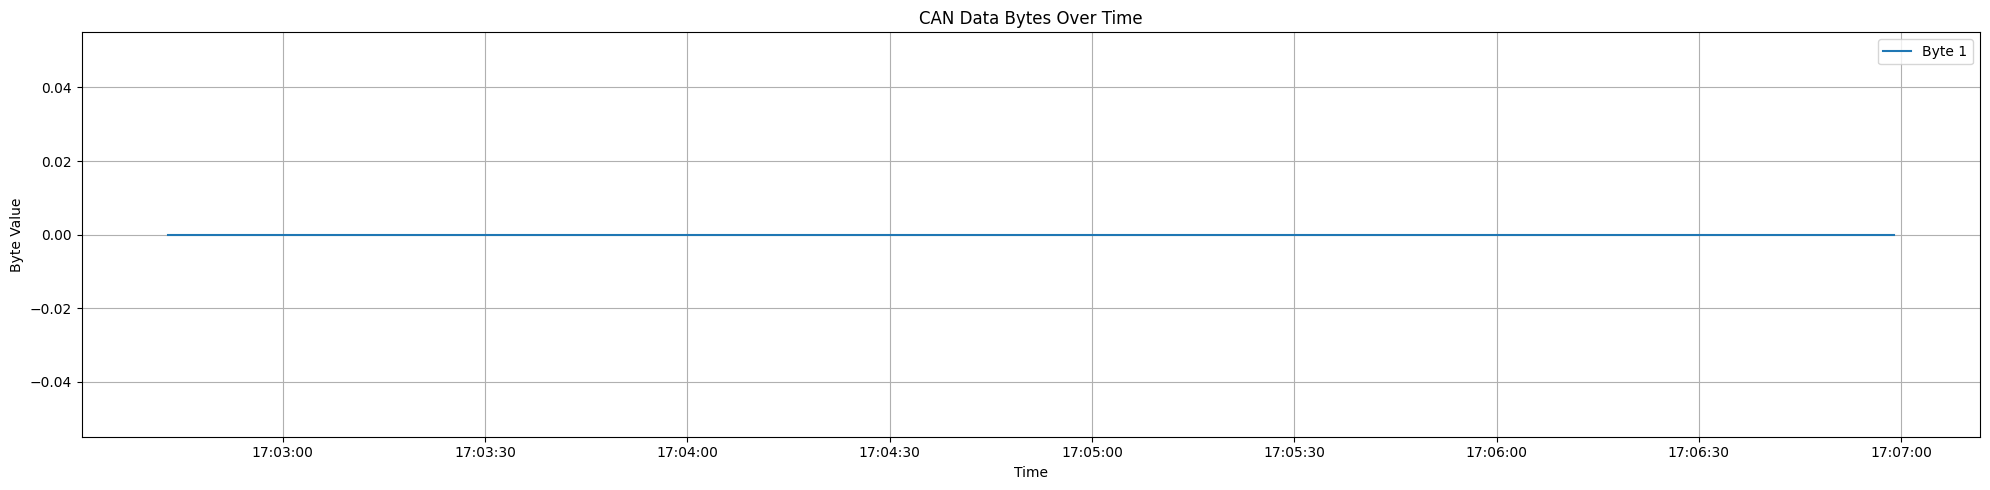

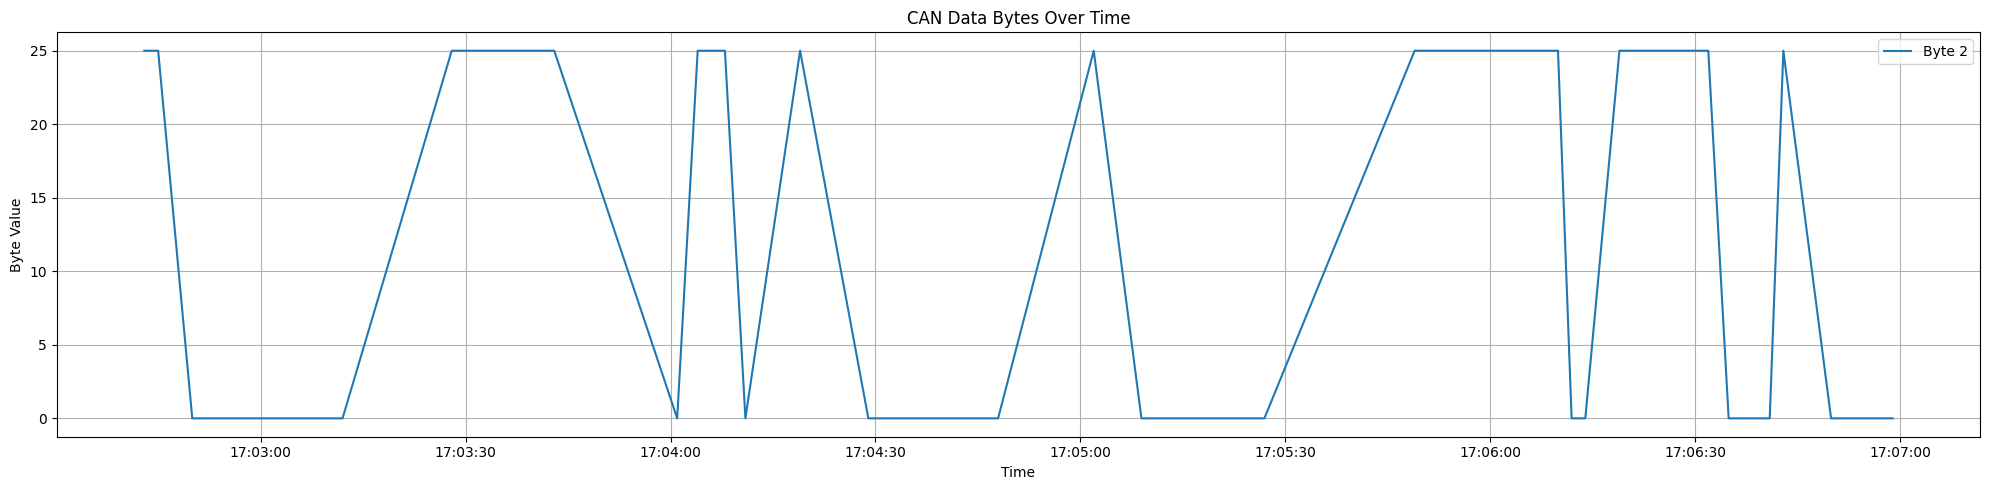

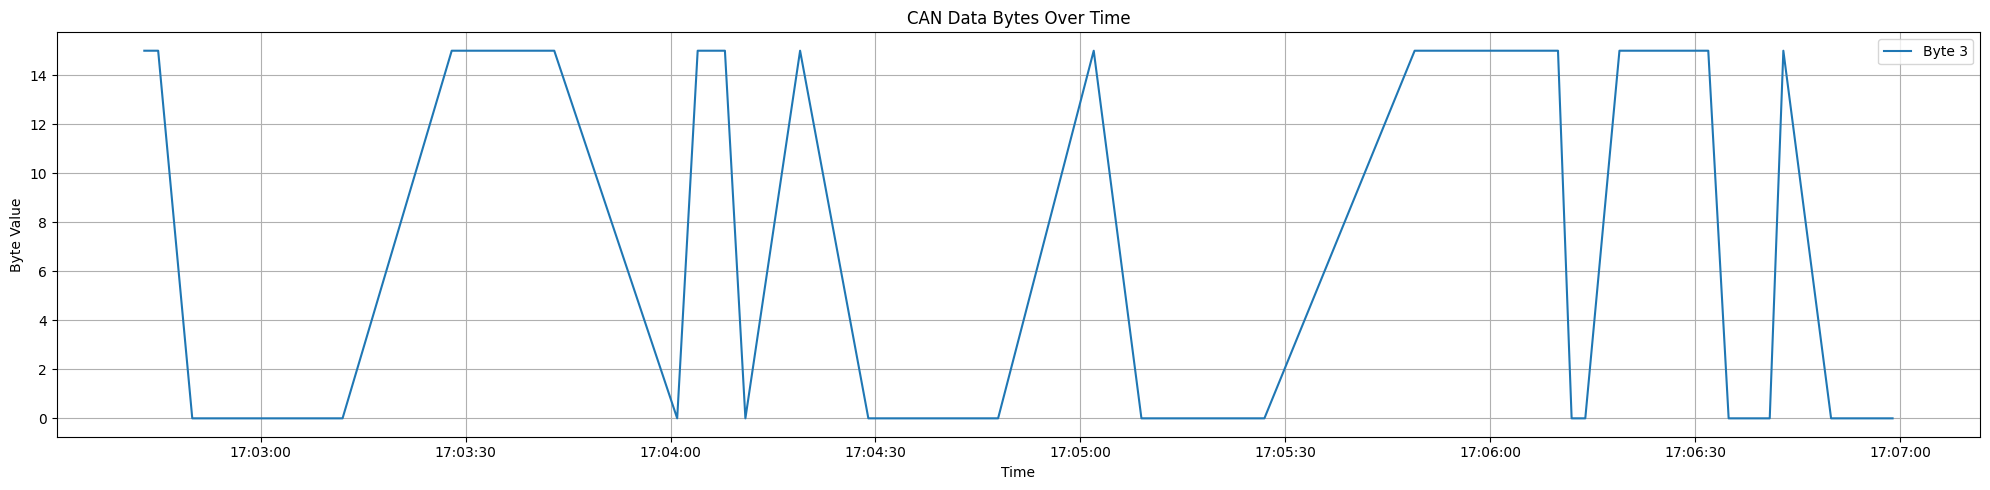

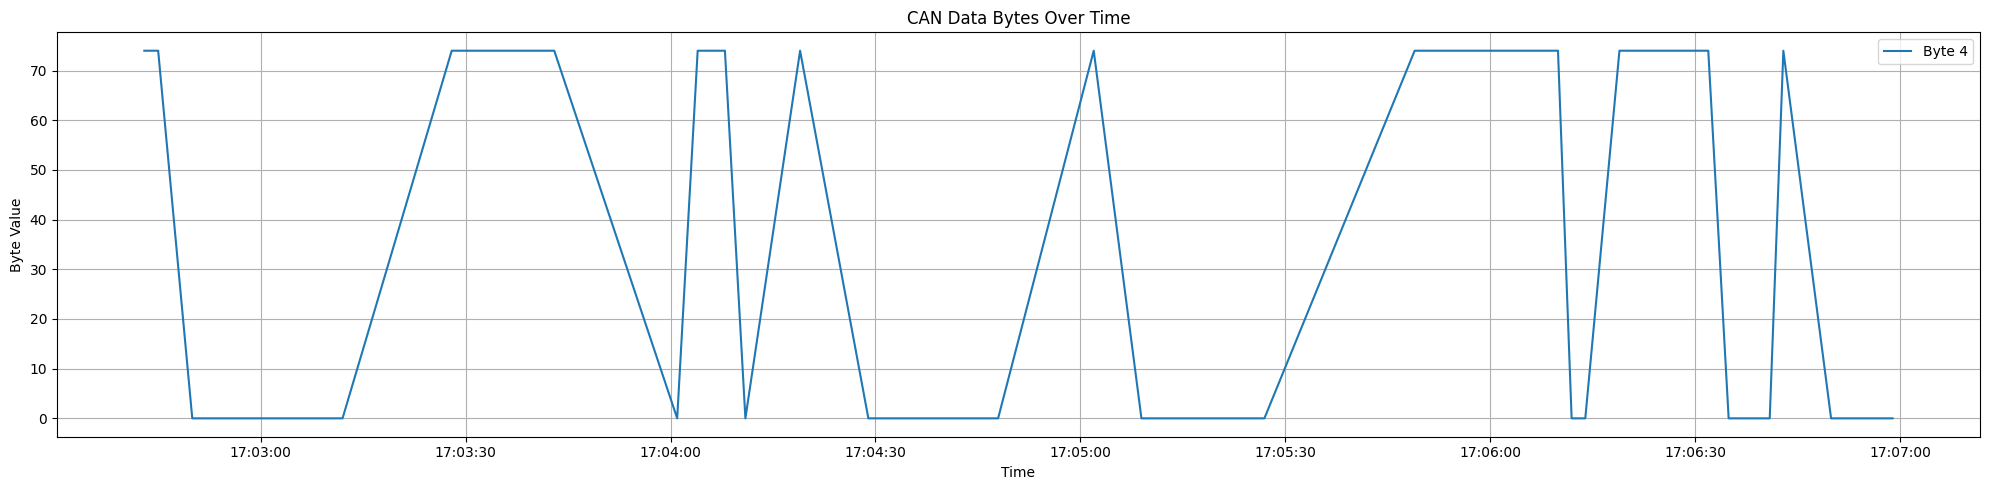

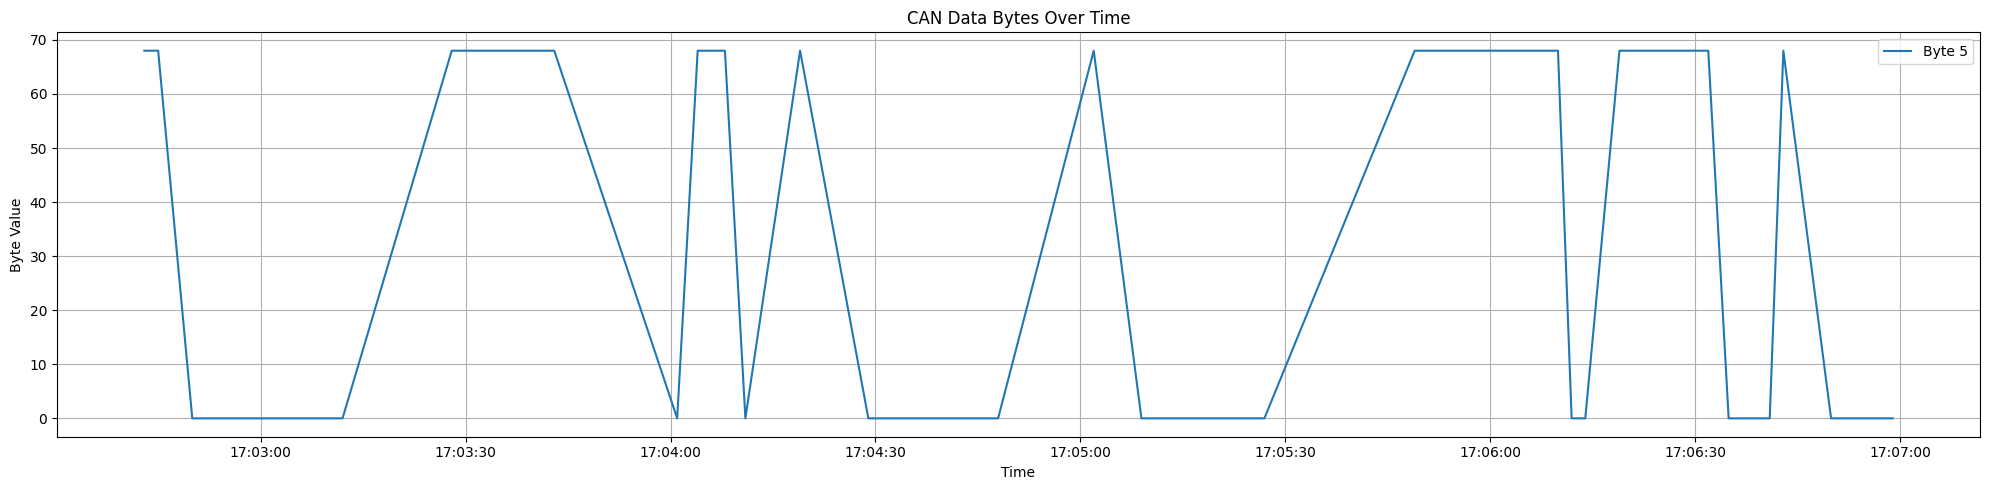

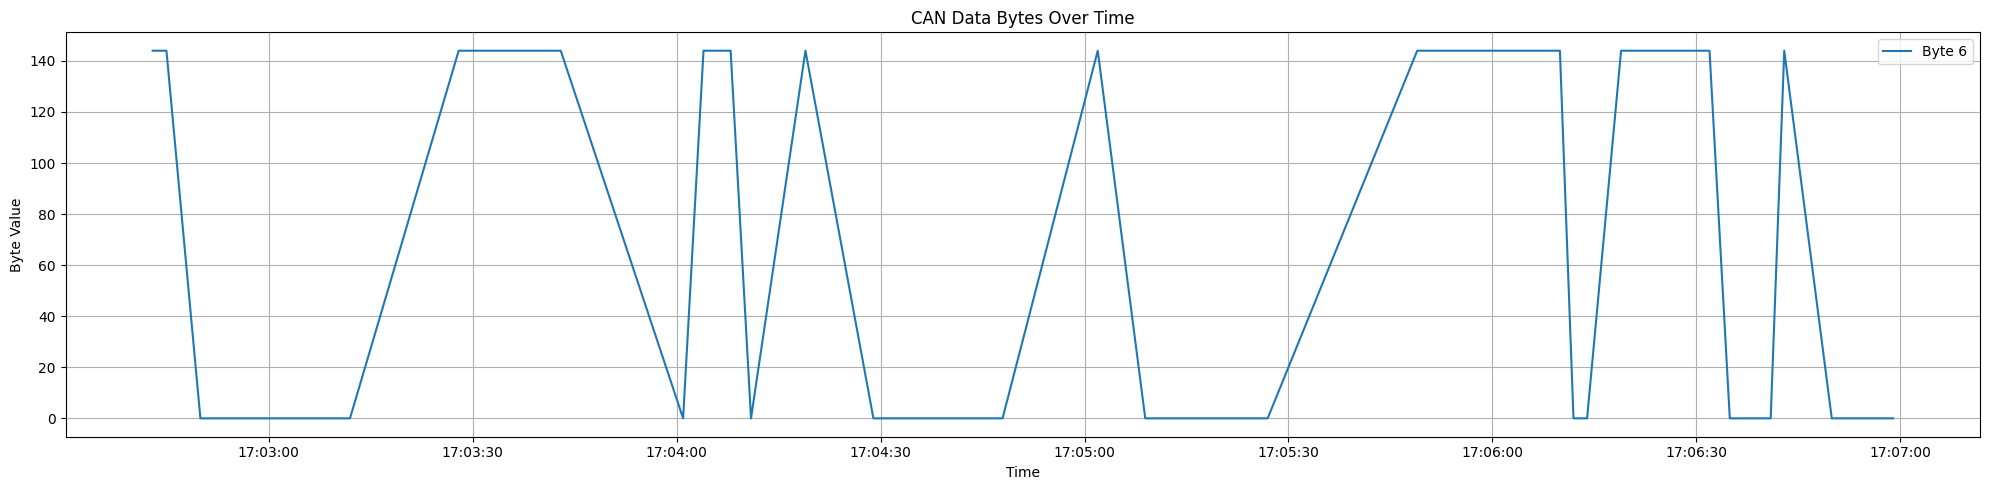

In [9]:
data = pd.read_csv(r"C:\Users\vinic\Desktop\ESPs3\can_log.csv")

for id in data['can_id'].unique():
    print(id)
    print_by_id(id, data)

In [ ]:
import serial
import matplotlib.pyplot as plt
import json
from datetime import datetime
from collections import deque

# CONFIG
SERIAL_PORT = "COM7"       # Change to your serial port
BAUD_RATE = 115200
TARGET_ID = "0x488"
BUFFER_SIZE = 100  # How many points to keep in the live window

# Initialize buffers
timestamps = deque(maxlen=BUFFER_SIZE)
byte_values = {f"b{i}": deque(maxlen=BUFFER_SIZE) for i in range(7)}

# Set up real-time plot
plt.ion()
fig, axs = plt.subplots(7, 1, figsize=(20, 14), sharex=True)
fig.subplots_adjust(hspace=0.5)
lines = []

for i in range(7):
    axs[i].set_ylabel(f"Byte {i}")
    axs[i].set_ylim(0, 255)
    axs[i].grid(True)
    line, = axs[i].plot([], [], label=f"Byte {i}")
    axs[i].legend(loc="upper right")
    lines.append(line)

axs[-1].set_xlabel("Samples")

# Connect to serial
ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud")

try:
    while True:
        try:
            line_raw = ser.readline().decode("utf-8").strip()
            # print(line_raw)
            if not line_raw:
                continue

            # Pre-clean the string and parse
            line_raw = line_raw.replace("'", '"')
            data = json.loads(line_raw)

            if data.get("id") == TARGET_ID:
                data_bytes = data.get("data", [])
                if len(data_bytes) < 7:
                    continue

                timestamps.append(datetime.now().strftime("%H:%M:%S"))

                for i in range(7):
                    byte_values[f"b{i}"].append(int(data_bytes[i]))

                # Update plots
                for i in range(7):
                    lines[i].set_xdata(range(len(byte_values[f"b{i}"])))
                    lines[i].set_ydata(byte_values[f"b{i}"])
                    axs[i].set_xlim(0, len(byte_values[f"b{i}"]))
                    axs[i].relim()
                    axs[i].autoscale_view()

                fig.canvas.draw()
                fig.canvas.flush_events()

        except json.JSONDecodeError:
            pass
        except Exception as e:
            print("Error:", e)

except KeyboardInterrupt:
    print("\nStopped by user")


In [ ]:
import serial
import matplotlib.pyplot as plt
import json
from datetime import datetime
from collections import deque

# CONFIG
SERIAL_PORT = "COM7"       # Change to your serial port
BAUD_RATE = 115200
TARGET_ID = "0x488"
BUFFER_SIZE = 100 # How many points to keep in the live window

# Initialize buffers
timestamps = deque(maxlen=BUFFER_SIZE)
byte_values = {f"b{i}": deque(maxlen=BUFFER_SIZE) for i in range(7)}

# Set up real-time plot
plt.ion()
fig, axs = plt.subplots(7, 1, figsize=(20, 14), sharex=True)
fig.subplots_adjust(hspace=0.5)
lines = []

for i in range(7):
    axs[i].set_ylabel(f"Byte {i}")
    axs[i].set_ylim(0, 255)
    axs[i].grid(True)
    line, = axs[i].plot([], [], label=f"Byte {i}")
    axs[i].legend(loc="upper right")
    lines.append(line)

axs[-1].set_xlabel("Samples")

# Connect to serial
ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud")

try:
    while True:
        try:
            line_raw = ser.readline().decode("utf-8").strip()
            # print(line_raw)
            # if not line_raw:
            #     continue

            # # Pre-clean the string and parse
            # # line_raw = line_raw.replace("'", '"')
            # data = json.loads(line_raw)
            data = line_raw
            # print(data)
            try:
                v0, v1, v2, v3, v4, v5, v6, v7, v8 = data.split(" ")
            except:
                continue
            v1 = v1[4:]
            print(v1)
            values = [v2, v3, v4, v5, v6, v7, v8]
            if TARGET_ID in v0:
                timestamps.append(datetime.now().strftime("%H:%M:%S"))

                if len(values) < 8:
                    continue  # skip invalid data
                for i in range(7):
                    byte_values[f"b{i}"].append(int(values[i]))

                # Update plots
                for i in range(7):
                    lines[i].set_xdata(list(range(len(byte_values[f"b{i}"]))))
                    lines[i].set_ydata([int(v) for v in byte_values[f"b{i}"]])
                    axs[i].set_xlim(0, len(byte_values[f"b{i}"]))
                    axs[i].relim()
                    axs[i].autoscale_view()
                    print("Troleiii")
                plt.pause(1)
                fig.canvas.draw()
                fig.canvas.flush_events()

        except json.JSONDecodeError:
            pass
        except Exception as e:
            print("Error:", e)

except KeyboardInterrupt:
    print("\nStopped by user")
